# SETTINGS


#### Logger setting

In [2]:
import logging
from pathlib import Path
from typing import Optional, Union

def set_logger(
    level: int = logging.INFO,
    log_file: Optional[Union[str, Path]] = None
) -> logging.Logger:
    '''
    a function to set the logger and logging for each file/script, it has to be called at the start of each script if used:
    the LEVEL OF PRIORITY: DEBUG < INFO < WARNING < ERROR < CRITICAL. As stated logging.DEBUG prints also logging.INFO, 
    but logging.WARNING doesn't print logging.DEBUG

    Args:
        level (int, optional): Define the level of verbosity. Defaults to logging.INFO.
        log_file (str | None, optional): The log file where most/all of the log will be saved. Defaults to None.

    Returns:
        logging.Logger: to be used as log_for_this_file = set_logger(..) and then log_for_this_file.DEBUG('message')
    '''
    
    # reset (importante nei notebook)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    logger = logging.getLogger(__name__)
    logger.setLevel(level)

    formatter = logging.Formatter(
        '[%(levelname)s] %(name)s - %(message)s'
    )

    # console
    ch = logging.StreamHandler()
    ch.setLevel(level)
    ch.setFormatter(formatter)
    logger.addHandler(ch)

    # file opzionale
    if log_file is not None:
        fh = logging.FileHandler(log_file)
        fh.setLevel(logging.DEBUG)
        fh.setFormatter(formatter)
        logger.addHandler(fh)

    return logger
logs = set_logger(level=logging.DEBUG)

In [3]:
def get_root_path(
    start_path: Path | None = None,
    project_name: str = "ImRegODE"
) -> Path:
    '''
    Help to get the project directory, if used inside a ipynb use Path.cwd(), None otherwise is good

    Args:
        start_path (Path | None, optional): The starting path for the search. Defaults to None.
        project_name (str, optional): the name of project directory. Defaults to "ImRegODE".

    Raises:
        FileNotFoundError: There no parent directory named as project_name, maybe it's not the right project or the project is not in the parent directories

    Returns:
        Path: The path to the project directory.
    '''

    if start_path is None:
        start_path = Path(__file__).resolve()

    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):

        if path.stem == project_name:
            return path

    raise FileNotFoundError(
        f"Project root '{project_name}' not found."
    )
PROJECT_PATH = get_root_path(start_path=Path.cwd())
PROJECT_PATH

WindowsPath('C:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE')

In [7]:
# Config_file for constant
from pathlib import Path
import numpy as np
import yaml
from typing import Tuple, Literal
import logging

PROJECT_PATH = Path.cwd().parents[1] # PATH TO DIR - IMREGODE

def deep_update(
    base_dict: dict,
    higher_priority_dict: dict,
) -> dict:
    '''
    A recursive function to update a dict starting from a base: BASE_DICT and using the HIGHER_PRIORITY_DICT to update/add k,v to the base dict


    Args:
        base_dict (dict): The base dictionary to be updated.
        higher_priority_dict (dict): The dictionary with higher priority values that will be used to update the base dictionary.

    Returns:
        dict: The updated dictionary.
    '''

    merged = base_dict.copy()

    for key, value in higher_priority_dict.items():

        if (
            key in merged
            and isinstance(merged[key], dict)
            and isinstance(value, dict)
        ):
            merged[key] = deep_update(
                merged[key],
                value,
            )

        else:
            merged[key] = value

    return merged

def yaml_config_setup(yaml_path: Path,
                      priority: Literal['default', 'personal']='personal') -> dict:
    '''
    use for get and set config values for registrations and also for everithing else in the code/calculations
    for path-like constant use a project_root path as radical and then: image_path_results = Path(project_root/ yaml_dict[image_results])
    Args:
        yaml_path (Path): Path for the file to read, if not existent it will be created in a default_configuration
        priority (Literal['default', 'personal']): if 'personal' the default configuration will be updated with the values in the yaml file, 
            if 'default' the yaml file will be updated with the values in the default configuration
    Returns:
        dict: the dict of the configuration
        Path: the path of the yaml file

    ----------
    USE FOR PATH LIKE CONSTANT
    -----------
    config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml')
    image_res_dir = config_dict['constant']['path-like']['IMG_RESULTS']
    image_results_path = PROJECT_PATH / Path(image_res_dir)
    '''
    logs= logging.getLogger(__name__)

    default_config = {'registrations':{'DRMINE_original':{'n_iterations': 500,
                                            'histo_bins': 64,
                                            'min_delta': float('inf'),
                                            'n_neurons': 100,
                                            'early_stopping_criteria':'',
                                            'crop_style':'',
                                            'pyramid_levels': 6,
                                            'sampling_ratio': 0.1,
                                            'lr':{'mine':1.e-2, 'vL':1.e-3, 'v1':1.e-5},
                                            },

                                            'elastix_original':{'n_iterations': 5000,
                                            'histo_bins':64,
                                            'n_resolution':4},

                                            'simpleITK_original':{'MMI':{'histo_bins': 100,
                                                    'sampling_ratio': 0.5,
                                                    'lr': 1.e-5,
                                                    'n_iterations': 5000,
                                                    'convergenceMinimumValue': 1.e-9,
                                                    'convergenceWindowSize':200},
                                            'JHMI':{'histo_bins': 100,
                                                    'sampling_ratio': 0.5,
                                                    'lr': 1.e-1,
                                                    'n_iterations': 5000,
                                                    'convergenceMinimumValue': 1.e-9,
                                                    'convergenceWindowSize':200},
                                            'MSE':{'sampling_ratio': 0.5,
                                                    'lr': 1.e-6,
                                                    'n_iterations': 5000,
                                                    'convergenceMinimumValue': 1.e-9,
                                                    'convergenceWindowSize':200},
                                            'NCC':{'sampling_ratio': 0.5,
                                                    'lr': 1.e-1,
                                                    'n_iterations': 5000,
                                                    'convergenceMinimumValue': 1.e-9,
                                                    'convergenceWindowSize':200},
                                                    },
                                            'airlab':{'masked': False,
                                                        'background_values': False,
                                                        'histo_bins':64,
                                                        'metric_sigma':3.0,
                                                        'sampling_ratio':0.1,
                                                        'lr':1.e-4,
                                                        'n_iterations':5000,
                                                        },

                        'Personal':{'TO BE DEFINED': None},
                        },
                        'constant': {'path-like':{'RESULTS': ['Main_Folder', 'Results'],
                                                    'IMG_RESULTS': ['Main_Folder', 'Results', 'ImgRes'],
                                                    'CSV_RESULTS': ['Main_Folder', 'Results', 'CSVResults'],
                                                    'DATA_COLLECTORS': ['Main_Folder', 'Results', 'DataCollectors'],
                                                    'ELASTIX_IMAGE_FOLDER': ['Main_folder', 'Results','ITK-Elastix'],
                                                    'FIRE_DATASET': ['Main_folder', 'Modules', 'dataset', 'FIRE'],
                                                    'CONTROL_POINTS_FOLDER': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Ground Truth'],
                                                    'IMAGE_MASK': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Mask'],
                                                    'FIRE_TEST_FOLDER': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Images', 'Test'],
                                                    'FIRE_REFERENCE_FOLDER': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Images', 'Reference'],
                                                    'IMAGES': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Images'],
                                                    'Images_A': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Images', 'Longitudinal_Studies'],
                                                    'Images_P': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Images', 'Mosaicing'],
                                                    'Images_S': ['Main_folder', 'Modules', 'dataset', 'FIRE', 'Images', 'Super_Resolution'],

                        },
                        'text-like':{'TEST_FOLDER': 'Test',
                                        'REFERENCE_FOLDER': 'Reference',
                                        'FIXED': '_1',
                                        'MOVING': '_2',},
                        'num-like':{'LOWEDGE_BOX': 1.5/9.0,
                                    'HIGHEDGE_BOX': 7.5/9.0,}}
                        }
    if not yaml_path.exists():
        logs.info(f'the file {yaml_path.stem} does not exist, a new one is created with default configuration')

        with open(yaml_path, 'w') as f:
            yaml.safe_dump(default_config, f)
        return default_config
    else:
        with open(yaml_path, 'r') as f:
            config = yaml.safe_load(f) or {}
        if priority == 'personal':
            config = deep_update(base_dict=default_config, 
                                 higher_priority_dict=config)

        elif priority == 'default':
            config = deep_update(base_dict=config, 
                                 higher_priority_dict=default_config)
            
        return config
config_dict = yaml_config_setup(PROJECT_PATH / 'config_file.yaml')
config_dict

{'registrations': {'DRMINE_original': {'n_iterations': 500,
   'histo_bins': 64,
   'min_delta': inf,
   'n_neurons': 100,
   'early_stopping_criteria': '',
   'crop_style': '',
   'pyramid_levels': 6,
   'sampling_ratio': 0.1,
   'lr': {'mine': 0.01, 'vL': 0.001, 'v1': 1e-05}},
  'elastix_original': {'n_iterations': 5000,
   'histo_bins': 64,
   'n_resolution': 4},
  'simpleITK_original': {'MMI': {'histo_bins': 100,
    'sampling_ratio': 0.5,
    'lr': 1e-05,
    'n_iterations': 5000,
    'convergenceMinimumValue': 1e-09,
    'convergenceWindowSize': 200},
   'JHMI': {'histo_bins': 100,
    'sampling_ratio': 0.5,
    'lr': 0.1,
    'n_iterations': 5000,
    'convergenceMinimumValue': 1e-09,
    'convergenceWindowSize': 200},
   'MSE': {'sampling_ratio': 0.5,
    'lr': 1e-06,
    'n_iterations': 5000,
    'convergenceMinimumValue': 1e-09,
    'convergenceWindowSize': 200},
   'NCC': {'sampling_ratio': 0.5,
    'lr': 0.1,
    'n_iterations': 5000,
    'convergenceMinimumValue': 1e-09,
 

In [5]:
for parent_level in Path.cwd().parents:
    if parent_level.stem == 'ImRegODE':
        PROJECT_PATH = parent_level
        break
print(PROJECT_PATH)

c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE


In [6]:
this_file_path = PROJECT_PATH / 'Main_Folder' / 'Main_Code' / 'notebook.ipynb'
assert this_file_path.parent == Path.cwd(), f'Path.cwd() is {Path.cwd()} but it should be {this_file_path}'


## INSTALLATION AND OTHER DATASET FEATURES

#### MAIN INSTALLATION using different version for gpu and cpu

In [7]:
#  ================KERNEL IDENTIFICATION AND SETUP============
import sys
from pathlib import Path
import torch
import shutil
TEST_FOR = {'airlab' : False, 'SITK' : False, 'elastix' : False, 'DRMINE': False }
answer = ''.join(k for k,v in TEST_FOR.items() if v)
logs.info(f'the notebook will be run for {answer}')
IN_COLAB = 'google.colab' in sys.modules
errors_to_packages = {}
print("Kernel:", "Google Colab" if IN_COLAB else "Local / Jupyter / VS Code")

# ========== COPY AND INSTALLATION AIRLAB=============
if IN_COLAB:
    from google.colab import drive
    %cd '/content'
    drive.flush_and_unmount()
    drive.mount('/content/drive', force_remount=True)  # force_remount=True solo se serve forzare

    #Path from drive and local vm for airlab
    DRIVE_AIRLAB = Path('/content/drive/MyDrive/REPOSITORIES/Airlab/airlab') # path of drive airlab
    LOCAL_AIRLAB = Path('/content/my_airlab') # path for local airlab in colab VM

    if LOCAL_AIRLAB.exists():
        shutil.rmtree(LOCAL_AIRLAB)

    if not DRIVE_AIRLAB.exists():
        raise RuntimeError(f"Repo AirLab not found: {DRIVE_AIRLAB}")


    # Copy from drive to local VM if exists and not already copied
    
    print("Access airlab from drive and make a copy in local VM")
    if not Path(DRIVE_AIRLAB / 'setup.py').is_file():
        raise RuntimeError(f'setup.py not found in {DRIVE_AIRLAB}')
    else:
        print('got the right path, continue for the copy of the content')
        shutil.copytree(DRIVE_AIRLAB, LOCAL_AIRLAB)

    if not Path(LOCAL_AIRLAB / 'setup.py').is_file():
        raise RuntimeError('an error occured during the copy')
    
    if not (LOCAL_AIRLAB / 'airlab' / '__init__.py').is_file():
        raise RuntimeError("Package airlab non valido: missed /airlab/__init__.py in the VM copy")
    
    #==============TIDY UP THE PIP CACHE===========
    %pip cache purge
        
    #========INSTALLATION OF UV AND ALL DEPS===========
    %pip install -q uv
    constrained_file = Path('/content/drive/MyDrive/Reqs/costrained_reqs.txt')
    if not constrained_file.exists():
        !uv pip compile /content/drive/MyDrive/Reqs/requirements.txt --constraints /content/drive/MyDrive/Reqs/costraints.txt --output-file /content/drive/MyDrive/Reqs/requv1.txt
    #!uv pip install -r /content/drive/MyDrive/Reqs/pyproject.toml --extra gpu
    !uv pip install -r /content/drive/MyDrive/Reqs/costrained_reqs.txt
    #%pip install pycairo==1.27.0 --force-reinstall -q
    !apt update -qq && apt install -y tree


    # Uninstall airlab if present to avoid conflict with editable install
    %pip uninstall -y airlab > /dev/null 2>&1 || true
    

    #======= AIRLAB INSTALLATION============
    print("INSTALLATION Airlab in editable mode from local VM")
    %cd {LOCAL_AIRLAB}
    %pip install -e . --no-deps -q
    %cd '/content'  
    #======== FORCE THE /content/airlab in sys.path======
    if str(LOCAL_AIRLAB) not in sys.path:
        sys.path.insert(0, str(LOCAL_AIRLAB))

else:
    # In locale assumiamo già fatto pip install -e /path/to/Airlab/airlab
    print("Local airlab already installed ")




device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    

if IN_COLAB:
    from IPython.display import display, Javascript
# for not disconnect the kernel of colab after 90sec
    display(Javascript('''
        function fakeUserActivity() {
            console.log("Attività simulata per Colab - " + new Date().toLocaleTimeString());
            // Piccolo scroll per "muovere" la pagina
            window.scrollBy(0, 2);
            window.scrollBy(0, -2);
        }
        setInterval(fakeUserActivity, 40000);  // ogni 40 secondi
        fakeUserActivity();                    // parte subito
    '''))
    print('the function to avoid automatic disconnection is online')

# ===== INSTALLATION FROM REQUIREMENTS.TXT=====
req_path = Path('/content/drive/MyDrive/requirements.txt')
req_path_uv =  Path('/content/drive/MyDrive/req_uv.txt')

try:
    import airlab as al
    print("airlab correctly imported")
    print("  Path:", al.__file__)
except ImportError:
    print("ERROR: airlab not found → check installation and paths")
!pip check 

[INFO] __main__ - the notebook will be run for 


Kernel: Local / Jupyter / VS Code
Local airlab already installed 
Selected device: cpu
airlab correctly imported
  Path: c:\users\gioco\desktop\unibork\tesi_magistrale\repositories\airlab\airlab\airlab\__init__.py
No broken requirements found.


In [8]:
for paths in sys.path:
    print(paths)

c:\Users\gioco\anaconda3\envs\ImgReg\python312.zip
c:\Users\gioco\anaconda3\envs\ImgReg\DLLs
c:\Users\gioco\anaconda3\envs\ImgReg\Lib
c:\Users\gioco\anaconda3\envs\ImgReg

c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages
c:\users\gioco\desktop\unibork\tesi_magistrale\repositories\airlab\airlab
c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\win32
c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\win32\lib
c:\Users\gioco\anaconda3\envs\ImgReg\Lib\site-packages\Pythonwin


In [9]:
raise RuntimeError('To Be Removed section: not to be run')

RuntimeError: To Be Removed section: not to be run

#### create the toml -> create the uv.lock fro the toml to upload in repo and leave it as it would be

In [ ]:
from pathlib import Path
from collections import defaultdict
import subprocess
import re


def build_pyproject_from_requirements(
    local_req="requirements-local.txt",
    colab_req="requirements-colab.txt",
    output_pyproject="pyproject.toml",
    project_name="image-registration-project",
    version="0.1.0",
    requires_python=">=3.11",
    dev_packages=None,
    exclude_packages=None,
    direct_packages=None,
    run_uv_lock=False,
):
    """
    Legge due file requirements (locale e Colab), costruisce:
      - base: pacchetti presenti in entrambi
      - cpu : pacchetti solo locale
      - gpu : pacchetti solo colab

    Poi scrive:
      - base.txt
      - cpu_only.txt
      - gpu_only.txt
      - version_mismatch.txt (se serve)
      - pyproject.toml

    Parametri
    ---------
    local_req : str
        Path al file requirements locale.
    colab_req : str
        Path al file requirements colab.
    output_pyproject : str
        Nome del file pyproject da generare.
    project_name : str
        Nome del progetto.
    version : str
        Versione progetto.
    requires_python : str
        Vincolo versione Python.
    dev_packages : list[str] | None
        Pacchetti da mettere nel gruppo dev.
    exclude_packages : list[str] | None
        Pacchetti da escludere completamente.
    direct_packages : list[str] | None
        Se fornito, tra i pacchetti trovati inserisce nel pyproject
        solo quelli elencati qui. Gli altri restano nei txt di analisi.
    run_uv_lock : bool
        Se True, prova a eseguire `uv lock` dopo aver scritto il pyproject.

    Ritorna
    -------
    dict con liste e mismatch trovati.
    """

    if dev_packages is None:
        dev_packages = ["ipykernel", "jupyter"]

    if exclude_packages is None:
        exclude_packages = []

    exclude_set = {p.lower() for p in exclude_packages}
    direct_set = {p.lower() for p in direct_packages} if direct_packages else None

    def parse_requirements(path: str) -> dict[str, str | None]:
        pkgs = {}
        for raw_line in Path(path).read_text(encoding="utf-8").splitlines():
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue

            # package==version
            if "==" in line:
                name, ver = line.split("==", 1)
                pkgs[name.strip().lower()] = ver.strip()
            else:
                # editable, git, url, path, ecc.
                pkgs[line.lower()] = None
        return pkgs

    def write_list(path: str, items: list[str]):
        Path(path).write_text("\n".join(items) + ("\n" if items else ""), encoding="utf-8")

    def normalize_for_pyproject(package_name: str, version: str | None):
        """
        Restituisce stringa TOML per dependency.
        Se c'è versione -> package==version
        Altrimenti lascia package_name così com'è.
        """
        if version is None:
            return package_name
        return f"{package_name}=={version}"

    def filter_for_pyproject(names: list[str]) -> list[str]:
        out = []
        for name in names:
            if name in exclude_set:
                continue
            if direct_set is not None and name not in direct_set:
                continue
            out.append(name)
        return out

    local_pkgs = parse_requirements(local_req)
    colab_pkgs = parse_requirements(colab_req)

    local_names = set(local_pkgs)
    colab_names = set(colab_pkgs)

    base = sorted(local_names & colab_names)
    cpu_only = sorted(local_names - colab_names)
    gpu_only = sorted(colab_names - local_names)

    version_mismatch = []
    for name in base:
        lv = local_pkgs.get(name)
        cv = colab_pkgs.get(name)
        if lv != cv:
            version_mismatch.append((name, lv, cv))

    # Salvataggio liste complete di analisi
    write_list("base.txt", base)
    write_list("cpu_only.txt", cpu_only)
    write_list("gpu_only.txt", gpu_only)

    if version_mismatch:
        mismatch_lines = [
            f"{name}: local={lv} | colab={cv}" for name, lv, cv in version_mismatch
        ]
        write_list("version_mismatch.txt", mismatch_lines)

    # Liste filtrate per pyproject
    py_base = filter_for_pyproject(base)
    py_cpu = filter_for_pyproject(cpu_only)
    py_gpu = filter_for_pyproject(gpu_only)

    # Se un pacchetto è in mismatch di versione e lo vuoi in base,
    # prendo per default la versione locale solo se coincide; altrimenti lascio senza pin.
    mismatch_names = {name for name, _, _ in version_mismatch}

    def build_dep_lines(names: list[str], source_dict: dict[str, str | None]):
        lines = []
        for name in names:
            if name in mismatch_names:
                lines.append(name)
            else:
                lines.append(normalize_for_pyproject(name, source_dict.get(name)))
        return lines

    base_lines = build_dep_lines(py_base, local_pkgs)
    cpu_lines = build_dep_lines(py_cpu, local_pkgs)
    gpu_lines = build_dep_lines(py_gpu, colab_pkgs)

    dev_lines = sorted(dev_packages)

    def toml_array(lines: list[str], indent="    "):
        if not lines:
            return "[]"
        return "[\n" + "".join(f'{indent}"{line}",\n' for line in lines) + "]"

    pyproject_content = f"""[project]
name = "{project_name}"
version = "{version}"
requires-python = "{requires_python}"
dependencies = {toml_array(base_lines)}

[project.optional-dependencies]
cpu = {toml_array(cpu_lines)}
gpu = {toml_array(gpu_lines)}

[dependency-groups]
dev = {toml_array(dev_lines)}
"""

    Path(output_pyproject).write_text(pyproject_content, encoding="utf-8")

    result = {
        "base": base,
        "cpu_only": cpu_only,
        "gpu_only": gpu_only,
        "version_mismatch": version_mismatch,
        "pyproject_written_to": output_pyproject,
    }

    if run_uv_lock:
        try:
            completed = subprocess.run(
                ["uv", "lock"],
                check=True,
                capture_output=True,
                text=True,
            )
            result["uv_lock"] = "ok"
            result["uv_lock_stdout"] = completed.stdout
            result["uv_lock_stderr"] = completed.stderr
        except Exception as e:
            result["uv_lock"] = f"error: {e}"

    return result


In [ ]:
from pathlib import Path
local_req = Path.cwd().parents[1] / 'local-requirement.txt'
colab_req = Path.cwd().parents[1] / 'colab-requirements.txt'
tomlforuv= Path.cwd().parents[1] / 'tomlforuv.toml'
not_toml = False
'''
build_pyproject_from_requirements(local_req=local_req,
                                colab_req=colab_req,
                                output_pyproject= tomlforuv,
                                project_name="image-registration-project",
                                version="0.1.0",
                                requires_python=">=3.12",
                                dev_packages=None,
                                exclude_packages=None,
                                direct_packages=None,
                                run_uv_lock=False,
                              )'''

In [ ]:
from typing import Optional
from importlib import import_module
import importlib.metadata
import sys, subprocess
def install_requirements(
        main_folder : Path,
        file_name: str = 'requirements',
        installation :  bool = False,
        IN_COLAB: bool = IN_COLAB)->Optional[dict]:
    '''
    specifically coded for the issue of colab drives passing from one to another it cause most issue 

    Args:
        main_folder (Path): Parent path to where search the requirement file
        file_name (str, optional): name of the requirements file to  be searched of. Defaults to 'requirements'. It has to be a txt file
        installation (bool, optional): if no installation required it return only a dict with k as pkg and v as version. Defaults to False.
    
    Return:
        dictionary: if no installation required as specified

    '''
    #==========SEARCH for REQUIREMENT FILE=========
    requirement_files = [file for file in main_folder.rglob('*.txt') if f'{file_name}' in file.stem]
    pkg_ver_dict ={}
    if len(requirement_files) != 1:
        print('more/None than one file of requirements found try to use a more unique name both for the file or for the search')
        return None
    elif not requirement_files[0].is_file():
        print(f'the file {requirement_files[0].stem} isn\'t a file. control and relaunch the funztion')
    else:
        with open(Path(requirement_files[0]), 'r') as file:
            for line in file:
                if not line or line.startswith('#'):
                    continue
                elif '==' in line:
                    pkg, version = line.split('==',1)
                    pkg = pkg.strip()
                    version = version.strip().split('#')[0].split(';')[0].strip()
                    pkg_ver_dict[pkg] = version
                else:
                    continue
        if not pkg_ver_dict:
            print('no pkgs with fixed version found')
            return None
        
        if not installation:
            return pkg_ver_dict
        
        
        #==== INSTALLATION IN COLAB=======================
        elif IN_COLAB:
            cmd_installation = []
            # ======== NO DEPS INSTALLATION==========
            for k, v in pkg_ver_dict.items():
                try:
                    import_module(k)
                    print(f'{k} already installed')
                    if importlib.metadata.version(k) == v:
                        continue
                    else:
                        print(f'{k} not in the correct version, try to reinstall')
                        cmd_installation = [sys.executable, '-m','pip', 'install', '-q', f'{k}=={v}', '--no-deps', '--force-reinstall']
                        
                except ImportError:
                    print(f'first attempt installing the {str(k)} distribution')
                    cmd_installation = [sys.executable, '-m','pip', 'install', '-q', f'{k}=={v}', '--no-deps']
                    
                except Exception as e:
                    print(f'An error occurred for {k}: {e}\nTry to install the pkg anyway')
                    cmd_installation = [sys.executable, '-m','pip', 'install', '-q', f'{k}=={v}', '--no-deps']
                finally:
                    if cmd_installation:
                        subprocess.run(cmd_installation, check=True, capture_output=True, text=True)
                    else: continue

            # ========FULL DEPS INSTALLATION=========
            for k, v in pkg_ver_dict.items(): 
                try:
                    import_module(k)
                    print(f'{k} successfully installed')
                    continue
                except ImportError:
                    print(f'first attempt failed, try the installation with all deps for {str(k)}')

                cmd_installation = [sys.executable, '-m','pip', 'install', '-q', f'{k}=={v}', '--force-reinstall']
            
                try:
                    subprocess.run(cmd_installation, check=True, capture_output=True, text=True)
                except Exception as e:
                    print(f'an error occured for {k} installation: {e}')
                    print('Errors: ', e.stderr or 'No errors')
                    print('Output: ', e.stdout or 'No output')
            return None
        

        # installation = True or not IN_COLAB
        else: 
            for k, v in pkg_ver_dict.items():
                try:
                    import_module(k)
                    print(f'the {k} package is currently installed with version: {importlib.metadata.version(k)} respecting the required version {v}')
                        
                except ImportError:
                    print(f'there is no distribution of the package name {k}')
                    
            return None


            

#### Main import for the project

In [70]:

# ────────────────────────────────────────
# 4. General Imports on notebook
# ────────────────────────────────────────

print("Importing packages for environment...")
import torch
import numpy as np
from pathlib import Path
import sys
import os
import time
from datetime import datetime
from tqdm import tqdm
import requests 
#import py7zip
import zipfile
import shutil
#import torchvision
from PIL import Image as PImage
import random
import pandas as pd
import skimage
import cv2
import torchinfo
import SimpleITK as sitk
import itk
import pickle
import matplotlib.pyplot as plt
import importlib
# ────────────────────────────────────────
# 5. Import airlab (post-installation)
# ────────────────────────────────────────
try:
    import airlab as al
    logs.info("airlab correctly imported")
    logs.info(f"  Path: {al.__file__}")
except ImportError:
    logs.error("ERROR: airlab not found → check installation and paths")

# ────────────────────────────────────────
# 6. Import other specific packages with post-check
# ────────────────────────────────────────
missing_packages = []
expected_packages = ['torch', 'matplotlib', 'sys', 'os', 'pathlib', 
                     'numpy', 'time', 'tqdm', 'datetime', 'requests', 'py7zr', 
                     'zipfile', 'shutil', 'torchvision', 'PIL', 'random', 
                     'pandas', 'skimage', 'cv2', 'sklearn', 'torchinfo', 'SimpleITK', 'itk', 'pickle']
for pack in expected_packages:
    try:
        importlib.import_module(pack)
        logs.info(f'{pack} correctly imported')
    except ImportError:
        missing_packages.append(pack)
if not missing_packages:
    logs.info("All expected packages imported successfully")
else:
    for missed_pkg in missing_packages:
        print(f'{missed_pkg} it\'s not correctly imported')

    


# ────────────────────────────────────────
# 7. Altri import opzionali
# ────────────────────────────────────────
# from google.colab import files   # solo se serve upload/download manuale
# import nibabel as nib
# import SimpleITK as sitk
# import torchio as tio

# ────────────────────────────────────────
# Fine setup – device e verifica finale
# ────────────────────────────────────────


[INFO] __main__ - airlab correctly imported
[INFO] __main__ -   Path: c:\users\gioco\desktop\unibork\tesi_magistrale\repositories\airlab\airlab\airlab\__init__.py
[INFO] __main__ - torch correctly imported
[INFO] __main__ - matplotlib correctly imported
[INFO] __main__ - sys correctly imported
[INFO] __main__ - os correctly imported
[INFO] __main__ - pathlib correctly imported
[INFO] __main__ - numpy correctly imported
[INFO] __main__ - time correctly imported
[INFO] __main__ - tqdm correctly imported
[INFO] __main__ - datetime correctly imported
[INFO] __main__ - requests correctly imported
[INFO] __main__ - py7zr correctly imported
[INFO] __main__ - zipfile correctly imported
[INFO] __main__ - shutil correctly imported
[INFO] __main__ - torchvision correctly imported
[INFO] __main__ - PIL correctly imported
[INFO] __main__ - random correctly imported
[INFO] __main__ - pandas correctly imported
[INFO] __main__ - skimage correctly imported
[INFO] __main__ - cv2 correctly imported
[INFO

Importing packages for environment...


In [51]:
def concatenate_paths(root: Path, relative_path: Path | str) -> Path:
    '''
    Concatenate root path with a relative path and return the full path.
    Args:
        root (Path): The root directory path.
        relative_path (str): The relative path to concatenate with the root.
    Returns:
        Path: The full concatenated path.
    '''
    # 1. Get the path of the files, assert the existence of root dir and the absolute( of relative path)
    logs = logging.getLogger(__name__)
    if not root.exists():
        logs.error(f'Root path {root} does not exist. Please check the path and try again.')
        raise FileNotFoundError(f'Root path {root} does not exist.')
    if isinstance(relative_path, str): # usa config_file
        relative_path = Path(relative_path)
        if not isinstance(relative_path,Path):
            try:
                relative_path = Path(*relative_path)
                if not isinstance(relative_path,Path):
                    logs.error(f'Error converting relative_path to Path: {relative_path}')
            except Exception as e:
                raise TypeError(f'Error converting relative_path to Path, since its type is: {type(relative_path)}.')

    # 2. define the different dirs of both path in two different Sequence: lists/tuples
    
    # 3. Easy Case: the concatenation (root/relative_path) exists and is correct, return it
    if (root / relative_path).exists():
        return root / relative_path
    # 4. Not that simple case: the concatenation doesn't exist, remove repetition: start from the root, 
    # then remove every dir in the relative path that is already in the root and then concatenate the rest of the relative path to the root, 
    # return the full path

    root_parts = root.parts
    rel_parts = relative_path.parts

    # Trova massimo overlap ordinato:
    # suffix di root == prefix di relative_path
    max_overlap = min(len(root_parts), len(rel_parts))
    overlap = 0

    for k in range(max_overlap, 0, -1):
        if root_parts[-k:] == rel_parts[:k]:
            overlap = k
            break

    merged_path = root.joinpath(*rel_parts[overlap:])

    return merged_path
    

In [53]:
from pathlib import Path
path_root_project = PROJECT_PATH
path_immagini = Path(*config_dict['constant']['path-like']['IMG_RESULTS'])
path_root_project, Path(path_immagini), Path(path_root_project/path_immagini).exists()

(WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE'),
 WindowsPath('Main_Folder/Results/ImgRes'),
 True)

In [12]:
conc_path = concatenate_paths(root = path_root_project, relative_path = Path(path_immagini))
conc_path.exists()

True

In [13]:
conc_path = concatenate_paths(root = path_root_project, relative_path = Path(path_immagini))
conc_path

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_Folder/Results/ImgRes')

In [14]:
# Verify if the colab kernel is mounted:

import os
import sys
from pathlib import Path
import torch

IN_COLAB = 'google.colab' in sys.modules
CPU_WORKERS = 0 if IN_COLAB else os.cpu_count() //2
# mount and then update the paths for costant values
try:

    FIRE_DATASET_PATH = Path('/content/drive/MyDrive/FIRE')
    assert FIRE_DATASET_PATH.exists(), "the path not exists"
    assert FIRE_DATASET_PATH.is_dir(), "the path is not a directory"
    #FIXME update the constant PATHs for this type of kernel
    IN_COLAB=True
except :
    logs.info('the kernel is not in colab')
    IN_COLAB = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logs.info(f'Using device: {device}'); logs.info(f'with CPU_WORKERS: {CPU_WORKERS}')

[INFO] __main__ - the kernel is not in colab
[INFO] __main__ - Using device: cpu
[INFO] __main__ - with CPU_WORKERS: 8


### Constant Introduction

In [15]:
# LE VARIABILI GLOBALI CHE DEVONO ESSERE USATE:
# NOME DELLE CARTELLE DA USARE NELL'ORGANIZZAZIONE DEL DATASET:
import os
A_FOLDER= 'Longitudinal_Studies'
S_FOLDER= 'Super_Resolution'
P_FOLDER = 'Mosaicing'

TEST_FOLDER= 'Test'
REFERENCE_FOLDER= 'Reference'
IMAGE_FOLDER = 'ImgRes'
NUM_WORKERS =  0 # os.cpu_count() # to define the num of subprocesses to use for dataloader
FIXED = '_1'
MOVING = '_2'
LOWEDGE_BOX = config_dict['constant']['num-like']['LOWEDGE_BOX']
HIGHEDGE_BOX = config_dict['constant']['num-like']['HIGHEDGE_BOX']
BATCH_SIZE = 1
N_NEURONS = 100
ORIGINAL_SHAPE = (2912, 2912)
TEST_FOR = {'airlab' : False, 'SITK' : False, 'elastix' : False, 'DRMINE': True }




In [16]:
#NOTE other cuseful constants
from pathlib import Path
from tqdm.auto import tqdm
import os
from datetime import datetime

this_file_path = Path.cwd()
IN_COLAB = False



if IN_COLAB:
    FIRE_DATASET_PATH = Path('/content/drive/MyDrive/FIRE')
    RESULT_PATH = Path('/content/drive/MyDrive/Results')
else:
    FIRE_DATASET_PATH = PROJECT_PATH / Path(*config_dict['constant']['path-like']['FIRE_DATASET'])
    RESULT_PATH = PROJECT_PATH / Path(*config_dict['constant']['path-like']['RESULTS'])
    
elastix_saving_folder =PROJECT_PATH / Path(*config_dict['constant']['path-like']['ELASTIX_IMAGE_FOLDER'])
result_image_folder = PROJECT_PATH / Path(*config_dict['constant']['path-like']['IMG_RESULTS'])
CONTROL_POINTS_FOLDER= PROJECT_PATH / Path(*config_dict['constant']['path-like']['CONTROL_POINTS_FOLDER'])

logs.info(f'the path is: {CONTROL_POINTS_FOLDER}\nthe path exist: {os.path.exists(CONTROL_POINTS_FOLDER)}')
logs.info(f'the FIRE_DATASET_PATH: {FIRE_DATASET_PATH},\nWhile the RESULT_PATH: {RESULT_PATH}')
fire_dataset_path = FIRE_DATASET_PATH

# useful for date/time infos: 
now = datetime.now()
current_time = now.strftime("%Y%m%d-%H%M%S"); print(f"Current Time = {current_time}")
print(elastix_saving_folder)


[INFO] __main__ - the path is: c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_folder\Modules\dataset\FIRE\Ground Truth
the path exist: True
[INFO] __main__ - the FIRE_DATASET_PATH: c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_folder\Modules\dataset\FIRE,
While the RESULT_PATH: c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_Folder\Results


Current Time = 20260519-111442
c:\Users\gioco\Desktop\GITHUB_MAIN_FOLDER\ImRegODE\Main_folder\Results\ITK-Elastix


### Time module functions

In [17]:
from timeit import default_timer as timer 
import time
from contextlib import contextmanager
from functools import wraps

import torch
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

# creation of a time tracker for functions as decorator:
def timeit(func):
    '''it get the time taken by a function to execute, to get the value
    of time from the function results, use it as follows: 
    @timeit
    def my_function(...):
        ...
        return result

    result, time_taken = my_function(...)'''
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        time_taken = end - start
        # NOTE use logging to get the time taken info
        return result, time_taken
    return wrapper

#creation of a context manager to get the time taken by a code block:
@contextmanager
def block_time():
    '''Context manager to measure the time taken by a code block.
    Usage: 
    with block_time() as t:
        # code block to measure
        ...
    time_taken = t[0]
    '''
    start = time.perf_counter()
    t = [None]
    yield t
    t[0] = time.perf_counter() - start
    
    #NOTE use it as a log print(f"Block executed in {time_taken:.4f} seconds")

def get_data_time()->str:
    '''Get the current date and time as a formatted string specifically for file naming.'''
    now = datetime.now()
    current_time = now.strftime("%Y%m%d-%H%M%S")
    return current_time

In [18]:
# working of the timeit and block_time together:
from time import sleep
@timeit
def funzione_attesa(t: float,
    )-> float:
    '''
    wait funct to show exemple of timeit and block_time usage
    '''
    logs= logging.getLogger(__name__)
    with block_time() as bt:
        logs.info(f'waiting for {t} seconds...')
    time_for_first_block = bt[0]
    sleep(t)
    logs.info(f'waiting for {t*2} seconds...')

    return time_for_first_block

first_block, execution_time = funzione_attesa(t=2.0)

print(f'the total time of execution is {execution_time:.4f} seconds, the first block took {first_block:.4f} seconds' )

[INFO] __main__ - waiting for 2.0 seconds...
[INFO] __main__ - waiting for 4.0 seconds...


the total time of execution is 2.0054 seconds, the first block took 0.0023 seconds


## Download the data
url = https://projects.ics.forth.gr/cvrl/fire/FIRE.7z
path_to_zip_file = ''

In [11]:
raise RuntimeError('stop to not download')

RuntimeError: stop to not download

In [ ]:
import os
from pathlib import Path

import requests
from rich.console import Console
from typing import Iterator
from contextlib import contextmanager

url_fire_dataset = 'https://projects.ics.forth.gr/cvrl/fire/FIRE.7z'

#zip_request = requests.get(url_fire_dataset)

@contextmanager
def loading(
    message: str,
) -> Iterator[None]:
    """
    Implement loading animation.

    Parameters
    ----------
    message : str
        The text to print during the animation.

    Returns
    -------
    None

    """
    console = Console()
    try:
        with console.status(f"[bold green]{message}..."):
            yield
    finally:
        console.log(f"[bold green]{message}... Done")


In [ ]:
def walk_through_dir(dir_path):
  """
  Walks through dir_path returning dimension of itscontents.
  Args:
    dir_path (str or pathlib.Path): target directory
  
  Returns:
    A print out of:
      number of subdiretories in dir_path
      number of images (files) in each subdirectory
      name of each subdirectory
      in the format:
        for dirpath, dirnames, filenames in os.walk(dir_path):
          print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
 
  """
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
 
    

In [ ]:
if not IN_COLAB:
    try:
        from helper_functions import plot_loss_curves
    except RuntimeError:
        logs.info("[INFO] Couldn't find helper_functions.py, downloading...")
        help_function_path = Path.cwd().parent /'Modules' / "helper_functions.py"
        with open("helper_functions.py", "wb") as f:
            import requests
            request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
            f.write(request.content)
        from helper_functions import plot_loss_curves


In [ ]:

if not IN_COLAB:

    import py7zip
    import py7zip.py7zip
    fire_path = Path.cwd().parent / 'Modules' / 'dataset'
    zip_path = fire_path / 'FIRE.7z'
    zip_manager = py7zip.py7zip.Py7zip()
    if not  zip_path.exists() and not IN_COLAB:
        os.makedirs(fire_path, exist_ok=True)
        with loading('Downloading FIRE dataset'):
            with open(zip_path, 'wb') as f:
                zip_request = requests.get(url_fire_dataset)
                f.write(zip_request.content)  
            if not any(Path(FIRE_DATASET_PATH).iterdir()): # if there are no dir in ?Path.cwd().parent / 'Dataset' /' FIRE'? dir it will be extracted
                destination = fire_path # FIXME to be changed to Path.cwd().parent / 'Dataset' /' FIRE'
                source = zip_path
                with loading('Decompressing FIRE dataset'):
                    zip_manager.decompress(src = zip_path, dest = fire_path)
    else:
        logs.info('the dataset folder already exists')



In [ ]:

import os
import py7zr
import requests
import zipfile
from pathlib import Path


def get_dataset(
        dataset_url: str,
        destination_path: Path,
        dataset_name: str = '',
        remove_zip: bool = False
) -> None:
    """
    Download a dataset from a given url and decompress it in a given destination path.

    Parameters
    ----------
    dataset_url : str
        The url of the dataset to download.
    destination_path: Path
        The path where the dataset will be decompressed.
    dataset_name : str, optional
        The name of the dataset file to download.
    remove_zip : bool, optional
        Whether to remove the zip file after decompression.
    """
    if dataset_name == '':
        dataset_name = Path(dataset_url).name
    
    logs=logging.getLogger(__name__)

    # Create the destination folder if it does not exist
    if destination_path.exists():
        logs.info(f'The {destination_path} folder already exists')
    else:
        os.makedirs(destination_path, exist_ok=True)

    # Control if the dataset_name is present in the folders list of destination_path
    dataset_file = destination_path / dataset_name

    for _, folders, _ in os.walk(destination_path): # FIXME to adjust, control better
        for fold in folders:
            if dataset_name.upper() == fold.upper():
                logs.info(f'The {dataset_name} dataset is already extracted in the {destination_path} folder\nNo need to extract it again')
                return None

    # Download and save the dataset from the given url
    if dataset_file.exists():
        logs.info(f'{dataset_name} already exists, no need to download it again')
    else:
        zip_request = requests.get(dataset_url)
        with open(dataset_file, 'wb') as f:
            f.write(zip_request.content)

    # Decompress the dataset if not already done
    if dataset_file.suffix == '.7z':
        with py7zr.SevenZipFile(dataset_file, mode='r') as archive:
            archive.extractall(path=destination_path)
    elif dataset_file.suffix == '.zip':
        with zipfile.ZipFile(dataset_file, 'r') as archive:
            archive.extractall(path=destination_path)
    else:
        logs.error(f'Unsupported archive format: {dataset_file.suffix}')
        return None

    if remove_zip:
        os.remove(dataset_file)

    logs.info(f'{dataset_name} has been successfully downloaded and extracted to {destination_path}')
    return None

In [ ]:
if not IN_COLAB:
    #get_dataset(dataset_url = url_fire_dataset, destination_path = fire_path, dataset_zip = 'FIRE.7z', remove_zip = True) # FIXME destination_path to be changed to FIRE_DATASET_PATH / 'Images'
    fire_zip = fire_path / 'FIRE.7z'

    #get_dataset(dataset_url='https://projects.ics.forth.gr/cvrl/fire/FIRE.7z',destination_path=fire_path,remove_zip=False)

## Categorization Test images - Reference images

In [ ]:

import os
import shutil

def organize_folder(parent_folder : Path, # the path folder to organize
                    categories : list[str], # name of the folders
                    folder_names: list[str] = []): # the categories of daughter folders
    # aggiungi un file.suffix per il tipo di file da organizzare e spostare nella cartella
    '''given a certain parent dir it reorganize the files respecting the categories:

    assure to give the respective order between the folder name and the categories if given
    EXAMPLE: 
        folder_names = ['truth', 'fake']
        categories ['_1', '_2']
        if _1 corresponds to truth folder
    '''
    if not len(categories):
        print('[ERROR] the categories must be given')
        return 
    
    
    # get the list of files in parent folder
    files = [f for f in parent_folder.glob('*') if f.is_file()]
    if not len(files):
        print(f'[ERROR] there are no files in {parent_folder}')
    # control if categories are indentifiable
    absent_cat =[]
    for cat in categories:
        cat_not_in = False
        for file in files:
            if cat in file.name:
                cat_not_in = True
                break
        if not cat_not_in :
            absent_cat.append(cat)
    for cat in set(absent_cat):
        print(f'[ERROR] the category {cat} is not identifiable in the files')
            
        
    # control if folder names is given:
    if not len(folder_names):
        folder_names = categories
    
    for daughter_folder in folder_names:
        # create the folder if it does not exist
        daughter_folder_path = parent_folder / daughter_folder
        
        if not daughter_folder_path.is_dir():
            os.makedirs(daughter_folder_path, exist_ok=True)
        
        #then move the file if the type of category is in
    path_cat_dict = {k.upper():v for k , v in zip(categories, folder_names)}

    for file in files:
        for cat in categories:
            if file.name.__contains__(cat.upper()):
                new_folder = parent_folder / path_cat_dict[cat.upper()] / file.name #parent_folder / path_cat_dict[cat]
                shutil.move(src=str(file), dst=str(new_folder))
                break


                


In [ ]:
if not IN_COLAB:
    image_type = ['Reference','Test']
    categories = ['_1', '_2']
    fire_images_path = FIRE_DATASET_PATH/ 'Images' 
    if not Path(fire_images_path/ 'Reference' ).exists():
        organize_folder(parent_folder=fire_images_path, categories=categories, folder_names=image_type)
    else:
        print(f'the folder {fire_images_path} already organized')

    image_type = ['Longitudinal_Studies', 'Mosaicing', 'Super_Resolution']
    categories = ['A', 'P', 'S']
    reference_images_path =  FIRE_DATASET_PATH / 'Images' / 'Reference' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images' /' Reference'
    if not Path(fire_images_path / 'Mosaicing').exists():
        organize_folder(parent_folder=reference_images_path, categories=categories, folder_names=image_type)
    else: 
        print(f'the folder {reference_images_path} already organized')
    test_images_path = FIRE_DATASET_PATH / 'Images' / 'Test' # FIXME to be changed to Path.cwd().parent / 'Dataset' / 'FIRE' / 'Images' / 'Test'
    if not Path(fire_images_path / 'Mosaicing').exists():
        organize_folder(parent_folder=test_images_path, categories=categories, folder_names=image_type)
    else: 
        print(f'the folder {test_images_path} already organized')


In [ ]:
for n,i in enumerate(Path.cwd().parents):
    print(f'Path.cwd().parents[{n}] stands for {i} ')
print(f'{Path.cwd()}')

In [ ]:
if not IN_COLAB:
    reference_files = list(reference_images_path.rglob('**/*.jpg'))
    test_files = list(test_images_path.rglob('**/*.jpg'))
    assert len(reference_files)== len(test_files)
    reference_files[1], test_files[1]

## Creation of the DATASET and DATALOADER

In [19]:
if not IN_COLAB:
    # generate a file path as sample to test all the sequent code:
    example_path = FIRE_DATASET_PATH / 'Images' 
    list_images = list(example_path.glob('*/*/*.jpg'))
    example_image_path = list_images[0]
example_image_path

WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A01_1.jpg')

In [20]:
def get_dirs_of(file_path : Path,
                 
                )->list[str]:
    '''
    given a certain path it get all the dir as a list of str to get this image
    in the format of a list as:

    [test/reference, deformation_type, file_name]

    ['Reference', 'Longitudinal_Studies', 'A01_1.jpg']
    '''
    if not file_path.is_file():
        image_type, image_deformation = file_path.parts[-2:]
        return [image_type, image_deformation]
        
    image_type, image_deformation, file_name =  file_path.parts[-3:]
    return [image_type, image_deformation, file_name]
if IN_COLAB:
    %cd '/content'
    get_dirs_of(Path.cwd())




### SIMPLE DATALOADER

In [21]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image as PImage
from typing import Tuple, List
import random
import os
from pathlib import Path

class SimpleImRegDataSet(Dataset):
    logs= logging.getLogger(__name__)
    '''A simple dataloader to load image pairs from a dataset in a gven folder structure'''
    def __init__(self, 
                 dataset_folder_path: Path,
                 reference_folder_name: str | Path,
                 test_folder_name: str | Path,
                 transforms=None) -> None:
        
        self.dataset_folder_path = dataset_folder_path
        self.reference_folder_name = reference_folder_name
        self.test_folder_name = test_folder_name
        self.transforms = transforms
        
        self.test_images = sorted(list(self.dataset_folder_path.glob(f'Images/{self.test_folder_name}/*/*')))
        self.reference_images = sorted(list(self.dataset_folder_path.glob(f'Images/{self.reference_folder_name}/*/*')))

    def __len__(self) -> int:
        return len(self.test_images) 

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor, str, str]:
        if index not in range(0, len(self.test_images)):
            self.logs.warning(f'Unable to get the {index} image, another one casually get from the dirs')
            index = random.randint(0, len(self.test_images) - 1)
        
        test_image = PImage.open(self.test_images[index])
        reference_image = PImage.open(self.reference_images[index])
        test_image_path = self.test_images[index]
        reference_image_path = self.reference_images[index]
        
        if self.transforms:
            test_image = self.transforms(test_image)
            reference_image = self.transforms(reference_image)
        
        return test_image, reference_image, str(test_image_path), str(reference_image_path)
    
    def get_nChannel(self) ->int:
        image_test= PImage.open(self.test_images[0])
        if image_test.mode == 'RGB':
            colors = 3
        elif image_test.mode == 'L':
            colors = 2
        else:
            colors=0
        return colors


fire_dataset_path= PROJECT_PATH / Path(*config_dict['constant']['path-like']['FIRE_DATASET'])
transform_tensor = transforms.Compose([transforms.ToTensor()])
dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)

# Creare il dataloader
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
sample = next(iter(dataloader))
sample_test_image, sample_reference_image, sample_test_image_path, sample_reference_image_path = sample
Path(sample_test_image_path[0]), Path(sample[3][0]), Path(sample_test_image_path[0]).stem.split('_')[0]



(WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Images/Test/Longitudinal_Studies/A01_2.jpg'),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Images/Reference/Longitudinal_Studies/A01_1.jpg'),
 'A01')

In [22]:
from PIL import Image as PImage

J_path = FIRE_DATASET_PATH / 'Images' / 'Test' / 'Longitudinal_Studies' / 'A01_2.jpg'
test_image_pil = PImage.open(J_path)
logs.debug(test_image_pil.mode)

[DEBUG] __main__ - RGB


In [23]:
dataloader_es1 = DataLoader(dataset, batch_size=1, shuffle=False)
dataset_es = iter(dataloader_es1)
for i in range(3):
    test_image, reference_image, test_image_path, reference_image_path = next(dataset_es)
    image_name_couple = Path(test_image_path[0]).stem.split('_')[0]
    logs.debug(f'couple name : {image_name_couple}, test image name: {Path(test_image_path[0]).stem}, reference image name: {Path(reference_image_path[0]).stem}')

logs.info(f'in the dataset the images have {dataset.get_nChannel()} color channels') 


[DEBUG] __main__ - couple name : A01, test image name: A01_2, reference image name: A01_1
[DEBUG] __main__ - couple name : A02, test image name: A02_2, reference image name: A02_1
[DEBUG] __main__ - couple name : A03, test image name: A03_2, reference image name: A03_1
[INFO] __main__ - in the dataset the images have 3 color channels


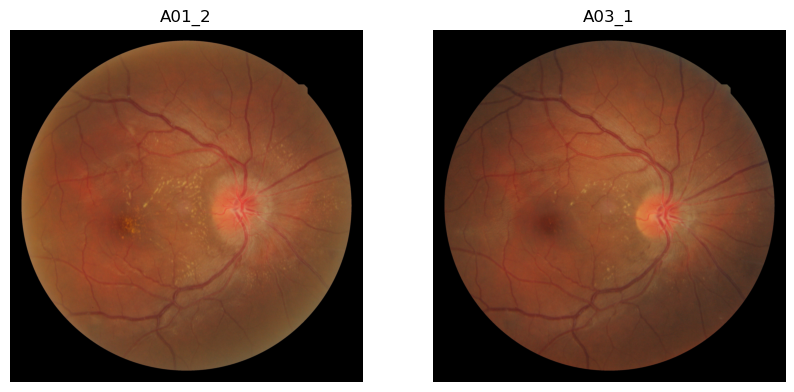

In [24]:
import matplotlib.pyplot as plt
import numpy as np
iter_dataloader = iter(dataloader)
first_batch = next(iter_dataloader)

img_ref, img_test, test_image_path, reference_image_pat = first_batch
def use_of_dataloader_next_iteration()->None:
    '''
    Define how iter and next work for a dataloader iteration 

    data_base_iteration = iter(dataloader)


    for _ in range(5):
        actual_batch= next(data_base_iteration)
        _,_, test_name, ref_name = actual_batch
        print(f'test image name: {test_name}, reference image name: {ref_name}')

    '''
    data_base_iteration = iter(dataloader)


    for _ in range(5):  
        actual_batch= next(data_base_iteration)
        _,_, test_name, ref_name = actual_batch
        print(f'test image name: {test_name}, reference image name: {ref_name}')

    return None



def show_image(test_image : torch.Tensor,
               reference_image: torch.Tensor,
               test_image_name: str = '',
               reference_image_name: str = ''
               )->None:
    #reference_image, test_image, test_image_name, reference_image_name = batch in case to use the dataloader itself
    reference_image_name, test_image_name = str(reference_image_name), str(test_image_name)
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(test_image.squeeze().permute(1,2,0).numpy())
    ax[0].set_title(f'{test_image_name}')
    ax[0].axis('off')
    ax[1].imshow(reference_image.squeeze().permute(1,2,0).numpy())
    ax[1].set_title(f'{reference_image_name}')
    ax[1].axis('off')
    plt.show()

show_image(test_image=img_test, reference_image=img_ref, test_image_name=Path(test_image_path[0]).stem, reference_image_name=Path(reference_image_path[0]).stem)



In [25]:
# NOTE USEFUL INFOs ON BATCH DIMENSIONs
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
data_base_iteration = iter(dataloader)
actual_batch= next(data_base_iteration)
t_im,r_im, test_path, ref_path = actual_batch
test_name, ref_name = Path(test_path[0]).stem, Path(ref_path[0]).stem
logs.info(f'''test image: NAME: {test_name}, SHAPE: {t_im.shape}, dTYPE: {type(t_im)}\n
reference image: NAME: {ref_name}, SHAPE: {r_im.shape}, dTYPE: {type(r_im)}
''')


[INFO] __main__ - test image: NAME: A01_2, SHAPE: torch.Size([1, 3, 2912, 2912]), dTYPE: <class 'torch.Tensor'>

reference image: NAME: A01_1, SHAPE: torch.Size([1, 3, 2912, 2912]), dTYPE: <class 'torch.Tensor'>



### CUSTOM DATALOADER

In [26]:
from torch.utils.data import Dataset
from PIL import Image as Pimage
from torchvision import transforms
from typing import Tuple, Dict, List
import torch
import random
import os
from pathlib import Path

class ImageRegistrationCustom(Dataset):
    logs=logging.getLogger(__name__)
    def __init__(self,
                dataset_folder_path: Path, # the path of FIRE dataset: Path.cwd().parent / 'Modules' / 'dataset' / 'FIRE'
                transform=None, 
                target_transform=None)->None:
        self.dataset_path = dataset_folder_path
        path_to_image_types = dataset_folder_path / 'Images' 
        path_to_deformation_types = dataset_folder_path /  'Images' / 'Test' 
        self.reference_images_paths = sorted(list(dataset_folder_path.glob('Images/Reference/*/*.jpg')))
        self.test_images_paths = sorted(list(dataset_folder_path.glob('Images/Test/*/*.jpg')))
        self.transform = transform # da trasformare le singole immagini? 
        self.target_transform = target_transform
        self.image_types = [d.name for d in path_to_image_types.iterdir() if d.is_dir()]
        self.deformation_types = [d.name  for d in path_to_deformation_types.iterdir() if d.is_dir()]

    # costruisci un dict  per abbreviare long... super res e mosaicing in A, S, P ... ?
    def load_image(self, 
                   index : str | int = 'random', # valuta la possibilità di mettere il random in una funzione a parte
                   deformation: str= '') ->PImage.Image: # given an index it get an image
        ''' 
        depending the type there are different possibilities
        depending which type f deformation to visualize
        ****aggiungi la possibilità di usare una trasformazione su un'immagine di test 
        '''
        images = list(self.dataset_path.glob('*/*/*/*'))
        
        if deformation == '':
            images = list(self.dataset_path.glob('*/*/*/*'))
        else:
            if deformation not in self.deformation_types:
                logs.info(f'to see possibile selection use the method .deformation_types')
                raise ValueError(f"Deformation type {deformation} not found in the dataset")
            else:
                images = list(self.dataset_path.glob(f'*/*/*/{deformation}/*'))
        
        if index.lower() == 'random' or not isinstance(index, int):
            idx = random.randint(0, len(images)-1)
        elif isinstance(index, int):
            idx=index
            if index not in range(0, len(images)):
                logs.warning(f'Unable to get the {index} image, another one casually get from the dirs')
                idx = random.randint(0, len(images) - 1)
                images = list(self.dataset_path.glob('*/*/*/*')) 
        
        return PImage.open(images[idx])      # aggiusta in una tupla 
        

    def __len__(self,
                info : bool = True):
        '''show the distribution of sample in the dataset path
        then the number of total files in the deepest folder'''
        if info:
            for dirpath, dirnames, filenames in os.walk(self.dataset_path):
                print(f"[INFO] - There are {len(dirnames)} directories and {len(filenames)} files in '{dirpath}'.")
        return len(list(self.dataset_path.glob('*/*/*/*')))
    
    def get_coupled_imgs(self,
                    index: bool|int = False,
                    deformation_choice : str = '' 
                    ) -> Tuple[torch.Tensor, torch.Tensor, str]:
        '''get the image pairs from the list of avaiable '''
        if deformation_choice == '' or deformation_choice not in self.deformation_types:
            test_images = list(self.dataset_path.glob('*/Test/*/*'))
            reference_images = list(self.dataset_path.glob('*/Reference/*/*'))
            logs.warning('Not a valid choice of deformation, the entire dataset is used as a batch') 
        else: 
            test_images = list(self.dataset_path.glob(f'*/*/Test/{deformation_choice}/*'))
            reference_images = list(self.dataset_path.glob(f'Images/Reference/{deformation_choice}/*.jpg'))
        if not index or index not in range(0, len(test_images)):
            index = random.randint(0, len(test_images)-1)
            
        test_image = test_images[index]
        reference_image = reference_images[index]
        test_reference,deformation, filename = get_dirs_of(test_image)
        logs.info(f'the selected/chosen image is {filename}, from {deformation} folder of {test_reference}')
        if self.transform:
            reference_image = self.transform(PImage.open(reference_image))  
        if self.target_transform:
            test_image = self.target_transform(PImage.open(test_image))
        return test_image, reference_image, deformation

    def __getitem__(self, 
                    index : bool|int = False,
                    deformation_choice: str = ''):
        ''' get the images couple of reference/test as tensor tuple'''
        test_image, reference_image, _ = self.get_coupled_imgs(index=index, deformation_choice=deformation_choice)
        if self.transform:
            test_image = self.transform(test_image)
        if self.target_transform:
            reference_image = self.target_transform(reference_image)
        return test_image, reference_image 
            
        

In [28]:
if IN_COLAB:
    %cd '/content'

In [ ]:
fire_dataset_path = FIRE_DATASET_PATH

imreg_dataset = ImageRegistrationCustom(dataset_folder_path=fire_dataset_path)
img= imreg_dataset.load_image(deformation='', index='random')

test_img, reference_img, deformation = imreg_dataset.get_coupled_imgs()

logs.info(f'the shape of the image *test_img* open with Image.open(Path): {np.asarray(PImage.open(test_img)).shape}, type {type(PImage.open(test_img))}\n just befor numpy conversion')
logs.info(f'the shape of the image *img_test* open with the Dataloader as a tensor: {img_test.shape}, type {type(img_test)}')

[WARNING] - not a valid choice of deformation, the entire dataset is used as a batch
the selected/chosen image is P19_2.jpg, from Mosaicing folder of Test
the shape of the image *test_img* open with Image.open(Path): (2912, 2912, 3), type <class 'PIL.JpegImagePlugin.JpegImageFile'>
 just befor numpy conversion
the shape of the image *img_test* open with the Dataloader as a tensor: torch.Size([1, 3, 2912, 2912]), type <class 'torch.Tensor'>


### DATALOADER + PYRAMID 
get the dataloader from simply dataloader and add pyramid transformation after transforms...

# PREPROCESS:  the images from the dataloader for the nn

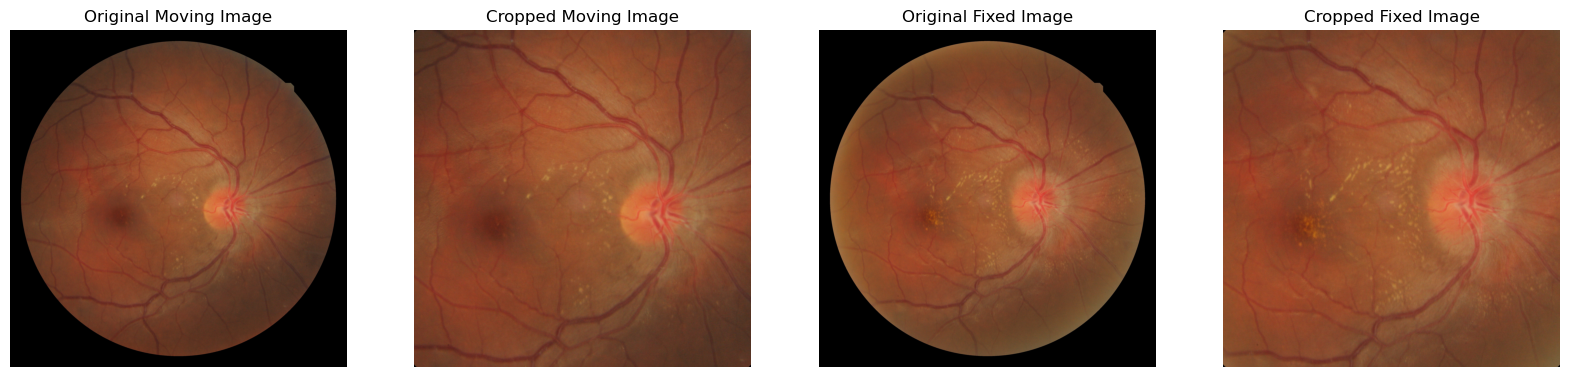

In [29]:
def crop_images(moving_image : Path | torch.Tensor,
                fixed_image : Path | torch.Tensor,
                show_images : bool = False
                )-> Tuple[torch.Tensor, torch.Tensor]:
    '''
    given the images it crop to the desired size 
    if requested the images are shown as confront between the original and the cropped
    
    Parameters:
    moving_image : Path | torch.Tensor
        the image to crop, it can be a path or a tensor given by the dataloader
    fixed_image : Path | torch.Tensor
        the image to crop, it can be a path or a tensor given by the dataloader 
    show_images : bool
        whether to show the images or not
        
    Returns:
        Tuple[torch.Tensor, torch.Tensor]: the cropped images
        
    '''

    #open the images depending on the type
    if isinstance(moving_image, Path):
        if not moving_image.exists():
            raise FileNotFoundError(f'{moving_image} not found')
        else:
            move_image = np.asarray(Image.open(moving_image))
    if isinstance(fixed_image, Path):
        if not fixed_image.exists():
            raise FileNotFoundError(f'{fixed_image} not found')
        else:
            fix_image = np.asarray(Image.open(fixed_image))
    
    if isinstance(moving_image, torch.Tensor):
        move_image = moving_image.detach().cpu().squeeze().permute(1,2,0).numpy()
    if isinstance(fixed_image, torch.Tensor):
        fix_image = fixed_image.detach().cpu().squeeze().permute(1,2,0).numpy()
    
    cropped_moving_image = move_image[int(move_image.shape[0]*LOWEDGE_BOX):int(move_image.shape[0]*HIGHEDGE_BOX), int(LOWEDGE_BOX*move_image.shape[1]):int(HIGHEDGE_BOX*move_image.shape[1]), :]
    cropped_fixed_image = fix_image[int(LOWEDGE_BOX*fix_image.shape[0]):int(fix_image.shape[0]*HIGHEDGE_BOX), int(LOWEDGE_BOX*fix_image.shape[1]):int(HIGHEDGE_BOX*fix_image.shape[1]), :]


    if show_images:
        # show the images
        fig, ax = plt.subplots(1, 4, figsize=(20, 5))
        ax[0].imshow(move_image)
        ax[0].set_title('Original Moving Image')
        ax[0].axis('off')
        ax[1].imshow(cropped_moving_image)
        ax[1].set_title('Cropped Moving Image')
        ax[1].axis('off')
        ax[2].imshow(fix_image)
        ax[2].set_title('Original Fixed Image')
        ax[2].axis('off')
        ax[3].imshow(cropped_fixed_image)
        ax[3].set_title('Cropped Fixed Image')
        ax[3].axis('off')
        plt.show()
    batched_moving = torch.from_numpy(cropped_moving_image).permute(2,0,1).unsqueeze(0)
    batched_fixed = torch.from_numpy(cropped_fixed_image).permute(2,0,1).unsqueeze(0)
    return batched_moving, batched_fixed

moved_image,fixed_image = crop_images(moving_image=img_ref, fixed_image=img_test, show_images=True)
    


In [30]:
logs.info(f'moved shape: {moved_image.shape},data type: {moved_image.dtype}, device: {moved_image.device},\nFix shape: {fixed_image.shape}, data type: {fixed_image.dtype}, device: {fixed_image.device}')

[INFO] __main__ - moved shape: torch.Size([1, 3, 1941, 1941]),data type: torch.float32, device: cpu,
Fix shape: torch.Size([1, 3, 1941, 1941]), data type: torch.float32, device: cpu


In [31]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from typing import Optional, Union, Sequence, TypedDict, NotRequired, Literal
from pathlib import Path
from PIL import Image as PImage
from torchvision import transforms
    

def crop_image_2_0(
        original_image: Path |torch.Tensor | np.ndarray,
        final_height : int,
        final_width : int,
        area_ratio: Optional[float] = 0.0,
        new_O_O : Optional[Sequence[int]]= [0, 0],
        new_image_center : Optional[Sequence[int]]= None,
        centred : bool= True,
        crop_style :  Literal['keep_size', 'shrink_to_fit'] = 'keep_size',
        keep_proportions : bool = False,
        device : torch.device =  torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        )-> Tuple[list[int], torch.Tensor]:
    '''
    the function purpouse is to crop the image in 3 different avaiable ways: centred along original image, keeping proportions, not centred

    Args:
        original_image (Path | torch.Tensor | np.ndarray): The image must be in the shape format ( C, H, W)
        final_height (int): the desired heigh of cropped image
        final_width (int): the desired width of cropped image
        area_ratio (Optional[float], optional): the area ratio between the original and the final image, to be defined only in case of keep_proportion is true
        new_O_O (Optional[[int]], optional): the new left high corner of the image useful to the trasformation of decropped H
        new_image_center (Optional[[int]], optional): to define the cropped area starting from a center point
        centred (Optional[centred_dict], optional): to define if the cropped image centre and the original image centre are the same
        crop_style ( Literal): define if keeps the dimension of the crop as costant sliding if outside the box or stop at the box, modifing the final_height and final_width
        keep_proportions (bool, optional): to define if the ratio H/h is the same for W/w
        device (torch.device): to set the code as device-invariant both for cpu and gpu

    Returns:
        new_O_O (Sequence[int]): the new left high corner of the image useful to the trasformation of decropped H
        cropped_image (np.ndarray): the cropped image in the shape format (C, H, 
    '''
    logs=logging.getLogger(__name__)
    #1. ===== READ IMAGE==========0
    if isinstance(original_image, Path):
        original_image = PImage.open(original_image)
        original_mode = original_image.mode
        if original_mode !='RGB':
            original_image=original_image.convert('RGB')
        original_image = transforms.ToTensor()(original_image)
        original_image= original_image.unsqueeze(0)
        original_image=original_image.to(device)
        logs.debug(f'{original_image.shape}')
    
    elif isinstance(original_image, np.ndarray): #NOTE shape it has to be in (C, H, W)
        original_image = torch.from_numpy(original_image).float()

        if original_image.ndim==3:
            original_image=original_image.unsqueeze(0)

        original_image=original_image.to(device)
    
    # NOTE to be used on image after taken by dataset/dataloader in shape (1, C, H, W)

    # =============HANDLE  MAX DIMENSIONS============
    _ ,_, original_height, original_width = original_image.shape
    original_center = [original_height//2, original_width//2]
    final_width = min(final_width, original_width)
    final_height = min(final_height, original_height)
    logs.debug(f'final_height: {final_height}; final_width: {final_width}')
    # ============= HaNDLE DIFFERENT OPTIONS============
    
    if area_ratio > 0.0 and keep_proportions: # NOTE General Case
        final_height = original_height/np.sqrt(area_ratio)
        final_width = original_width/np.sqrt(area_ratio)

    if keep_proportions: # Mantain proportion between original & finals
        if final_width > final_height:
            final_height = original_height*final_width/original_width
        else:
            final_width = original_width*final_height/original_height

    if area_ratio: # Set the final dimension depend from area ratio
        area_ratio = area_ratio if 0 < area_ratio <=1 else 1.0

        if final_width > final_height:
            final_height = original_height*original_width/(final_width*area_ratio)
        elif final_width < final_height:
            final_width = original_height*original_width/(final_height*area_ratio)
        else: # NOTE use the case for keep proportions and area ratio
            final_height = original_height/np.sqrt(area_ratio)
            final_width = original_width/np.sqrt(area_ratio)
    final_width= round(final_width)    
    final_height= round(final_height)
    # GET coordinatio of the left high point from center 
    if new_image_center != None:

        new_dim = [final_height//2, final_width//2]
        new_O_O = [ max(0,i-j) for i, j in zip(new_image_center, new_dim)]

    elif centred: 
        new_dim = [final_height//2, final_width//2]
        new_O_O = [ max(0, i-j) for i, j in zip(original_center, new_dim)]
        

    #===== GENERATE CROPPED IMAGE FROM ORIGINAL===========
    y0, x0 = new_O_O
    
    if crop_style == 'keep_size': # shift crop if necessary
        x0 = max(0, min(x0, int(original_width-final_width)))
        y0 = max(0, min(y0, int(original_height-final_height)))
        x1 = x0 + final_width
        y1 = y0 + final_height
        
        
    elif crop_style == 'shrink_to_fit':
        x1 = x0 + final_width
        y1 = y0 + final_height
        x1 = min(x1, original_width)
        y1 = min(y1, original_height)
        
        
    cropped_image = original_image[:, :, y0:y1, x0:x1]
    new_O_O = [y0, x0]
    return new_O_O, cropped_image
    

In [32]:
from PIL import Image as PImage
from torchvision import transforms

image_tobetested= PImage.open(dataset.test_images[0])
image_es= transforms.ToTensor()(image_tobetested)
image_es.shape

torch.Size([3, 2912, 2912])

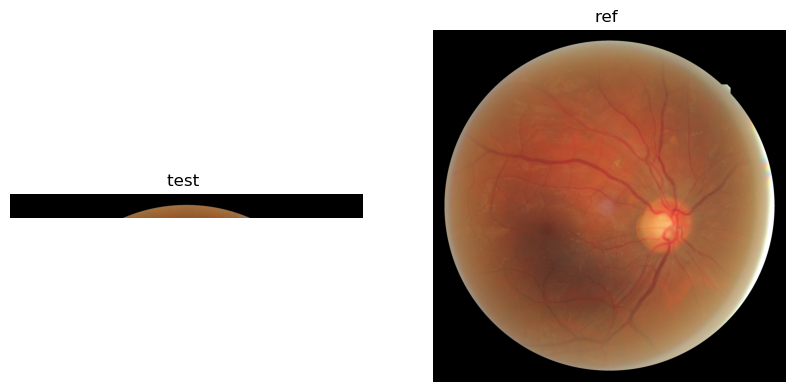

In [33]:
show_image(test_image=test_image[:,:,:200,:], reference_image=reference_image, test_image_name='test ', reference_image_name='ref ')

In [34]:
# given the two tensor with shape of [1, 3, 1941, 1941]
# get the pyramid of images from skimage.transform.pyramid_gaussian
from skimage.transform import pyramid_gaussian
from skimage.filters import gaussian
def coupled_gaussian_pyramid(fixed_image : np.float32 | torch.Tensor,
                             moving_image : np.float32 | torch.Tensor,
                             downscale : float = 2.0,
                             )-> (list[np.float32], list[np.float32], int):
    '''
    it takes two images to performa gaussian filter in 6 progressive steps
    Parameter
    ---------
    fixed_image : np.float32
      the fixed image

    moving_image : np.float32
      the moving image

    downscale : float
      the downscale factor to decide the factor of downsampling in each subsequent step

    Returns
    -------
    (list[np.float32], list[np.float32])
      the gaussian pyramid of the two images
    nChannel : int
      the number of channels of the image

    '''   
    logs= logging.getLogger(__name__)
    if np.ndim(fixed_image) != np.ndim(moving_image) or type(fixed_image) != type(moving_image):
      raise ValueError("the two images must have the same type and dimension")
    else:
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.squeeze().permute(1,2,0).numpy()
            moving_image = moving_image.squeeze().permute(1,2,0).numpy()
        if np.ndim(fixed_image) == 3:
            nChannel=fixed_image.shape[2]
            pyramid_fixed = tuple(pyramid_gaussian(gaussian(fixed_image, sigma=1, channel_axis=-1), downscale=downscale, channel_axis=-1))
            pyramid_moving = tuple(pyramid_gaussian(gaussian(moving_image, sigma=1, channel_axis=-1), downscale=downscale, channel_axis=-1))
        elif np.ndim(fixed_image) == 2:
            nChannel=1
            pyramid_fixed = tuple(pyramid_gaussian(gaussian(fixed_image, sigma=1, channel_axis=None), downscale=downscale))
            pyramid_moving = tuple(pyramid_gaussian(gaussian(moving_image, sigma=1, channel_axis=None), downscale=downscale))
        else:
            logs.warning(f"Unknown rank for an image: {np.ndim(fixed_image)}")

    return (pyramid_fixed, pyramid_moving, nChannel)
pyramid_ref, pyramid_mov, nChannel = coupled_gaussian_pyramid(fixed_image=fixed_image, moving_image=moved_image, downscale=2.0)


In [35]:
import numpy as np
import torch

def normalize(tens_image : torch.Tensor | np.ndarray
              )-> torch.Tensor:
    '''
    get a tensor to normalize it throught the scaler
    it does the same as cv2.normalize(IMAGE:np.ndarray, alpha=0, beta=1, norm_type= cv2.NORM_MINMAX, dtype=cv2.CV_32F)
    '''
    if isinstance(tens_image, torch.Tensor):
        maxim = np.max(tens_image.detach().cpu().numpy())
        minim = np.min(tens_image.detach().cpu().numpy())
        if maxim == minim:
            return torch.zeros_like(tens_image)
    else:
        maxim = np.max(tens_image)
        minim = np.min(tens_image)
        if maxim == minim:
            return np.zeros_like(tens_image)
    
    
    return (tens_image -minim)/ (maxim - minim)
    

In [36]:
norm_f_image = normalize(reference_image)

## INSPECTING DRMINE'S NN 
da supervisionare e rimuovere parti no nencessarie


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.color import rgb2gray
from torch.autograd import Function
import cv2 
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from typing import Optional, Literal

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logs.info(device)

[INFO] __main__ - cpu


In [ ]:
# NOTE For get the image use the dataset /dataloader already coded
#

In [ ]:
class HomographyNet(nn.Module):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    def __init__(self, device=device):
        '''
        imposing the parameters for the matrix of affine trasformation as some of a nn, 
        whose layer depends on the matrix expo respecting the resolution level
        
        PARAMETERS:
        -----------

        device : torch.device
            the device to use for the model, default is cuda if available, otherwise cpu
        B : torch.Tensor
            the basis of generator of the affine transformation, it is a tensor of shape (6, 3, 3) 
            where each slice B[i] is a base generator
        v1 : torch.nn.Parameter
            the parameters for the affine transformation at the highest resolution level, it is a tensor of shape
            (6, 1, 1) and it is initialized as zeros, it is a learnable parameter that will be updated during training
        vL : torch.nn.Parameter
            the parameters for the affine transformation at the lower resolution levels, it is a tensor of shape
            (6, 1, 1) and it is initialized as zeros, it is a learnable parameter that will be updated during training

        FORWARD INPUT: 
        --------------

        s : int
            the resolution level, it is an integer that can take values from 0 to 6, 
            where 0 is the highest resolution level and 6 is the lowest resolution level, it is used to decide which parameters to use for the affine transformation


        RETURNS:
        --------

        H : torch.Tensor
            the homography matrix, it is a tensor of shape (3, 3)
            obtained by matrix exponentiation of C

        '''
        super(HomographyNet, self).__init__()
        # affine transform basis matrices

        self.B = torch.zeros(6,3,3).to(device)
        self.B[0,0,2] = 1.0
        self.B[1,1,2] = 1.0
        self.B[2,0,1] = 1.0 
        self.B[3,1,0] = 1.0 
        self.B[4,0,0], self.B[4,1,1] = 1.0, -1.0
        self.B[5,1,1], self.B[5,2,2] = -1.0, 1.0

        #inizializzatione  parametri - base for initialize the affine matrix transformation as ones for affine
        self.v1 = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)
        self.vL = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)

    def forward(self, s): # depending the resolution the matrix expo define the approximation for the homography matrix
        C = torch.sum(self.B*self.vL,0)
        if s==0: # caso in cui ci si trovi nel più alto livello di risoluzione vine eaggiunto un parametro correttivo v1
            C += torch.sum(self.B*self.v1,0) 
        A = torch.eye(3).to(device)
        H = A
        for i in torch.arange(1,10): # prova torch.matrixexp(C)
            A = torch.mm(A/i,C) 
            H = H + A
        return H
Homography_net = HomographyNet()

In [ ]:
n_neurons = 100
class MINE(nn.Module): #https://arxiv.org/abs/1801.04062
    def __init__(self, nChannel: int):
        '''
        Creation of MINE net for calculating Mutual Information lower bound: Ml_lb
        - fc1 1st layer for blended rappresentation of reference and test
            (it gets the doubled inputs of reference and test image color channel)
        -fc2 2nd layer increases non linearity of the nn: elaboration single hidden layer
        -fc3 3rd layer elaborate a rapresentative number for each coupled (x,y): it performa calculation for mutual information


        Args:
            nChannel (int): number of color channels
        '''
        super(MINE, self).__init__()
        self.nChannel = nChannel
        self.fc1 = nn.Linear(2*self.nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 #NOTE  number of permutation for assesting MI_lb, (may be sufficient)
        

    def forward(self, x, ind):
        '''
        Calculate a T_score(x, y) for each bsize(permutation)
        z1: representing the matching couple scored: T(x_i, y_i) expecting to be high
        z2: representing the unmatching couple scored: T(x_i, y_j) expecting to be low when i!=j indeeed (log(exp(t)) t->0 --> 1 )


        Args:
            x (torch.Tensor): the input tensor of shape (1, 2*nChannel, H, W) where nChannel is the number of color channels, H and W are the height and width of the images
            ind (torch.Tensor): the indices available for the coupled images: (HxWxS) where S is the sampling ratio (0:1)
                                if u want to modify the batch of samples u have to modify this tensor: **they are the batch of point used for metric calculation**

        Returns:
            Ml_lb:  Mutual information lower bound
            z1, z2:  for visualization purpose
        '''
        x = x.view(x.size()[0]*x.size()[1],x.size()[2])
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind), device= ind.device)]
            while torch.equal(ind_perm, ind): #NOTE loop while aggiunto, prova ablation study con questo loop
                perm = ind[torch.randperm(len(ind), device=ind.device)]
                ind_perm = ind[perm]

            z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:self.nChannel],x[ind_perm,self.nChannel:2*self.nChannel]),1))))))
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize, z1, z2

In [ ]:
import cv2
from typing import Sequence
def extract_registration_params(pyramid_ref: Sequence[np.ndarray],
                        pyramid_test: Sequence[np.ndarray],
                        L: int =6,
                        sampling: float = 0.1,
                        nChannel : int = 3,
                        device : torch.device = None,
                        ) -> tuple[list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor],list[torch.Tensor], list[int], list[int]]:
  '''
  it registers the images calculating the random index for the homography to compare the registration and optimize the corresponding value xy_
  it also prepare the pyramidal images permuting the index position as (H,W,C) -> (C, H, W)

  Parameters
  ------------
  pyramid_fixed : Sequence[numpy.ndarray]
    the pyramid of multiresolution from the fixed image
  pyramid_moving : Sequence[numpy.ndarray]
    the pyramid of multiresolution from the moving image
  L : int
    the coarsest resolution level
  sampling : float
    the percentage of sampling to be used in homography optimization
  seed : int
    since the sampling is random the seed is useful for reproducibility

  Returns
  -------
  I_lst: list[torch.Tensor]
    the image pyramid of the fixed image listed as torch tensor of normalized value as np.float32
  J_lst: list[torch.Tensor]
    the image pyramid of the moving image listed as torch tensor of normalized value as np.float32
  x_ : list[torch.Tensor]
   the x coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  y_ : list[torch.Tensor]
    the y coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  xy_ : list[torch.Tensor]
    the coordinates for the homography mapping
  ind_ : list[torch.Tensor]
    the list of indeces from whose loss is calculated
  h_ : list[int]
    the heights of images in pyramid, necessary due downsampling
  w_ :  list[int]
    the widths of images in pyramid, necessary due downsampling
  '''
  if sampling > 1.0:
    raise ValueError("sampling must be between 0 and 1")
  if device == None:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

  I_lst,J_lst,h_lst,w_lst,xy_lst,ind_lst=[],[],[],[],[],[] #one feature for each level of the pyramid
  pyramid_I = pyramid_ref
  pyramid_J = pyramid_test

  for s in range(L): #
    I_ = torch.tensor(cv2.normalize(pyramid_I[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device)   # -------param pyramid_i , pyramif_j
    J_ = torch.tensor(cv2.normalize(pyramid_J[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device) # normalization for normalized coordinates

    if nChannel>1:
        I_lst.append(I_.permute(2,0,1)) # permute (H,W, C) -> (C, H, W)
        J_lst.append(J_.permute(2,0,1))
        h_, w_ = I_lst[s].shape[1], I_lst[s].shape[2]
        ind_ = torch.randperm(int(h_*w_*sampling), device=device) # FIXME usa sempre lo stesso bacino di pixel ( il primo 10%), se volessi renderlo davvero randomico dovrei usare ind_ = torch.randperm(int(h_*w_))[:int(h_*w_*sampling)] 
        ind_lst.append(ind_)
    else:
        I_lst.append(I_)
        J_lst.append(J_)
        h_, w_ = I_lst[s].shape[0], I_lst[s].shape[1]
        ind_ = torch.randperm(int(h_*w_*sampling), device=device)# FIXME usa sempre lo stesso bacino di pixel ( il primo 10%), se volessi renderlo davvero randomico dovrei usare ind_ = torch.randperm(int(h_*w_))[:int(h_*w_*sampling)] 
        ind_lst.append(ind_)
    h_lst.append(h_)
    w_lst.append(w_)

    y_, x_ = torch.meshgrid([torch.arange(0,h_).float().to(device), torch.arange(0,w_).float().to(device)], indexing='ij')
    y_, x_ = 2.0*y_/(h_-1) - 1.0, 2.0*x_/(w_-1) - 1.0 # normalization [0, 0] -> [-1, -1], [h,w] -> [1, 1]
    xy_ = torch.stack([x_,y_],2)
    xy_lst.append(xy_)
  return (I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst) # FIXME return everything, control if all of them are necessary for the training
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = extract_registration_params(pyramid_ref=pyramid_ref, pyramid_test=pyramid_mov, nChannel=nChannel)


In [ ]:
type(I_lst[0])

torch.Tensor

In [ ]:
def AffineTransform(I: torch.Tensor,
                    H: HomographyNet,
                    xv: torch.Tensor, 
                    yv: torch.Tensor
                    ) -> torch.Tensor:
    '''
    Apply a homography transformation to an image.

    Args:
        I (torch.Tensor): The input image, as the image to be warped
        H (torch.Tensor): The homography matrix, to apply.
        xv (torch.Tensor): The x coordinates of the points to transform, as x vector
        yv (torch.Tensor): The y coordinates of the points to transform, as y vector

    Returns:
        torch.Tensor: The transformed image.
    '''
    convert_on_same_device = False
    
    for tensor in [I, H, xv, yv]:
        if tensor.device == 'cuda':
            convert_on_same_device=True
    if convert_on_same_device:
        for tensor in [I, H, xv, yv]:
            tensor.to('cuda')

    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze() # NOTE use mode = 'nearest' & padding_mode='border'
    return J



def multi_resolution_loss(I_lst : list[torch.Tensor],
                          J_lst : list[torch.Tensor],
                          xy_lst : list[torch.Tensor],
                          ind_lst : list[torch.Tensor],
                          homography_net : HomographyNet,
                          mine_net : MINE,
                          
                          
                          nChannel : int = 3,
                          
                          )-> Tuple[torch.Tensor, list[torch.Tensor], list[torch.Tensor]]:
    '''
    the loss calculated along the multiresolution pyramid: loss = Sum[L]: mi/L()

    Args:
        I_lst (list[torch.Tensor]): the Multiresolution Pyramid of the REFERENCE image
        J_lst (list[torch.Tensor]): the Multiresolution Pyramid of the TEST image
        xy_lst (list[torch.Tensor]): the list of x,y coordinates on which the homography/affinity is applied (H)
        ind_lst (list[torch.Tensor]): the list of indices from which calculate the loss
        homography_net (HomographyNet): the homography matrix specified for multiresolution loss ( depending on the level s it change the compostision of exp(C))
            It has to be declared as hommography_net = HomographyNet() before the training loop and then passed as an argument to the loss function
        mine_net (MINE): nn to calculate the MI using the Donsker Varadam lower bound
        nChannel (int, optional): number of color channels. Defaults to 3.

    Returns:
        Tuple[torch.Tensor, list[torch.Tensor], list[torch.Tensor]]: it returns:
        loss (torch.Tensor) : the resulting summed mi calculation for all the pyramid levels ( to be backwarded in the nn training)
        z1 (list[torch.Tensor]) : the list of scores associated to the matching couple (x_i, y_i) for each pyramid level, to be used for visualization purpose
        z2 (list[torch.Tensor]) : the list of scores associated to the unmatching couple (x_i, y_j) for each pyramid level, to be used for visualization purpose
    '''
    assert I_lst[0].device == J_lst[0].device, "the two image pyramids must be on the same device"
    assert xy_lst[0].device == ind_lst[0].device, "the coordinates and the indices must be on the same device of the image pyramids"
    loss=I_lst[0].new_tensor(0.0) 
    z1, z2 = [], [] # NOTE use z1 z2 to track the loss doing on MINE net
    L = len(I_lst)
    for s in np.arange(L-1,-1,-1): #FIXME usa for s in range(L-1, -1, -1):...
      if nChannel>1: # for RGB images
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.cat([I_lst[s],Jw_],0).permute(1,2,0),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
      else: # for bn images
          Jw_ = AffineTransform(J_lst[s].unsqueeze(0).unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
          mi, zi, zj = mine_net(torch.stack([I_lst[s],Jw_],2),ind_lst[s])
          loss = loss - (1./L)*mi
          z1.append(zi)
          z2.append(zj)
    
    return loss, z1, z2

# mattes mutual information ( MMI)
def histogram_mutual_information(image1, image2):
    hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hgram / float(np.sum(hgram))
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))




In [ ]:
homo_net = HomographyNet()
homo_net.device

device(type='cuda')

In [ ]:
# funzione per controllare che tutti gli elementi selezionati siano sullo stesso device, eventualmente spostarli su quello preferenziale
from collections.abc import Mapping, Sequence
from torch import nn
import torch


def check_same_device(*objects, 
                      expected_device: torch.device | str | None = None
                      ) -> torch.device:
    """
    Check that all tensors and nn.Module parameters inside the given objects
    are on the same device.

    Parameters
    ----------
    *objects
        Any objects containing torch.Tensor, nn.Module, dict, list, tuple, etc.
    expected_device : torch.device | str | None
        If given, all tensors must be on this device.
        If None, the first tensor/device found is used as reference.

    Returns
    -------
    torch.device
        The reference device.

    Raises
    ------
    RuntimeError
        If a device mismatch is found.
    """
    ref_device = torch.device(expected_device) if expected_device is not None else None
    problems: list[str] = []

    def visit(obj, path: str) -> None:
        nonlocal ref_device

        if obj is None:
            return

        if isinstance(obj, torch.Tensor):
            if ref_device is None:
                ref_device = obj.device
            elif obj.device != ref_device:
                problems.append(f"{path}: {obj.device} != {ref_device}")
            return

        if isinstance(obj, nn.Module):
            for name, param in obj.named_parameters(recurse=True):
                visit(param, f"{path}.{name}")
            for name, buffer in obj.named_buffers(recurse=True):
                visit(buffer, f"{path}.{name}")
            return

        if isinstance(obj, Mapping):
            for key, value in obj.items():
                visit(value, f"{path}[{repr(key)}]")
            return

        if isinstance(obj, (list, tuple)):
            for i, value in enumerate(obj):
                visit(value, f"{path}[{i}]")
            return

        # Ignora altri tipi: int, float, str, np.ndarray, ecc.

    for i, obj in enumerate(objects):
        visit(obj, f"arg{i}")

    if ref_device is None:
        raise RuntimeError("No torch.Tensor or nn.Module parameters found to check.")

    if problems:
        raise RuntimeError(
            "Device mismatch detected:\n"
            + "\n".join(f"  - {p}" for p in problems)
        )

    return ref_device

In [ ]:
# FUnzione per controllare ricorsivamente che tutti gli elementi siano sullo stesso device


In [ ]:
from typing import Union, Callable, Sequence, Optional, Dict
from tqdm.auto import tqdm
from torch import nn
def drmine_registration_loop(
        homography_net : nn.Module,
        mi_net : nn.Module,
        pyramid_ref : Sequence[np.ndarray] | Sequence[torch.Tensor],
        pyramid_test : Sequence[np.ndarray] | Sequence[torch.Tensor],
        pyramid_loss_function : Callable = multi_resolution_loss,
        params_registration_function : Callable = extract_registration_params,
        sampling :float = 0.1 ,
        nChannel : int = 3,
        progression_bar : bool = True,
        iterations : int=500,
        lr : Union[float, dict] = 1.e-2,
        optimizer : Optional[torch.optim.Optimizer] = None,
        early_stopping :bool = False,
        patience : int = 0,
        min_delta : float = 1e-4,
        device : torch.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)-> Dict:
    '''
    the train loop to get the matrix of homography, execution time, iterations and loss_history. The function start from the pyramid list,
    then it set the hyperparameters for the registration
    
    Args:
        homography (HomographyNet): the homography used to structure the homography matrix
        mi_net (MINE): the net used to perform the calculus on mutual information
        pyramid_ref (Sequence[np.ndarray] | Sequence[torch.Tensor]): the pyramid of the reference image, it can be a sequence of numpy arrays or torch tensors
        pyramid_test (Sequence[np.ndarray] | Sequence[torch.Tensor]): the pyramid of the test image, it can be a sequence of numpy arrays or torch tensors
        pyramid_loss_function (Callable, optional): the function used to calculate the loss, it has to be a function that take into account the pyramid structures,
            as for the xy_lst, ind_lst. Defaults to multi_resolution_loss.
        params_registration_function (Callable, optional): the function used to extract the parameters for the registration, it has to be a function that take into account the pyramid structures,
        sampling (float): the sampling percentage of index list to get into consideration for loss calculation
        nChannels (int, optional): the number of color channels of the images. Defaults to 3, RGB
        progression_bar (bool): to visualize the progression of registration
        iterations (int, optional): numbers of iteration for the training loop. Defaults to 500.
        lr (Union[float, dict], optional): learning rate of params for the optimizer it has to have the format for specified params as {'param_name':lr_param,...}.
            Consider that the 3 main params are vL, v1, mine_net.params. Defaults to 1.e-2.
        
        optimizer (Optional[torch.optim.Optimizer], optional): optimizer for training. Defaults to None.
        early_stopping (bool, optional): whether to use early stopping. Defaults to False.
        patience (int, optional): number of iterations to wait before stopping. Defaults to 10.
        min_delta (float, optional): minimum change in loss to qualify as improvement. Defaults to 1e-4.
        device (torch.device, optional): device to use for training. Defaults to torch.device('cuda' if torch.cuda.is_available() else 'cpu').

    Returns:
       dict: Returning direct result of registration: The homography_net, the execution time of the training loop, the loss history during the training loop in adict form
    '''
    logs=logging.getLogger(__name__)
    # ========== ORGANIZE THE STRUCTURE BEFORE============
    homography_net.to(device)
    mi_net.to(device)
    homography_net.train()
    mi_net.train()
    loss_history = []
    patience = round(iterations/10) if patience == 0 else patience
    registration_dict = {}
    sampling = sampling if 0 < sampling <=1.0 else 0.1
    counter_patience = 0
    best_loss= -float(np.inf)
    if progression_bar:
        pbar= tqdm(range(iterations), desc='DRMINE registration')
    else:
        pbar = range(iterations)


    #=========== GET THE USEFUL PARAMS FOR THE TRAINING LOOP==================
    I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = params_registration_function(pyramid_ref=pyramid_ref, pyramid_test=pyramid_test, sampling=sampling, nChannel=nChannel, device=device)
    if isinstance(lr, dict):
        v1_lr = lr.get('v1', 1.e-5) #NOTE use a Parameter to impose these values
        vL_lr = lr.get('vL', 1.e-3)
        mine_lr = lr.get('mi', 1.e-2)
    else:
        v1_lr = vL_lr = mine_lr = lr

    # ========== JUST BEFORE REGISTRATION LOOP ASSERT ALL TENSOR.DEVICE to be the SAME============
        
        
    optimizer = optimizer if optimizer else optim.Adam([ # NOTE aggiunte le [] per homography_net.v1 e homography_net.vL
        {'params': [homography_net.v1], 'lr': v1_lr},
        {'params': [homography_net.vL], 'lr': vL_lr},
        {'params': mi_net.parameters(), 'lr': mine_lr}
    ], amsgrad=True)
    
    with block_time() as timer:
        for i in pbar:
            optimizer.zero_grad()
            loss, _, _ = pyramid_loss_function(I_lst, J_lst, xy_lst, ind_lst, homography_net, mi_net, nChannel=nChannel) # questa parte molto artificiosa può sostituirsi con un dict pyr_data ad esempio
            loss_history.append(-loss.item())
            loss.backward()
            optimizer.step()
            
            #============ EARLY STOPPING CHECK===========
            if early_stopping:
                
                best_loss = max(loss_history)
                if loss_history[-1] > best_loss + min_delta:
                    best_loss = loss_history[-1]
                    counter_patience = 0
                else:
                    counter_patience += 1
                if counter_patience >= patience:
                    logs.info(f'Early stopping at iteration {i} with best loss {best_loss}')
                    break
    execution_time = timer[0]
    homography_net.eval()
    mi_net.eval()

    registration_dict['affine_matrix']= homography_net
    registration_dict ['execution_time'] = execution_time
    registration_dict['loss_history'] = loss_history # NOTE define also ITERATION_NUMS
    registration_dict['v1_lr'] = v1_lr
    registration_dict['vL_lr']= vL_lr
    registration_dict['mine_lr'] =mine_lr
    registration_dict['index_sampling'] = sampling
    if early_stopping:
        registration_dict['patience'] = patience
        registration_dict['best_loss']= best_loss
        registration_dict['min_delta']= min_delta
    
    return registration_dict

In [ ]:
from typing import Sequence
import numpy as np
def unnormalize_matrix(H: torch.Tensor,
                        image_shape: list[int, int],
                        transformation_map : list = []) -> torch.Tensor:
    '''
    since the homography is calculated on normalized coordinates this function unnormalize the homography matrix to be applied on the original image
    '''
    normalized_affine_matrix = H.cpu().detach().numpy()
    h, w = image_shape
    if transformation_map == []:
        transformation_map = [[2/(w-1), 0, -1], [0, 2/(h-1), -1], [0, 0, 1]] #NOTE definiscila a partire da alpha e beta così come norm...
    unnormalized_affine_matrix = np.linalg.inv(np.matmul(np.matmul(np.linalg.inv(transformation_map), normalized_affine_matrix), transformation_map))
    return torch.tensor(unnormalized_affine_matrix).to(H.device)

def decrop_matrix(H: torch.Tensor,
                    offset_x0 : int,
                    offset_y0 : int) -> torch.Tensor:
    '''
    Since the homography is calculated on cropped images,
    this function decrop the unnormalized homography matrix to be applied on the original image

    Parameters:
    H (torch.Tensor): The unnormalized homography matrix.
    offset_x0 (int): The x offset of the cropping. It is the number of pixel corresponding to the high left corner of the image, coord x.
    offset_y0 (int): The y offset of the cropping. It is the number of pixel corresponding to the high left corner of the image, coord y.

    '''
    tx= -offset_x0
    ty= -offset_y0
    transformation_map_crop_to_full = [[1, 0, tx], [0, 1, ty], [0, 0, 1]]
    
    decropped_affine_matrix = np.matmul(np.matmul(np.linalg.inv(transformation_map_crop_to_full), H), transformation_map_crop_to_full)
    return torch.tensor(decropped_affine_matrix).to(H.device)

#### reproduce the net work for a single image resolution

In [ ]:
import cv2
I5_normcv2 = cv2.normalize(I_lst[5].permute(1,2,0).cpu().numpy(), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)


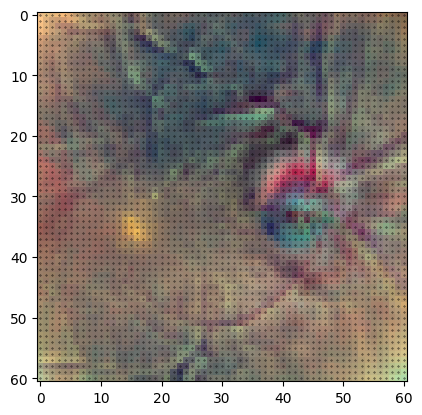

In [ ]:
I5_norm = normalize(I_lst[5])
J5_norm = normalize(J_lst[5])

y5 = y_[5]
xy5 = xy_lst[5]
ind5 = ind_lst[5]
h5 = h_lst[5]
w5 = w_lst[5]

x5, y5 = torch.meshgrid([torch.arange(0,h5).float(), torch.arange(0,w5).float()], indexing='ij')
xy5 = torch.stack([x5,y5],2)

x_coords = xy5[..., 0].flatten()
y_coords = xy5[..., 1].flatten()
diff5 = (I5_norm - J5_norm)
diff5_norm = normalize(diff5)
plt.imshow(diff5_norm.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.1)



In [ ]:
xy5[:10,:10,:].numel() #NOTE get the number of elements in the tensor

200

In [ ]:
logs=logging.getLogger(__name__)
n_neurons = N_NEURONS
class MINE_INSIDE(nn.Module): # unravel the functioning of the net
    
    def __init__(self, nChannel: int):
        super(MINE_INSIDE, self).__init__()
        self.fc1 = nn.Linear(2*nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient

    def forward(self, y, ind):
        x = y.view(y.size()[0]*y.size()[1],y.size()[2]) #flatten the tensor to use the rand perm and get random index
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind), device=device)] # perchè non provare a farlo qua dentro usando torch.randperm(int(len(x[0]*sampling)))
            z1_first = F.relu(self.fc1(x[ind,:]))
            z2_first = self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))
            z1_second = F.relu(self.fc2(z1_first)) 
            z2_second = self.fc2(z2_first)
            z1 = self.fc3(z1_second) 
            z2 = self.fc3(z2_second)
            #z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            #z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))))))
            logs.info(f'''x[ind,0:nChannel] shape : {x[ind,0:nChannel].shape},
                x[ind_perm,nChannel:2*nChannel]shape : {x[ind_perm,nChannel:2*nChannel].shape},
                the input_shape is : {x[ind,:].shape},
                after the first layer the output shape is : {z2_first.shape},
                after the second layer the output shape is : {z1_second.shape},
                the third layer shape : {z2.shape}.
                The original tensor is x: {y.shape}, after the forward pass the shae change into: {x.shape}
                ''')
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize


In [ ]:

if TEST_FOR['DRMINE']:  
      
    homography_net = HomographyNet()

    Jw5 = AffineTransform(J_lst[5].unsqueeze(0), homography_net(5), xy5[:,:, 0], xy5[:,:, 1]).squeeze()
    x =torch.cat([I_lst[5], Jw5], 0).permute(1,2,0)
    ind =ind5
    mine_net = MINE_INSIDE(nChannel=3).to(device)
    mi = mine_net(x, ind)
    x_new = x.view(x.size()[0]*x.size()[1],x.size()[2])
    x_new.shape

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

In [ ]:
import torchinfo
if  TEST_FOR['DRMINE']:
    minet = MINE(nChannel=3).to(device)
    s=3
    I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = extract_registration_params(pyramid_ref=pyramid_ref, pyramid_test=pyramid_mov, nChannel=nChannel)
    Jws = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:, 0], xy_lst[s][:,:, 1]).squeeze()
    x =torch.cat([I_lst[s], Jws], 0).permute(1,2,0)
    ind =ind_lst[s]
    S_summary = torchinfo.summary(minet, input_data=(x, ind))
    print(S_summary)


Layer (type:depth-idx)                   Output Shape              Param #
MINE                                     --                        --
├─Linear: 1-1                            [5904, 100]               700
├─Linear: 1-2                            [5904, 100]               10,100
├─Linear: 1-3                            [5904, 1]                 101
├─Linear: 1-4                            [5904, 100]               (recursive)
├─Linear: 1-5                            [5904, 100]               (recursive)
├─Linear: 1-6                            [5904, 1]                 (recursive)
Total params: 10,901
Trainable params: 10,901
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 128.72
Input size (MB): 1.46
Forward/backward pass size (MB): 18.99
Params size (MB): 0.04
Estimated Total Size (MB): 20.50


tensor([  0.,   0.,   0.,  ..., 485., 485., 485.])

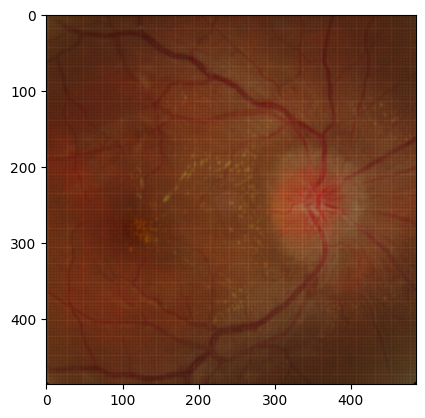

In [ ]:

# # the correspondence between the coordinates' values and the image
import matplotlib.pyplot as plt
import numpy as np

I3 = normalize(I_lst[2])
J3 = normalize(J_lst[2])

y3 = y_[3]
xy3 = xy_lst[2].detach().cpu().numpy()
ind3 = ind_lst[2]
h3 = h_lst[2]
w3 = w_lst[2]
x3, y3 = torch.meshgrid([torch.arange(0,h3).float(), torch.arange(0,w3).float()], indexing='ij')
xy3 = torch.stack([x3,y3],2)

x_coords = xy3[..., 0].flatten()
y_coords = xy3[..., 1].flatten()
diff3 = (I3 - J3)
diff3_norm = normalize(diff3)
plt.imshow(I3.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.001)
x_coords


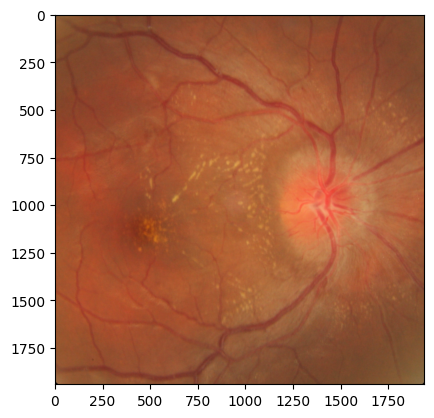

In [ ]:
plt.imshow(I_lst[0].permute(1,2,0).detach().cpu().numpy())

### Apply transformation to original uncropped image

In [ ]:
original_I.shape

(2912, 2912, 3)

In [ ]:
from skimage import io
I_path = FIRE_DATASET_PATH / 'Images' / 'Test' / 'Longitudinal_Studies' / 'A01_2.jpg'
J_path = FIRE_DATASET_PATH / 'Images' / 'Reference' / 'Longitudinal_Studies' / 'A01_1.jpg'

original_I = io.imread(I_path).astype(np.float32) # ref image
original_J = io.imread(J_path).astype(np.float32) # test image
height, width, nchannel = original_I.shape
I = original_I[int(1.5*height/9):int(7.5*height/9),int(1.5*width/9):int(7.5*width/9)]
J = original_J[int(1.5*height/9):int(7.5*height/9),int(1.5*width/9):int(7.5*width/9)]
I_t = torch.tensor(I).to(device) # without Gaussian
J_t = torch.tensor(J).to(device) # without Gaussian
H = homography_net(0)
if nChannel>1:
    J_w = AffineTransform(J_t.permute(2,0,1).unsqueeze(0), H, xy_lst[0][:,:,0], xy_lst[0][:,:,1]).squeeze().permute(1,2,0)
else:
    J_w = AffineTransform(J_t.unsqueeze(0).unsqueeze(0), H , xy_lst[0][:,:,0], xy_lst[0][:,:,1]).squeeze()

Text(0.5, 1.0, 'Difference image after registration')

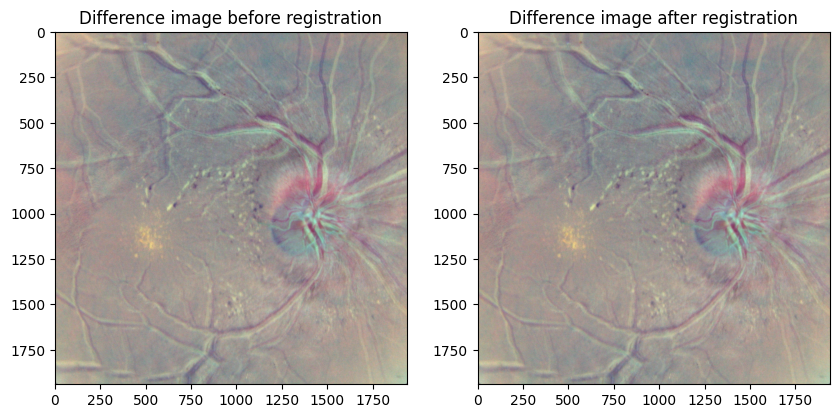

In [ ]:
D = J_t - I_t
D_w = J_w - I_t
D = (D - torch.min(D))/(torch.max(D) - torch.min(D))
D_w = (D_w - torch.min(D_w))/(torch.max(D_w) - torch.min(D_w))
%matplotlib inline
fig=plt.figure(figsize=(10,10))
fig.add_subplot(1,2,1)
plt.imshow(D.cpu().data)
plt.title("Difference image before registration")
fig.add_subplot(1,2,2)
plt.imshow(D_w.cpu().data)         
plt.title("Difference image after registration")

In [ ]:
normalized_affine_matrix = H.detach().cpu().numpy()

h = I.shape[0]
w = J.shape[1]

test_transform = [[2/w, 0, -1],[0, 2/h, -1], [0,0,1]] # a trasformation map to pass from normalized coordinates to pixel coordinates ([-1,1] to [w, h], since we used a 3x3 it will be [w, h ,1])
unnormalized_affine_matrix = np.linalg.inv(np.matmul(np.matmul(np.linalg.inv(test_transform), normalized_affine_matrix), 
                                                     test_transform)) # to adapt the H matrix to pixel coords unnormalized

tx = -int(1.5*original_I.shape[0]/9)
ty = -int(1.5*original_I.shape[0]/9)
move_origin = np.array([[1,0,tx],[0,1,ty],[0,0,1]])

matrix_for_full_image = np.matmul(np.matmul(np.linalg.inv(move_origin), unnormalized_affine_matrix), move_origin)

In [ ]:
rows,cols,ch = original_J.shape
dst = cv2.warpAffine(original_J, matrix_for_full_image[:2], (cols,rows))

Text(0.5, 1.0, 'Difference image after registration')

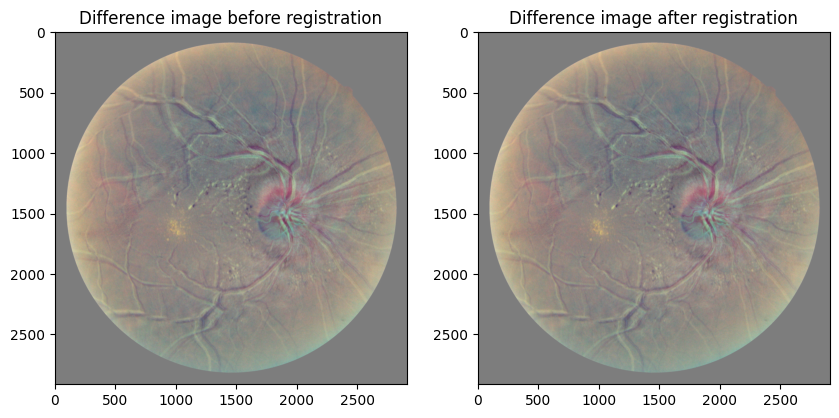

In [ ]:
D = original_J - original_I
D_w = dst - original_I
D = (D - np.min(D))/(np.max(D) - np.min(D))
D_w = (D_w - np.min(D_w))/(np.max(D_w) - np.min(D_w))
%matplotlib inline
fig=plt.figure(figsize=(10,10))
fig.add_subplot(1,2,1)
plt.imshow(D)
plt.title("Difference image before registration")
fig.add_subplot(1,2,2)
plt.imshow(D_w)         
plt.title("Difference image after registration")

In [ ]:
# rearrange the loss funciton parameter to take inn two objects, the image of the dataset and the predicted through the MINE net 
# per una coppia di immagini :
# train -> loss
# omografia -> loss ...

In [ ]:
h = 4
w = h
image = torch.Tensor(np.random.randn(h, w, 3))

index = torch.randperm(int(h*w))


for i in range(len(ind_lst)):
    logs.debug(f'the {i}-th element has {len(ind_lst[i])} elements')

the 0-th element has 376748 elements
the 1-th element has 94284 elements
the 2-th element has 23619 elements
the 3-th element has 5904 elements
the 4-th element has 1488 elements
the 5-th element has 372 elements


## Functioning


In [37]:
ground_path = CONTROL_POINTS_FOLDER
control_points = [n for n in list(ground_path.glob('*')) if n.name.__contains__('A01')]
control_points

[WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Ground Truth/control_points_A01_1_2.txt')]

In [38]:
# prendere le coordinate dalla lista dei valori di riferimento

def get_coords(image_name : str, #es A01
               ground_truth_path : Path = CONTROL_POINTS_FOLDER, # in this case: control_points_[Image pair name]_1_2.txt
               )-> tuple[list[list[float]], list[list[float]]]:
    '''
    get the coordinates of control points associate to the image in list of coords format
    the format in the ground truth folder:

        [reference_point_1_x] [reference_point_1_y] [test_point_1_x] [test_point_1_y]

        [reference_point_2_x] [reference_point_2_y] [test_point_2_x] [test_point_2_y]

    it will returns the list of coords for both test(_2) and reference(_1) image in the format test(x,y) ; reference(x,y)
    '''
    if not ground_truth_path.exists():
        raise FileNotFoundError(f'directory {ground_truth_path} not found')
    txt_file_path = [n for n in list(ground_truth_path.glob('*')) if n.name.__contains__(image_name)]
    reference_points, test_points = [], []
    with open(txt_file_path[0], 'r') as file:
        lines = file.readlines()
        for line in lines:
            ref_x, ref_y, test_x, test_y = line.split()
            reference_points.append([float(ref_x), float(ref_y)])
            test_points.append([float(test_x), float(test_y)])
    return test_points, reference_points


ground_path = CONTROL_POINTS_FOLDER
test_points, reference_points = get_coords(image_name='A01') # dato che la valutazione è sull'ultimo è questa quella che dovrebbe pesare di più sulla scala delle MI

In [39]:
get_coords(image_name='A01')

([[388.0, 822.0],
  [357.0, 1849.0],
  [1153.0, 2487.0],
  [1843.0, 400.0],
  [2358.0, 2000.0],
  [2556.0, 1198.0],
  [1949.0, 1194.0],
  [670.0, 1192.0],
  [1944.0, 1460.0],
  [1328.0, 1784.0]],
 [[332.0, 872.0],
  [370.0, 1897.0],
  [1212.0, 2483.0],
  [1761.0, 348.0],
  [2384.0, 1912.0],
  [2527.0, 1099.0],
  [1922.0, 1131.0],
  [642.0, 1222.0],
  [1930.0, 1408.0],
  [1339.0, 1768.0]])

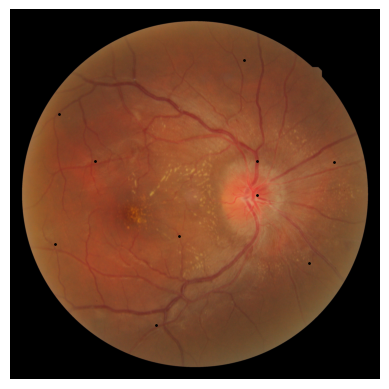

In [43]:
x_test = [test_point[0] for test_point in test_points]
y_test = [test_point[1] for test_point in test_points]
ref_to_open = np.asarray(img_ref.squeeze().permute(1,2,0))
plt.scatter(x_test, y_test, c='black', s=1)
plt.axis('off')
plt.imshow(ref_to_open)

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], shape=(2912, 2912, 3), dtype=float32)

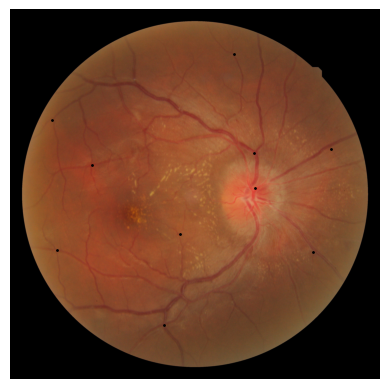

In [45]:
x_ref = [reference_point[0] for reference_point in reference_points]
y_ref = [reference_point[1] for reference_point in reference_points]
test_to_open = np.asarray(img_test.squeeze().permute(1,2,0))
plt.scatter(x_ref, y_ref, c='black', s=1)
plt.axis('off')
plt.imshow(test_to_open)

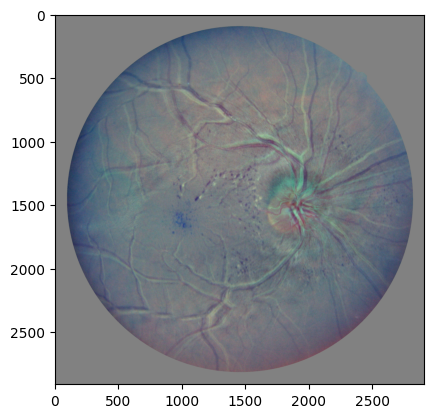

In [ ]:
im_ref = normalize(img_ref.squeeze().permute(1,2,0))
im_test = normalize(img_test.squeeze().permute(1,2,0))
im = normalize(im_ref - im_test)
plt.imshow(im)


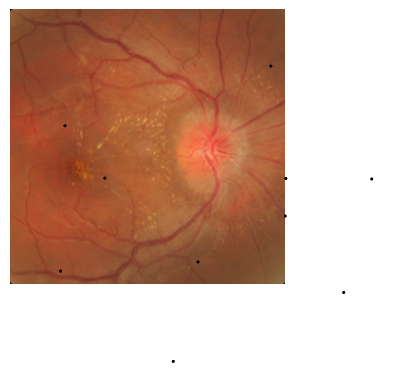

In [ ]:
if TEST_FOR['DRMINE']:   
     
    s = 0
    Is = normalize(I_lst[s])
    Js = normalize(J_lst[s])

    ys = y_[s]
    xys = xy_lst[s].detach().cpu().numpy()
    inds = ind_lst[s]
    hs = h_lst[s]
    ws = w_lst[s]
    xs, ys = torch.meshgrid([torch.arange(0,hs).float(), torch.arange(0,ws).float()], indexing='ij')
    xys = torch.stack([xs,ys],2)

    x_coords = xys[..., 0].flatten()
    y_coords = xys[..., 1].flatten()
    x_test = [test_point[0] for test_point in test_points]
    y_test = [test_point[1] for test_point in test_points]

    diffs = (Is - Js)
    diffs_norm = normalize(diffs)
    # creare una funzione per visualizzare i punti di riferimento e le corrispondenze tra i punti di riferimento e le immagini
    def show_image_and_reference_points(s: int, 
                                        coordinates: list[list[float]],
                                        title : str = get_data_time(),
                                        uniform_color : bool = True,
                                        image: torch.Tensor = Is,):
        """
        TO BE COMPLETED
        ---------------
        
        Args:
            s (int): _description_
            coordinates (list[list[float]]): _description_
            title (str, optional): _description_. Defaults to get_data_time().
            uniform_color (bool, optional): _description_. Defaults to True.
            image (torch.Tensor, optional): _description_. Defaults to Is.
        """
        
        x_test = [test_point[0] for test_point in coordinates]
        y_test = [test_point[1] for test_point in coordinates]
        result_image_folder = RESULT_PATH /'ImgRes'
        plt.imshow(image.permute(1,2,0).detach().cpu().numpy())
        plt.axis('off')
        if not uniform_color:
            colors = plt.cm.jet(np.linspace(0, 1, len(coordinates)))
        else: 
            colors = ['black'] * len(coordinates)
        '''for i, (x, y) in enumerate(coordinates):
            plt.scatter(x, y, c=colors[i], s=1)'''
        plt.scatter(x_test, y_test, c=colors, s=1)
        plt.savefig(result_image_folder / f'{title}.png')
        


    show_image_and_reference_points(s=0, coordinates=test_points), show_image_and_reference_points(s=0, coordinates=test_points, title='Is_and_test_points')


In [ ]:
#non tutti i punti sono papabili, pertanto bisogna tolgiere quelli che sono out of the box: (1.5/9. - 7.5/9) * shape image
xshape, yshape = ORIGINAL_SHAPE
test_points, reference_points
def remove_coord_outside_box(coords : list[list[float]],
                            original_shape : tuple[int] = ORIGINAL_SHAPE,
                            upper_edge: float = 7.5/9.,
                            lower_edge: float = 1.5/9.,
                            )-> list[list[float]]:
    '''
    remove the coordinates that are outside the box of the cropped image
    '''
    logs=logging.getLogger(__name__)
    xshape, yshape = original_shape
    print(f'xshape: {xshape}, yshape: {yshape}')
    modified_coords = []
    xlimit, ylimit = int(xshape*upper_edge), int(yshape*upper_edge)
    xbase, ybase = int(xshape*lower_edge), int(yshape*lower_edge)
    
    for coord in coords:
        x_coord , y_coord = coord
        if x_coord not in range(xbase, xlimit +1):
            logs.info(f'since {x_coord} is outside the box, {x_coord, y_coord} will be removed') # logging
            continue
        elif y_coord not in range(ybase, ylimit +1):
            logs.info(f'since {y_coord} is outside the box, {x_coord, y_coord} will be removed') #logging
            continue
        else:
            x_coord -= xbase
            y_coord -= ybase
            logs.info(f'the new coord are {x_coord}, {y_coord}')#logging
            coord = (x_coord, y_coord)
            modified_coords.append(coord)

    return modified_coords


# if just one of the value in the coords is outside the box of the image, it should be removed
# then remove from both x and y coords the min value of  1.5/9.*shape[0] to reassest the coords in the visualization
# remember to pack two tuple of coords in the list to get the evaluation, just after the crop and before it.

xshape: 2912, yshape: 2912
since 388.0 is outside the box, (388.0, 822.0) will be removed
since 357.0 is outside the box, (357.0, 1849.0) will be removed
since 2487.0 is outside the box, (1153.0, 2487.0) will be removed
since 400.0 is outside the box, (1843.0, 400.0) will be removed
the new coord are 1873.0, 1515.0
since 2556.0 is outside the box, (2556.0, 1198.0) will be removed
the new coord are 1464.0, 709.0
the new coord are 185.0, 707.0
the new coord are 1459.0, 975.0
the new coord are 843.0, 1299.0
xshape: 2912, yshape: 2912
since 332.0 is outside the box, (332.0, 872.0) will be removed
since 370.0 is outside the box, (370.0, 1897.0) will be removed
since 2483.0 is outside the box, (1212.0, 2483.0) will be removed
since 348.0 is outside the box, (1761.0, 348.0) will be removed
the new coord are 1899.0, 1427.0
since 2527.0 is outside the box, (2527.0, 1099.0) will be removed
the new coord are 1437.0, 646.0
the new coord are 157.0, 737.0
the new coord are 1445.0, 923.0
the new coor

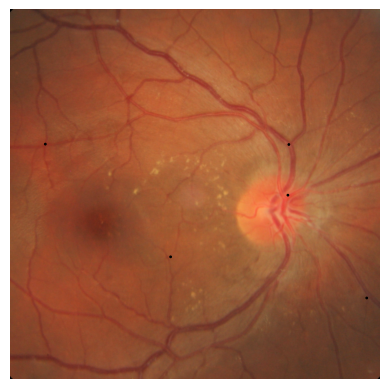

In [ ]:
cropped_test_points = remove_coord_outside_box(test_points)
cropped_reference_points = remove_coord_outside_box(reference_points)
if TEST_FOR['DRMINE']:
    show_image_and_reference_points(s=0, coordinates=cropped_test_points, image=Js, title='Js_and_cropped_test_points')

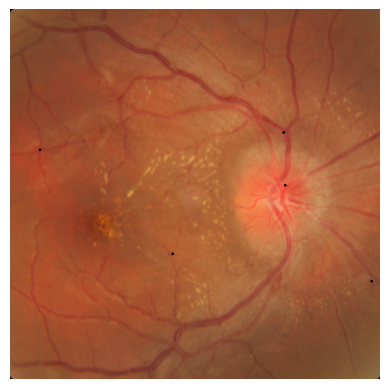

In [ ]:
if TEST_FOR['DRMINE']:
    show_image_and_reference_points(s=0, coordinates=cropped_reference_points, title='Is_and_reference_points') # Is and reference points

In [ ]:
def AffineTransform(I, H, xv, yv):
    # apply homography
    xvt = (xv*H[0,0]+yv*H[0,1]+H[0,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    yvt = (xv*H[1,0]+yv*H[1,1]+H[1,2])/(xv*H[2,0]+yv*H[2,1]+H[2,2])
    J = F.grid_sample(I,torch.stack([xvt,yvt],2).unsqueeze(0), align_corners=True).squeeze()
    return J # it's torch.Tensor type
xv = torch.Tensor([x[0] for x in cropped_test_points])
yv = torch.Tensor([x[1] for x in cropped_test_points])
homography_net = HomographyNet()
homo_matrix = homography_net(0)


In [ ]:
loss_vals = []
for s in np.arange(5, -1, -1):
    Jw_ = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:,0], xy_lst[s][:,:,1]).squeeze()
    logs.debug(f'Jw_ shape is {Jw_.shape}')
    loss_val = torch.cat([I_lst[s], Jw_], 0)
    loss_vals.append(loss_val)

Jw_ shape is torch.Size([3, 61, 61])
Jw_ shape is torch.Size([3, 122, 122])
Jw_ shape is torch.Size([3, 243, 243])
Jw_ shape is torch.Size([3, 486, 486])
Jw_ shape is torch.Size([3, 971, 971])
Jw_ shape is torch.Size([3, 1941, 1941])


In [46]:
def get_warped_coords(test_coords:torch.Tensor |np.ndarray, 
                      affine_matrix,
                      )->tuple[list[int, int]]:
    
    '''Get the warped coordinates applying the homography matrix to the test coordinates
    Parameters:
    test_coords : torch.Tensor | np.ndarray
        the coordinates to be transformed, shape (N, 2)
    affine_matrix 
        the homography matrix, shape (3, 3)
        
    Returns:
    tuple[list[int, int]]
        the transformed coordinates as list of integer tuples'''
    ones = torch.ones(test_coords.shape[0], 1)
    #print(f'ones is : \n{ones}  of shape {ones.shape}\n\n')
    homogeneous_points = torch.cat([test_coords, ones], dim=1)
    #print(f'homogeneous_points is : \n{homogeneous_points} of shape {homogeneous_points.shape}\n\n')
    # Apply homography
    transformed_points = torch.matmul(homogeneous_points, affine_matrix.T)
    #print(f'affine matrix is : \n{affine_matrix} of shape \t{affine_matrix.shape}\n\n')
    #print(f'transformed_points are : \n{transformed_points} of shape \t{transformed_points.shape}\n\n')
    # Convert back to Cartesian coordinates
    transformed_points = transformed_points[:, :2] / transformed_points[:, 2].unsqueeze(1)
    transformed_points_int_list = [[int(round(x)), int(round(y))] for x, y in transformed_points.tolist()]
    
    return transformed_points_int_list

# Esempio di utilizzo
test_coords =cropped_reference_points
homo_matrix = torch.eye(3)
transformed_points = get_warped_coords(torch.Tensor(test_coords), homo_matrix)
transformed_points,cropped_reference_points # verificato che siano uguali

NameError: name 'cropped_reference_points' is not defined

In [ ]:
from typing import Optional
# creare una funzione per la loss e valutarla in merito a tali punti
def loss_reference_points(reference_list : list[[int, int]], # for I image
                          homography_matrix : torch.Tensor,
                          test_list : list[[int, int]], # for J image
                          ) -> float :
    ''' given two list of coordinates, it get the euclidean distance between these two:
    calculated as the difference between the test point and the affine transformation of the coordinate through the homography tensor
    Args:
        reference_list (list[[int, int]]): list of coordinate points of the image of reference
        test_list (list[[int, int]]): list of coordinate points of the image to test the homography on
        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss 
    '''
    if len(reference_list) != len(test_list):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.0
        test_coords = get_warped_coords(torch.Tensor(test_list), homography_matrix)
        for i in range(len(reference_list)):
            x_ref, y_ref = reference_list[i]
            x_test, y_test = test_coords[i]
            loss += np.sqrt((x_ref - x_test)**2 + (y_ref - y_test)**2)
        return loss

# creare una funzione per la loss e valutarla in merito al valore in tali punti
def loss_value_points(reference_points : list[[int, int]],  # for the  I image
                          test_points : list[[int, int]], # for the J image
                          reference_image : torch.Tensor, # for the I image
                          warped_image : torch.Tensor, # for the Jimage
                          homography_matrix : torch.Tensor,
                          ) -> float :
    ''' 
    given two list of coordinates(reference_points), 
    it get the differences in values between the test image and the warped one in these coordinates

    Assume that all the images both the fixed and the warped one are both of same shape and resulted from the dataloader,
    ready to be processed by the net of shape [3, N ,N] or [N ,N]

    Args:
        reference_points (list[[int, int]]): list of coordinate points of the image of reference I

        test_points (list[[int, int]]): list of coordinate points of the image to test the homography on J

        homography_matrix (torch.Tensor): homography matrix to apply to the reference points get by the homography_net/ loss H

        reference_image the image of reference I

        warped_image the image to be tested J
    '''
    if len(reference_points) != len(test_points):
        raise ValueError("The two lists must have the same length")
    else:
        loss = 0.
        test_coords = get_warped_coords(torch.Tensor(test_points), homography_matrix)

        for i in range(len(reference_points)):
            x_ref, y_ref = reference_points[i] 
            x_test, y_test = test_coords[i]
            if np.min(reference_image.shape) == 3: # nChannel==3
                reference_value = torch.sum(reference_image[:, x_ref, y_ref]).item()
                warped_value = torch.sum(warped_image[:, x_test, y_test]).item()

            else:
                reference_value = reference_image[x_ref, y_ref].item()
                warped_value = warped_image[x_test, y_test].item()
            loss += np.abs(reference_value - warped_value)
        return loss

def loss_value_images(I : torch.Tensor,
                      J : torch.Tensor,
                      shape_independece : bool = True,
                      )-> float:
    ''' get the loss value between two images'''
    if I.shape != J.shape:
        raise ValueError("the two images must have the same shape")
    else:
        if np.min(I.shape) == 1:
            I = I.squeeze()
            J = J.squeeze()
        I_norm = normalize(I)
        J_norm = normalize(J)
        if shape_independece:
            shape_normalizator = I.shape[0] * I.shape[1]
            return torch.abs(I_norm - J_norm).sum()/shape_normalizator
        else:
            return torch.abs(I_norm - J_norm).sum()

def mse_loss(img_fixed: np.ndarray | torch.Tensor,
             img_moving: np.ndarray |torch.Tensor,
             )-> float:
    ''' get the mean squared error loss between two images
    
    Parameter:
    img_fixed (np.ndarray | torch.Tensor): the fixed image
    img_moving (np.ndarray | torch.Tensor): the moving image
    
    Returns:
    float: the mean squared error loss between the two images, normalized over their size
    '''

    if img_fixed.shape != img_moving.shape:
        raise ValueError("the two images must have the same shape")
    if type(img_fixed) != type(img_moving):
        raise TypeError("the two images must have the same type")
    elif isinstance(img_fixed, torch.Tensor):
        img_fixed = img_fixed.squeeze().permute(1,2,0).numpy()
        img_moving = img_moving.squeeze().permute(1,2,0).numpy()


    return np.sum((img_fixed - img_moving)**2)/img_fixed.size

def mutual_information_loss(fixed_image: np.ndarray | torch.Tensor,
                            warped_image : np.ndarray | torch.Tensor,
                            index_list: torch.Tensor,
                            mine_net : Optional[MINE] = None,
)-> float :
    '''
    the loss calculate through the mutual information between the two pyramids
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        the fixed image as reference or ground truth
    warped_image : np.ndarray | torch.Tensor
        the warped image as the input
    index_list : list[torch.Tensor]
        the index list to be used to calculate the mutual informationLoss 
    mien_net : MINE 
        the MINE network to be used to calculate the mutual informationLoss
    '''
    mi_loss = 0.0
    if fixed_image.shape != warped_image.shape:
        raise ValueError("the two images must have the same shape")
    if type(fixed_image) != type(warped_image):
        raise TypeError("the two images must have the same type")
    elif isinstance(fixed_image, np.ndarray):
        fixed_image = torch.from_numpy(fixed_image)
        warped_image = torch.from_numpy(warped_image)
    if fixed_image.ndim == 2:
        mi_loss = mine_net(torch.stack([fixed_image, warped_image], 2), index_list)
    else:
        mi_loss = mine_net(torch.cat([fixed_image, warped_image], 0).permute(1,2,0), index_list)
    return mi_loss      

def pyramid_mi_loss(fixed_pyramid : list[torch.Tensor],
                    warped_pyramid : list[torch.Tensor],
                    index_list :list,
                    mine_net : MINE,
                    ) -> float :
    '''
    the function perform the mutual loss calculation over the pyramid of images

    Parameters :
        fixed_pyramid : list of different resolution images for references

        warped_pyramid : list of different resolution images for warped images

        index_list : list of indices for the homography transformation, indicate the coordinates of points in image pairs

        mine_net the network to calculate the mi_loss 

    Returns :
        the mutual information loss between the two pyramids of images
            '''     
    if len(fixed_pyramid) != len(warped_pyramid) != len(index_list):
        raise ValueError("the two pyramids and the index list must have the same length ")   
    mi_loss = 0.0
    L = len(fixed_pyramid)
    for s in np.arange(L-1, -1, -1):
        mi_loss -= mutual_information_loss(fixed_image=fixed_pyramid[s], warped_image=warped_pyramid[s], index_list=index_list[s], mine_net=mine_net)/L

    return mi_loss

#### Gli altri metodi di valutazione per le singole immagini, da usare in due varianti:
    1. per le immagini B/N
    2. per le immagini colorate



In [ ]:
import SimpleITK as sitk
import torch
if not IN_COLAB: 
    # MMI MATTES MUTUAL INFORMATION - usa la PARZEN WINDOW dai metodi di SimpleITK
    def mattes_mutual_information(image1: np.ndarray | torch.Tensor, # consider the images as bn or monochanneled
                                image2: np.ndarray | torch.Tensor,
                                num_bins : int = 100,
                                parzen_kernel : float = 1.0,
    )-> float:
        '''
        la funzione calcola a partire da due immagini in formato numpy o tensore la mutual information nella definizione di Mattes
        ci si serve della finestra di parzen per l'approssimazione a una distribuzione continua, al fine di ottenere un risultato meno influenzato
        dalla distribuzione discreta dei pixels

        PARAMETERS
            - image1 & image2: the reference and warped image
            - num_bins: num of bins to consider to obtain the histogram
            - parzen_kernel: the kernel size to get the continuous approximation of histogram values

        RETURN
            - MMI: a float as mattes' mutual information
        '''
        pass

        # PARZEN windowing - usa la finestra di Parzen per ridurre l'effetto di quantizzazione sull'istogramma, dai metodi di SimpleITK ...
        # convert the image type from numpy to torch.Tensor if necessary
        if isinstance(image1, np.ndarray):
            image1 = torch.from_numpy(image1)
        if isinstance(image2, np.ndarray):
            image2 = torch.from_numpy(image2)
        if image1.shape != image2.shape:
            raise ValueError("The two images must have the same shape")
        
        image1 = image1.view(-1)  # flatten the image
        image2 = image2.view(-1)  # flatten the image
        #normalization
        image1 = (image1 - image1.min()) / (image1.max() - image1.min())
        image2 = (image2 - image2.min()) / (image2.max() - image2.min())

        # create binning centers
        bin_centers = torch.linspace(0, 1, num_bins) #NOTE inseguito se usi device usa device = image1.device
        
        def parzen_windowing(z):
            '''
            define the approssimation using a gaussian kernel
            '''
            return  torch.exp(-0.5 * ((z[:, None] - bin_centers[None, :]) / parzen_kernel)**2)
        
        px=parzen_windowing(image1)
        py=parzen_windowing(image2)

        # calculate margianl and joint probabilities
        pxy = torch.mm(px.T, py)  # joint histogram
        pxy /= pxy.sum()  # normalize to get probabilities

        px_marginal = px.sum(dim=0)/px.shape[0]  # marginal for image1
        py_marginal = py.sum(dim=0)/py.shape[0]  # marginal for image2
        px_py = px_marginal[:, None] * py_marginal[None, :]  # outer product for joint marginal probabilities

        nzs = pxy > 0  # non-zero elements
        # calculate mutual information
        mmi = torch.sum(pxy[nzs] * torch.log(pxy[nzs] / px_py[nzs]))  # mutual information
        return mmi.item()  # return as float




    # Joint hinstogram mutual information, usa un istogramma per appiattire e calcolare le immagini similmente alla NMI, dai metodi di SimpleITK?
    def histogram_mutual_information(image1, image2):
        hgram, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
        pxy = hgram / float(np.sum(hgram))
        px = np.sum(pxy, axis=1)
        py = np.sum(pxy, axis=0)
        px_py = px[:, None] * py[None, :]
        nzs = pxy > 0
        return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

    def JHMI_itk(fixed_image: np.ndarray | torch.Tensor,):
        pass


    # Normalized cross correlation, usa la correlazione incrociata normalizzata per calcolare la similarità tra le immagini, dai metodi di SimpleITK ...
    def nccITK(fixed_image: np.ndarray | torch.Tensor,
            warped_image: np.ndarray | torch.Tensor,
            )-> float:
        '''
        Normalized Cross Correlation (NCC) between two images.
        
        Parameters
        ----------
        fixed_image : np.ndarray | torch.Tensor
            The fixed image.
        warped_image : np.ndarray | torch.Tensor
            The warped image.
        
        Returns
        -------
        float
            The normalized cross correlation value.
        '''
        if fixed_image.shape != warped_image.shape:
            raise ValueError("The two images must have the same shape")
        
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.detach().cpu().numpy()
        if isinstance(warped_image, torch.Tensor):
            warped_image = warped_image.detach().cpu().numpy()

        fixed_sitk = sitk.GetImageFromArray(fixed_image.astype(np.float32))
        warped_sitk = sitk.GetImageFromArray(warped_image.astype(np.float32))
        
        ncc_filter = sitk.FFTNormalizedCorrelationImageFilter()
        ncc_map = ncc_filter.Execute(fixed_sitk, warped_sitk)

        stats = sitk.StatisticsImageFilter()
        stats.Execute(ncc_map)
        return stats.GetMaximum()  # Return the maximum NCC value

    # Mean Squared Error, usa la differenza quadratica media per calcolare la similarità tra le immagini, dai metodi di SimpleITK ...
    def mse_sitk(fixed_image: np.ndarray | torch.Tensor,
                        warped_image: np.ndarray | torch.Tensor,
                        )-> float:
        '''
        Mean Squared Error (MSE) between two images.
        
        Parameters
        ----------
        fixed_image : np.ndarray | torch.Tensor
            The fixed image.
        warped_image : np.ndarray | torch.Tensor
            The warped image.
        
        Returns
        -------
        float
            The mean squared error value.
        '''
        if fixed_image.shape != warped_image.shape:
            raise ValueError("The two images must have the same shape")
        
        if isinstance(fixed_image, torch.Tensor):
            fixed_image = fixed_image.detach().cpu().numpy()
        if isinstance(warped_image, torch.Tensor):
            warped_image = warped_image.detach().cpu().numpy()

        fixed_sitk = sitk.GetImageFromArray(fixed_image.astype(np.float32))
        warped_sitk = sitk.GetImageFromArray(warped_image.astype(np.float32))
        
        mse_filter = sitk.MeanSquaresImageFilter()
        mse_value = mse_filter.Execute(fixed_sitk, warped_sitk)

        return mse_value  # Return the MSE value

    # Airlab mutual infromation usa la mutual information per calcolare la similarità tra le immagini, dai metodi di AirLab


    #  Normalized Mutual Information, usa la mutual information normalizzata per calcolare la similarità tra le immagini, dai metodi di SimpleElastix ...



# Registration Methods
for AIRLAB exclude the previous registration methods to keep it light the RAM of COLAB

In [57]:
test_images_path = concatenate_paths(PROJECT_PATH, Path(*config_dict['constant']['path-like']['FIRE_TEST_FOLDER']))
reference_images_path = concatenate_paths(PROJECT_PATH, Path(*config_dict['constant']['path-like']['FIRE_REFERENCE_FOLDER']))


In [67]:
dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
dataloader = DataLoader(dataset, batch_size=1, shuffle=False)
sample = next(iter(dataloader))
sample_test_image, sample_reference_image, sample_test_image_path, sample_reference_image_path = sample
A01_test = Path(sample_test_image_path[0])
A01_reference = Path(sample_reference_image_path[0])


In [71]:
def tensor_img_to_sitk(img : torch.Tensor | np.ndarray
                       )-> sitk.Image:
    '''
    convert a torch tensor image to a SimpleITK image
    '''
    if isinstance(img, torch.Tensor):
        img = img.squeeze().detach().cpu().numpy()
    if img.ndim == 2: # single channel image
        img = img 
    if img.ndim == 3 and img.shape[0] == 3: # multi-channel image
       img = np.transpose(img, (1, 2, 0)) # change to (H, W, C) format
       rgb_to_gray_sensitivity = [0.2898, 0.5870, 0.1140] # RGB to gray sensitivity
       img = np.dot(img, rgb_to_gray_sensitivity) # convert to grayscale
    return sitk.GetImageFromArray(img.astype(np.float32)) # convert to SimpleITK image

In [72]:
img_ref_sitk = tensor_img_to_sitk(img_ref)


In [73]:
def tensor_img_rgb2bn(imgrgb: torch.Tensor | np.ndarray,
                      normalization_type: str = 'same' or  'humansensitivity'
                      )->torch.Tensor:
    '''
    convert a RGB torch tensor image to a grayscale torch tensor image
    imgrgb in format (C, H, W) or  (B, C, H, W)
    normalization_type: 'same' to keep the same width for each channel
                        'humansensitivity' to use the human sensitivity ot each color channel: R: 0.2989, G: 0.5870, B: 0.1140
    '''
    if isinstance(imgrgb, np.ndarray):
        imgrgb = torch.from_numpy(imgrgb)
    img_rgb = imgrgb.squeeze().detach().cpu()
    if img_rgb.ndim == 2: # single channel image
        return img_rgb
    elif img_rgb.ndim == 3 and img_rgb.shape[0] == 3: # multi-channel image
        if normalization_type == 'same':
            img_bn = img_rgb.mean(dim=0)
        elif normalization_type == 'humansensitivity':
            rgb_to_gray_sensitivity = torch.tensor([0.2989, 0.5870, 0.1140])
            img_bn = torch.tensordot(img_rgb.permute(1,2,0), rgb_to_gray_sensitivity, dims=1)
        else:
            raise ValueError("normalization_type must be 'same' or 'humansensitivity'")
    else:
        raise ValueError(f'the input shape must be in (C, H, W) or (B, C, H, W), got {imgrgb.shape}')
    return img_bn
    

In [ ]:
#raise RuntimeError('stop')

## Metodi SITK per la image registration :


### MAttes mutual information from SITK
TODO to pass the registration function in an object oriented programming

In [ ]:
# MATTEs MUtual INformation: up to date to article parameters
def MMI_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              )->tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    outTx : sitk.Transform
        The resulting transformation to easly access the trasformation through sitk methods
    registration : sitk.ImageRegistrationMethod
        The registration object containing all the registration parameters and methods
    registration_time_taken : float
        The time taken for the registration process.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_sitk = sitk.ReadImage(fixed_image, sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_sitk = sitk.ReadImage(warped_image)
    if isinstance(fixed_image, torch.Tensor) or isinstance(fixed_image, np.ndarray):
        fixed_sitk = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_sitk = tensor_img_to_sitk(warped_image)


    samplingPercentage = 0.50
    
    # to get the transformation of the matrix
    with block_time() as mattes_time:
        registration = sitk.ImageRegistrationMethod()
        registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=100)  #FIXME numberOfHistogramBins as parameter
        registration.SetMetricSamplingPercentage(samplingPercentage, seed=sitk.sitkWallClock) 
        registration.SetMetricSamplingStrategy(registration.RANDOM)
        registration.SetOptimizerAsGradientDescent(learningRate=1e-5, numberOfIterations=5000, convergenceMinimumValue=1e-9, convergenceWindowSize=200 ) # NOTE the parameters have to be the same from the aritcle
        registration.SetOptimizerScalesFromPhysicalShift() # NOTE added as online suggestions
        registration.SetInitialTransform(sitk.AffineTransform(fixed_sitk.GetDimension()))  # Initial transform
        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator

        #registration.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration)) # to get the iteration information while executing the cycle

        # to get the transformation of the warped image:
        outTx = registration.Execute(fixed_sitk, warped_sitk)  # Execute the registration
    registration_time_taken = mattes_time[0]
    # get information about the iteration cycle:

    return outTx, registration, registration_time_taken


In [ ]:
imagedir_save_path = concatenate_paths(PROJECT_PATH, Path(*config_dict['constant']['path-like']['IMG_RESULTS'])) 

def get_image_confrontation_SITK(image_ref : sitk.Image | torch.Tensor, 
                   image_test : sitk.Image | torch.Tensor,
                   outTx : sitk.Transform,
                   interpolator = sitk.sitkLinear,
                   default_pxv : int = 100,
                   visualize: bool = True,
                   folder_path: Path = imagedir_save_path, 
                   name: str = 'A01_sitk'                  
                   )-> sitk.Image:
    '''
    get the warped image and the fixed image from the SimpleITK images and the transformation matrix
    '''
    if isinstance(image_ref, torch.Tensor):
        image_ref = tensor_img_to_sitk(image_ref)
    if isinstance(image_test, torch.Tensor):
        image_test = tensor_img_to_sitk(image_test)

    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(image_ref)  # Set the reference image
    resampler.SetTransform(outTx)  # Set the transformation
    resampler.SetInterpolator(interpolator)  # Set the interpolator
    resampler.SetDefaultPixelValue(default_pxv)  # Set the default pixel value

    outcome_image = resampler.Execute(image_test)  # Execute the resampling
    sigm1 = sitk.Cast(sitk.RescaleIntensity(outcome_image), sitk.sitkUInt8)
    sigm2 = sitk.Cast(sitk.RescaleIntensity(image_ref), sitk.sitkUInt8)
    image_confrontation = sitk.Compose(sigm1, sigm2, sigm1//2.0 + sigm2//2.0)  # Compose the two images

    if visualize:
        array_image = sitk.GetArrayFromImage(image_confrontation)  # Convert to numpy array for visualization
        if array_image.shape[0] in (1, 3):  # se è un'immagine monocromatica o RGB
            array_image = np.moveaxis(array_image, 0, -1)
        plt.figure(figsize=(6, 6))
        plt.imshow(array_image)
        plt.axis('off')
        plt.title("Warped and Fixed Image")
        
        if IN_COLAB:
            plt.savefig(folder_path/f'{name}.png', dpi=150, bbox_inches='tight')
            
        else:
            plt.savefig(folder_path / f'{name}.png')
        plt.show()
        plt.close()
    return image_confrontation

In [ ]:
if TEST_FOR['SITK']:
    transformation_mmi_sitk, registration_sitk, mattes_time_taken = MMI_SITK(fixed_image=img_ref, 
                                        warped_image=img_test)

    logs.info(mattes_time_taken)

In [ ]:
if TEST_FOR['SITK']:
    A01_MMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_mmi_sitk,
                                                name='A01_MMI_sitk_drive_trial',
                                                folder_path=imagedir_save_path,
                                                visualize=True)

In [ ]:
from PIL import  Image
if IN_COLAB:
    im_drive = Path(f'{RESULT_PATH}/ImgRes/A01_MMI_sitk_drive_trial.png')
    assert Image.open(im_drive) # NOTE to visualize remove assert


In [ ]:
def get_affine_matrix_from_sitk_transform(sitk_transform: sitk.AffineTransform
                                          )-> torch.Tensor:
    '''
    get the homogeneous affine matrix from the SimpleITK transform object
    as a torch.Tensor

    H = | M t_eff |
        | c   1   |
        
    where t_eff = t + c - M @ c as effective translation considering the center of rotation
    and M is the rotation matrix, t is the translation vector, c is the center of rotation
    
    Parameters:
    -----------
    
    sitk_transform : sitk.AffineTransform
        the SimpleITK affine transform object from which to extract the homogeneous affine matrix
    
    Returns:
    --------
        H_matrix : torch.Tensor
        the homogeneous affine matrix as a torch.Tensor of shape (dim+1, dim+1
    '''
    dim = sitk_transform.GetDimension()
    M = np.array(sitk_transform.GetMatrix(), dtype=float).reshape((dim, dim))
    t = np.array(sitk_transform.GetTranslation(), dtype=float)
    c = np.array(sitk_transform.GetCenter(), dtype=float)  

    # compute the effective translation considering the center of rotation
    t_eff = t + c - M @ c
    # construct the homogeneous affine matrix
    H = torch.eye(dim + 1, dtype=torch.float32)
    H[:dim, :dim] = torch.Tensor(M)
    H[:dim, dim] = torch.Tensor(t_eff)


    return H

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    get_affine_matrix_from_sitk_transform(transformation_mmi_sitk)

In [ ]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(img_ref_sitk) # NOTE param
    resampler.SetTransform(transformation_mmi_sitk) # NOTE param
    resampler.SetInterpolator(sitk.sitkLinear)  # Interpolator
    resampler.SetDefaultPixelValue(100)  # Default pixel value for the output image

    out = resampler.Execute(tensor_img_to_sitk(img_test))  #NOTE param
    simg1 = sitk.Cast(sitk.RescaleIntensity(out), sitk.sitkUInt8)  # Rescale the intensity to uint8
    simg2 = sitk.Cast(sitk.RescaleIntensity(img_ref_sitk), sitk.sitkUInt8)  # Rescale the intensity to uint8
    cimg = sitk.Compose(simg1, simg2, simg1//2.0 + simg2//2.0)  # Compose the images
    # if plot_composite_image:
    # plot...
    arr = sitk.GetArrayFromImage(cimg)

    # 2) Riordina i canali in ultima dimensione:
    #    da (bands, H, W) a (H, W, bands)
    if arr.shape[0] in (1, 3):  # se è un'immagine monocromatica o RGB
        arr = np.moveaxis(arr, 0, -1)

    # 3) Se i tuoi dati non sono già uint8, normalizza/castali:
    # arr = (255.0*(arr - arr.min())/(arr.max()-arr.min())).astype(np.uint8)

    # 4) Mostra con matplotlib
    plt.figure(figsize=(6,6))
    plt.imshow(arr, cmap='gray')
    plt.axis('off')
    plt.title('Composite Image (R,G,B)')
    plt.show()


# return cimg

### NCC from SimpleITK: variation with centered

In [ ]:

#Ncc for sitk:
def centred_NCC_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              )-> tuple: # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_image = tensor_img_to_sitk(warped_image)


    
    with block_time() as ncc_time:
        # to get the transformation of the matrix
        registration = sitk.ImageRegistrationMethod()

        registration.SetMetricAsCorrelation()  
        registration.SetOptimizerAsRegularStepGradientDescent(
            learningRate=2.0,
            minStep=1e-4,
            numberOfIterations=500,
            gradientMagnitudeTolerance=1e-8,
        )
        registration.SetOptimizerScalesFromIndexShift()
        
        transformation = sitk.CenteredTransformInitializer( fixed_image, warped_image, sitk.AffineTransform(fixed_image.GetDimension())) # TRY to use operation_mode = MOMENTS
        registration.SetInitialTransform(transformation)

        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
        out_tx = registration.Execute(fixed_image, warped_image)  # Execute the registration
    time_taken = ncc_time[0]
    

    # get information about the iteration cycle:

    return out_tx, registration, time_taken


In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    imagedir_save_path = RESULT_PATH / 'ImgRes'

    transformation_ncc_centred_sitk, registration_Ncc_centred_sitk, ncc_taken_time = centred_NCC_SITK(fixed_image=img_ref, 
                                        warped_image=img_test)
    logs.info(ncc_taken_time)
    A01_NMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_ncc_centred_sitk,
                                                name='A01_ncc_centred_sitk',
                                                folder_path=imagedir_save_path,
                                                visualize=True)

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    get_affine_matrix_from_sitk_transform(transformation_ncc_centred_sitk)

### Joint Hinstogram Mutual Information

In [ ]:
# MATTEs MUtual INformation:
def JHMI_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              )->tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Mattes Mutual Information (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor) or isinstance(fixed_image, np.ndarray):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor) or isinstance(warped_image, np.ndarray):
        warped_image = tensor_img_to_sitk(warped_image)

    # normalization & Gaussian smoothing:
    #fixed_image = sitk.DiscreteGaussian(sitk.Normalize(fixed_image), 2.0) #removed since not present in the article
    #warped_image = sitk.DiscreteGaussian(sitk.Normalize(warped_image), 2.0) #removed since not present in the article
    samplingPercentage = 0.50
    with block_time() as jhmi_time:
    # to get the transformation of the matrix
        registration = sitk.ImageRegistrationMethod()

        registration.SetMetricAsJointHistogramMutualInformation(numberOfHistogramBins=100)  
        registration.SetOptimizerAsGradientDescent( #NOTE try also with SetOptimzerAsGradientDescent otherwise it will take 16min
            learningRate=1.0e-1,
            numberOfIterations=5000, #metti 5000
            convergenceMinimumValue=1e-9,
            convergenceWindowSize=200,

        )
        registration.SetInitialTransform(sitk.AffineTransform(fixed_image.GetDimension()))  # Initial transform
        registration.SetMetricSamplingStrategy(registration.RANDOM)
        registration.SetMetricSamplingPercentage(samplingPercentage)  # 50% sampling
        registration.SetOptimizerScalesFromPhysicalShift() # NOTE added as online suggestions
        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
        out_tx = registration.Execute(fixed_image, warped_image)  # Execute the registration 
    time_taken = jhmi_time[0]  

    return out_tx, registration, time_taken


In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    transformation_JHMI_sitk, registration_JHMI_sitk, jhmi_taken_time = JHMI_SITK(fixed_image=img_ref, 
                                        warped_image=img_test)
    logs.info(jhmi_taken_time)
    A01_JHMI_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_JHMI_sitk,
                                                name='A01_JHMI_sitk',
                                                folder_path=imagedir_save_path,
                                                default_pxv=1,
                                                visualize=True)

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    registration_JHMI_sitk.GetMetricValue(), registration_JHMI_sitk.GetOptimizerIteration(), registration_JHMI_sitk.GetOptimizerStopConditionDescription()  

### MSE sitk

In [ ]:
# Mean Squared Error:
def MSE_SITK( fixed_image: np.ndarray | torch.Tensor | Path,
              warped_image: np.ndarray | torch.Tensor | Path,
              )->tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Mean Squared Error (MMI) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.

    
    Returns
    -------
    float
        The Normalized Mutual Information value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor) or isinstance(fixed_image, np.ndarray):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor) or isinstance(warped_image, np.ndarray):
        warped_image = tensor_img_to_sitk(warped_image)
    samplingPercentage = 0.50
    with block_time() as mse_time:
        # to get the transformation of the matrix
        registration = sitk.ImageRegistrationMethod()

        registration.SetMetricAsMeanSquares()  
        registration.SetOptimizerAsGradientDescent(
            learningRate = 1.0e-6,
            numberOfIterations = 5000,
            convergenceMinimumValue = 1.0e-9,
            convergenceWindowSize = 200,

        )
        registration.SetInitialTransform(sitk.AffineTransform(fixed_image.GetDimension()))  # Initial transform
        registration.SetOptimizerScalesFromPhysicalShift()
        registration.SetMetricSamplingStrategy(registration.RANDOM)
        registration.SetMetricSamplingPercentage(samplingPercentage)  # 50% sampling
        registration.SetInterpolator(sitk.sitkLinear)  # Interpolator
        out_tx = registration.Execute(fixed_image, warped_image)  # Execute the registration   
    time_taken = mse_time[0]
    return out_tx, registration, time_taken


In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    transformation_MSE_sitk, registration_MSE_sitk, mse_time_taken = MSE_SITK(fixed_image=img_ref, 
                                        warped_image=img_test)
    A01_MSE_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_MSE_sitk,
                                                name='A01_MSE_sitk',
                                                folder_path=imagedir_save_path,
                                                visualize=True)

    logs.info(mse_time_taken)

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    registration_MSE_sitk.GetMetricValue(), registration_MSE_sitk.GetOptimizerIteration(), registration_MSE_sitk.GetOptimizerStopConditionDescription()  

### NCC registration for Sitk

In [ ]:
def NCC_sitk(fixed_image: np.ndarray | torch.Tensor | Path,
             warped_image: np.ndarray | torch.Tensor | Path,
           )-> tuple[Any, sitk.ImageRegistrationMethod, float]: # NOTE see the output
    '''
    Registration of two images using Normalized Cross Correlation (NCC) of SimpleITK as metric.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    if isinstance(fixed_image, Path):
        fixed_image = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_image = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor) or isinstance(fixed_image, np.ndarray):
        fixed_image = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor) or isinstance(warped_image, np.ndarray):
        warped_image = tensor_img_to_sitk(warped_image)

    samplingPercentage = 0.5 # not specified in the article, but used to be coherent with other methods

    
    # to get the transformation of the matrix
    registration = sitk.ImageRegistrationMethod()
    registration.SetMetricAsCorrelation()  # NCC metric
    registration.SetMetricSamplingPercentage(samplingPercentage, seed=sitk.sitkWallClock) # NOTE see if optional or a must
    registration.SetMetricSamplingStrategy(registration.RANDOM) #NOTE not defined in the article
    registration.SetOptimizerAsGradientDescent(learningRate=1e-1, convergenceMinimumValue=1e-9, convergenceWindowSize=200, numberOfIterations=5000) # NOTE the parameters have to be the same from the aritcle
    registration.SetOptimizerScalesFromPhysicalShift() # NOTE added as online suggestions
    registration.SetInitialTransform(sitk.AffineTransform(fixed_image.GetDimension()))  # Initial transform
    registration.SetInterpolator(sitk.sitkLinear)  # Interpolator

    #    registration.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(registration)) # to get the iteration information while executing the cycle
    with block_time() as ncc_time:
        # to get the transformation of the warped image:
        outTx = registration.Execute(fixed_image, warped_image)  # Execute the registration
    time_taken = ncc_time[0]
    return outTx, registration, time_taken

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    transformation_ncc_sitk, registration_ncc_sitk, ncc_time_taken_sitk = NCC_sitk(fixed_image=img_ref, 
                                        warped_image=img_test)
    logs.info(ncc_time_taken_sitk)

    A01_NCC_sitk = get_image_confrontation_SITK(image_ref=img_ref_sitk,
                                                image_test=tensor_img_to_sitk(img_test),
                                                outTx=transformation_ncc_sitk,
                                                name='A01_NCC_sitk',
                                                folder_path=imagedir_save_path,
                                                visualize=True)

In [ ]:
149.5342238000012*134/3600  # for 0.5 percentage
logs.info(f'for 0.5 percentage expected time around {149.5342238000012*134/3600}h\ninstead for a full sampling(1.0) it would take around {277.47317509999993*134/3600}h')

for 0.5 percentage expected time around 5.565996108111156h
instead for a full sampling(1.0) it would take around 10.328168184277775h


In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    logs.info(registration_Ncc_centred_sitk)
    logs.info(registration_ncc_sitk)

### NCC SITK from chatgptm
just some ex, nothing useful inside

In [ ]:
def ncc_sitk_chatgpy(fixed_image: np.ndarray | torch.Tensor | Path | sitk.Image,
           warped_image: np.ndarray | torch.Tensor | Path | sitk.Image,
           transform : sitk.Transform

           )-> tuple:
    '''
    Normalized Cross Correlation (NCC) between two images using SimpleITK.
    
    Parameters
    ----------
    fixed_image : np.ndarray | torch.Tensor
        The fixed image.
    warped_image : np.ndarray | torch.Tensor
        The warped image.
    
    Returns
    -------
    float
        The normalized cross correlation value.
    '''
    if fixed_image.shape != warped_image.shape:
        raise ValueError("The two images must have the same shape")
    
    if isinstance(fixed_image, Path):
        fixed_sitk = sitk.ReadImage(str(fixed_image), sitk.sitkFloat32)
    if isinstance(warped_image, Path):
        warped_sitk = sitk.ReadImage(str(warped_image))
    if isinstance(fixed_image, torch.Tensor):
        fixed_sitk = tensor_img_to_sitk(fixed_image)
    if isinstance(warped_image, torch.Tensor):
        warped_sitk = tensor_img_to_sitk(warped_image)
    with block_time() as ncc_time:
        
        ncc_filter = sitk.FFTNormalizedCorrelationImageFilter()
        ncc_map = ncc_filter.Execute(fixed_sitk, warped_sitk)

        stats = sitk.StatisticsImageFilter()
        stats.Execute(ncc_map)
    time_taken = ncc_time[0]
    return stats.GetMaximum(), time_taken  # Return the maximum NCC value

In [ ]:
from skimage.filters import gaussian
from skimage.color import rgb2gray
import numpy as np

def mattes_mutual_information(image1, image2, bins=32):
    """
    Calculate Mattes Mutual Information (MMI) between two images.

    Parameters:
    -----------
    image1 : np.ndarray
        The first image (grayscale or RGB).
    image2 : np.ndarray
        The second image (grayscale or RGB).
    bins : int
        Number of bins for the histogram.

    Returns:
    --------
    float
        The Mattes Mutual Information value.
    """
    # Convert images to grayscale if they are RGB
    if image1.ndim == 3:
        image1 = rgb2gray(image1)
    if image2.ndim == 3:
        image2 = rgb2gray(image2)

    # Apply Gaussian smoothing
    image1 = gaussian(image1, sigma=1)
    image2 = gaussian(image2, sigma=1)

    # Compute joint histogram
    hist_2d, _, _ = np.histogram2d(image1.ravel(), image2.ravel(), bins=bins)

    # Normalize the histogram
    pxy = hist_2d / float(np.sum(hist_2d))

    # Compute marginal probabilities
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)

    # Compute mutual information
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0
    mmi = np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs]))

    return mmi

# Example usage
if not IN_COLAB:
    mmi_value = mattes_mutual_information(ref_to_open, test_to_open)
    logs.info(f"Mattes Mutual Information: {mmi_value}")

In [ ]:
# JHMI JOINT HINSTOGRAM MUTUAL INFORMATION usa la parzen window
def joint_histogram_mutual_information(image1, image2):
    # Compute the joint histogram
    hist, x_edges, y_edges = np.histogram2d(image1.ravel(), image2.ravel(), bins=100)
    pxy = hist / float(np.sum(hist))
    
    # Compute marginal probabilities
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    px_py = px[:, None] * py[None, :]
    nzs = pxy > 0

    # Compute the joint entropy
    joint_entropy = -np.sum(pxy[nzs] * np.log(pxy[nzs]))
    
    # NOTE suggerito da copilot
    # Compute the marginal entropies 
    hx = -np.sum(px[px > 0] * np.log(px[px > 0]))
    hy = -np.sum(py[py > 0] * np.log(py[py > 0]))
    
    # Compute mutual information
    mi = hx + hy - joint_entropy
    #return mi

    # NOTE dal notebook:
    return np.sum(pxy[nzs] * np.log(pxy[nzs] / px_py[nzs])) # this is the original one
    


In [ ]:
# NCC NORMALIZED CROSS CORRELATION: fai un canale alla volta, 
# per le immagini RGB usa la somma ed eventualmente una nuova normalizzazione
#  per avere una versione da -1 +1
def normalized_cross_correlation(
        image1: torch.Tensor | np.ndarray,
        image2: torch.Tensor | np.ndarray
        ) -> float: 
        
    """
    Calculate the normalized cross-correlation (NCC) between two images.

    Parameters:
    -----------
    image1 : np.ndarray | torch.Tensor
        The first image (grayscale or RGB).
    image2 : np.ndarray | torch.Tensor
        The second image (grayscale or RGB).

    Returns:
    --------
    float
        The normalized cross-correlation value.
    """
    if type(image1) != type(image2):
        raise TypeError("the two images must have the same type")
    elif isinstance(image1, torch.Tensor):
        pass
        
    elif isinstance(image1, np.ndarray):
        pass

    # Convert images to grayscale if they are RGB or simply or simply use the sum of the nmi over the color channels ?
    if image1.ndim == 3:
        image1 = rgb2gray(image1)
    if image2.ndim == 3:
        image2 = rgb2gray(image2)

    # Compute the mean of each image
    mean1 = np.mean(image1)
    mean2 = np.mean(image2)

    # Compute the numerator and denominator for NCC
    numerator = np.sum((image1 - mean1) * (image2 - mean2))
    denominator = np.sqrt(np.sum((image1 - mean1) ** 2) * np.sum((image2 - mean2) ** 2))

    # Avoid division by zero
    if denominator == 0:
        return 0

    ncc = numerator / denominator

    return ncc

In [4]:
dict_es ={'a': 2, 'b': 3, 'c': 4}
'c' in dict_es

True

## Metodo Airlab Mutual Information

In [ ]:
import torch
import sys 
import SimpleITK as sitk
from typing import Optional
from airlab.utils.image import Image as AirlabImage
from airlab.registration import PairwiseRegistration
from airlab.transformation.pairwise import AffineTransformation
from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from typing import Literal

imagedir_save_path = RESULT_PATH / 'ImgRes'

def airlab_mask_from_image(img_airlab, low=-np.inf, high=np.inf):

    x = img_airlab.image.detach().cpu().numpy()  # tensor torch interno
    if low is None and high is None:
        raise ValueError("Serve almeno una soglia")

    if high == np.inf:
        mask = (x > low)
    elif low == -np.inf:
        mask = (x < high)
    else:
        mask = ((x > low) & (x < high))

    # crea una nuova AirlabImage preservando info geometriche
    return AirlabImage(tensor_img_to_sitk(torch.Tensor(mask)),device=img_airlab.device, dtype=torch.float32)

def airlab_mi_registration (fixed_image: np.ndarray | torch.Tensor | Path,
                            moved_image: np.ndarray | torch.Tensor | Path,
                            masked_images : bool = False,
                            background_values : list[float] = [0., 0.],
                            image_dtype : torch.dtype = torch.float32,
                            normalization_type : Literal['humansensitivity', 'same'] = 'humansensitivity',
                            metric_num_bins : int = 64,
                            metric_sigma: float = 3.0,
                            spatial_sampling :float = 0.1,
                            learning_rate : float = 1e-4,
                            num_iterations : int = 5000,
                            show_plots : bool = False,
                            device: Optional[torch.device] = None,
                            smart_storage: bool = True,
                            EarlyStopping : bool = False
                            ) -> tuple[torch.Tensor, dict]: # (displacement_field, registration_state_dict)
    '''
    Perform image registration using AirLab with Mutual Information as the loss function.

    Parameters
    ----------

    fixed_image : torch.Tensor | Path
        The fixed image (reference). If the input is a Tensor it is in the image format (1, 1, H, W) or (1, C, H, W).
    moved_image : torch.Tensor | Path
        The moved image (to be tested). If the input is a Tensor it is in the image format (1, 1, H, W) or (1, C, H, W).
    masked_images: bool
        Used in the registration for exclude specific regions of the images
    background_values: list[float]
        To define which pixel exclude depending from their value
    normalization_type : str
        Type of normalization to apply if the input images are tensors. Options are 'same', all channels have same weight or 'humansensitivity', all channels have different weight based on human sensitivity to colors.
    num_bins : int
        Number of bins for the mutual information calculation.
    learning_rate : float
        Learning rate for the optimizer.
    num_iterations : int
        Number of iterations for the registration.
    show_plots : bool
        Whether to display plots during registration.
    save_plots : bool
        Whether to save plots during registration.
    smart_storage : bool
        Whether to save only the best registration result to save memory. If False, it will save the complete set of data
    device : torch.device, optional
        The device to run the registration on. If None, it will use 'cuda' if available, otherwise 'cpu'.

    Returns
    -------

        tuple: Homography matrix and a dictionary containing the registration state and parameters.
            H, dict.keys() =['registration_type', 'time_taken', 'registrations_data', 'normalization_type',
                               'metric_num_bins', 'metric_sigma', 'learning_rate', 'num_iterations',
                               'loss_history']
    '''
    #============DEVICE SELECTION============
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    logs=logging.getLogger(__name__)
    
    # 1. Load images NOTE 
    if isinstance(fixed_image, Path):
        fixed_image_airlab= AirlabImage.read(fixed_image, dtype=image_dtype, device=device)
    else: # if isinstance(fixed_image, torch.Tensor) or isinstance(fixed_image, np.ndarray): # tensor type (1, 1, H, W) or (1, C, H, W)
        ref_image=tensor_img_rgb2bn(fixed_image, normalization_type=normalization_type)
        sitk_input = ref_image.cpu() if torch.is_tensor(ref_image) and ref_image.is_cuda else ref_image
        fixed_image_airlab = AirlabImage(
            tensor_img_to_sitk(sitk_input),
            image_dtype,
            device)

    if isinstance(moved_image, Path):
        moved_image_airlab=AirlabImage.read(moved_image, dtype=image_dtype, device=device)        
    else: #if isinstance(moved_image, torch.Tensor) or isinstance(moved_image, np.ndarray): # tensor tye (1, 1, H, W) or (1, C, H, W)
        test_image=tensor_img_rgb2bn(moved_image, normalization_type=normalization_type) 
        sitk_input = test_image.cpu() if torch.is_tensor(test_image) and test_image.is_cuda else test_image
        moved_image_airlab = AirlabImage(
            tensor_img_to_sitk(sitk_input), 
            image_dtype, 
            device
        )
    
    #=======MASK CREATION================
    if masked_images:
        min_allowed_val = min(background_values)
        max_allowed_val = max(background_values)
       
        if min_allowed_val == max_allowed_val:
            fixed_mask_airlab = airlab_mask_from_image(fixed_image_airlab, low=min_allowed_val)
            moved_mask_airlab = airlab_mask_from_image(moved_image_airlab, low=min_allowed_val)
        else:
            fixed_mask_airlab = airlab_mask_from_image(fixed_image_airlab, low=min_allowed_val, high=max_allowed_val)
            moved_mask_airlab = airlab_mask_from_image(moved_image_airlab, low=min_allowed_val, high=max_allowed_val)

        fixed_mask_airlab.image = fixed_mask_airlab.image.to(device)
        moved_mask_airlab.image = moved_mask_airlab.image.to(device)
    


        

    images_dim = int(fixed_image_airlab.ndim)


    #=============REGISTRATION SETUP==============
    if not masked_images:
        airlab_metric = MI(
            fixed_image=fixed_image_airlab, 
            moving_image=moved_image_airlab, 
            bins=metric_num_bins, 
            sigma=metric_sigma,
            spatial_samples=spatial_sampling,
        )
    else:
            
            airlab_metric = MI(
            fixed_image=fixed_image_airlab, 
            fixed_mask=fixed_mask_airlab,
            moving_image=moved_image_airlab, 
            moving_mask=moved_mask_airlab,
            #background= fixed_image_airlab.numpy()[0, 0], # prova per prendere i valori di background direttamente dall'immagine, per MI da airlab, se background non è spiecificato viene assunto dal min dell'immagine
            bins=metric_num_bins, 
            sigma=metric_sigma,
            spatial_samples=spatial_sampling,
        )

    airlab_transformation = AffineTransformation(moving_image=moved_image_airlab, opt_cm=False)
    airlab_transformation.init_translation(fixed_image=fixed_image_airlab)

    airlab_optimizer = torch.optim.Adam(
        airlab_transformation.parameters(), 
        lr=learning_rate, 
        amsgrad=True
        )
    
    with block_time() as registration_time:
        airlab_registration = PairwiseRegistration()
        airlab_registration.set_optimizer(airlab_optimizer)
        airlab_registration.set_number_of_iterations(num_iterations)
        airlab_registration.set_transformation(airlab_transformation)
        airlab_registration.set_image_loss([airlab_metric])
        if not EarlyStopping:
            airlab_registration.start(EarlyStopping=False, )
        else:
            patience = 30                # quante iterazioni senza miglioramento prima di fermarsi
            min_delta = 1e-7             # minimo miglioramento considerato valido (per MI spesso 1e-7)
            best_loss = float('inf')
            patience_counter = 0
            best_state = None            # salveremo qui lo stato migliore

            loss_history = []            # per tracciare tutto

            logs.warning("Staring registration with EarlyStopping-mode")

            for iteration in range(num_iterations):
                
                # Esegui un passo di ottimizzazione (calcola loss + backward + update)
                loss_value = airlab_optimizer.step(airlab_registration._closure)
                
                # Converti in float scalare per confronti sicuri
                current_loss = float(loss_value.item()) if torch.is_tensor(loss_value) else loss_value
                
                loss_history.append(current_loss)
                
                # Controllo miglioramento
                if current_loss < best_loss - min_delta:
                    best_loss = current_loss
                    patience_counter = 0
                    # Salva lo stato attuale dei parametri (è sicuro, non fa deepcopy profondo)
                    best_state = airlab_transformation.state_dict().copy()  # .copy() shallow è ok per dict di tensor leaf
                    logs.warning(f"Iter {iteration+1:4d} | Loss: {current_loss:.6f}  (best)")
                else:
                    patience_counter += 1
                    logs.warning(f"Iter {iteration+1:4d} | Loss: {current_loss:.6f}  (worse)")
                    
                    if patience_counter >= patience:
                        logs.warning(f"Early stopping activated after {iteration+1} iteration (patience={patience})")
                        # Ripristina lo stato migliore
                        if best_state is not None:
                            airlab_transformation.load_state_dict(best_state)
                        break

                                  

    airlab_time_taken = registration_time[0]
    
    save_time=datetime.now().strftime("%Y%m%d_%H%M%S")
    
    #========== RESULTS================
    if show_plots:
        imagedir_save_path = RESULT_PATH/ 'ImgRes' / f'AMI_sigma{metric_sigma}_niter{num_iterations}_bins{metric_num_bins}_lr{learning_rate}__{save_time}.png'
        warped_image_airlab = warp_image(moved_image_airlab, airlab_transformation.get_displacement())
        
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].set_title('Original Difference')
        ax[0].imshow(np.abs(fixed_image_airlab.numpy() - moved_image_airlab.numpy()), cmap='gray')
        ax[0].axis('off')
        ax[1].set_title('Warped Difference')
        ax[1].imshow(np.abs(fixed_image_airlab.numpy() - warped_image_airlab.numpy()), cmap='gray')
        ax[1].axis('off')
        if IN_COLAB:
            fig.savefig(imagedir_save_path,
                        dpi=150,
                        bbox_inches='tight',
                        pad_inches=0.1)
        else:
            fig.savefig(imagedir_save_path)
        plt.show()
        plt.close(fig)
        
    #8. return the displacement field and registration state dictionary
    transformation_matrix = airlab_transformation._compute_transformation_matrix() # da sostituire con airlab_transformation.get_transformation_matrix() 
    H=torch.eye(images_dim+1, dtype=torch.float32, device=device)
    H[:images_dim, :]=transformation_matrix
    airlab_state_dict = airlab_registration._transformation.state_dict()
    if smart_storage:
        airlab_state_dict.pop('_grid', None)
                               
    registration_state_dict = {'registration_type': 'AirLab_MI',
                               'time_taken' : airlab_time_taken,
                               'registrations_data' : airlab_state_dict,
                               'normalization_type': normalization_type,
                               'loss_history': airlab_registration.lossHistory,
                               'device': device,}
                               
    return H.detach(), registration_state_dict

    


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_loss_history(loss_history, window=50):
    """
    Plot:
    - raw loss
    - moving average
    - best-so-far loss
    """

    loss = np.array(loss_history)

    # =========================
    # Moving average
    # =========================
    if len(loss) >= window:
        kernel = np.ones(window) / window
        loss_smooth = np.convolve(loss, kernel, mode='valid')
        smooth_x = np.arange(window - 1, len(loss))
    else:
        loss_smooth = None

    # =========================
    # Best-so-far (cumulative min)
    # =========================
    best_so_far = np.minimum.accumulate(loss)

    # =========================
    # Plot
    # =========================
    plt.figure(figsize=(10, 5))

    # raw loss
    plt.plot(loss, alpha=0.4, label='Raw loss')

    # moving average
    if loss_smooth is not None:
        plt.plot(smooth_x, loss_smooth, linewidth=2, label=f'Moving avg (window={window})')

    # best-so-far
    plt.plot(best_so_far, linestyle='--', linewidth=2, label='Best so far')

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Loss History Analysis")
    plt.legend()
    plt.grid(True)

    plt.show()

In [ ]:
cropped_ref, cropped_test = crop_images(moving_image=img_test, fixed_image=img_ref, show_images=False)

In [ ]:
airlab_ref = AirlabImage(tensor_img_to_sitk(img_ref), dtype=torch.float32, device='cpu')
airlab_ref.device

device(type='cpu')

Un problema sospetto della trasformazione con airlab è la possibilità che il fondo uniforme e a basso contenuto informativo sia il principale responsabile di una possibile trasformazione poco accorta e incoerente con l'allineamento, sebbene la loss sia generata tramite la mi, è possibile che questa sia più vittima del rumore/fondo che dell'informazione contenuta nelle piccole linee

Staring registration with EarlyStopping-mode
mi: 5.7220458984375e-06 
Iter    1 | Loss: 0.000006  (best)
mi: 5.7220458984375e-06 
Iter    2 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    3 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    4 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    5 | Loss: 0.000006  (worse)
mi: 6.67572021484375e-06 
Iter    6 | Loss: 0.000007  (worse)
mi: 6.67572021484375e-06 
Iter    7 | Loss: 0.000007  (worse)
mi: 5.7220458984375e-06 
Iter    8 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter    9 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   10 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   11 | Loss: 0.000006  (worse)
mi: 6.67572021484375e-06 
Iter   12 | Loss: 0.000007  (worse)
mi: 3.814697265625e-06 
Iter   13 | Loss: 0.000004  (best)
mi: 5.7220458984375e-06 
Iter   14 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   15 | Loss: 0.000006  (worse)
mi: 5.7220458984375e-06 
Iter   16 | Los

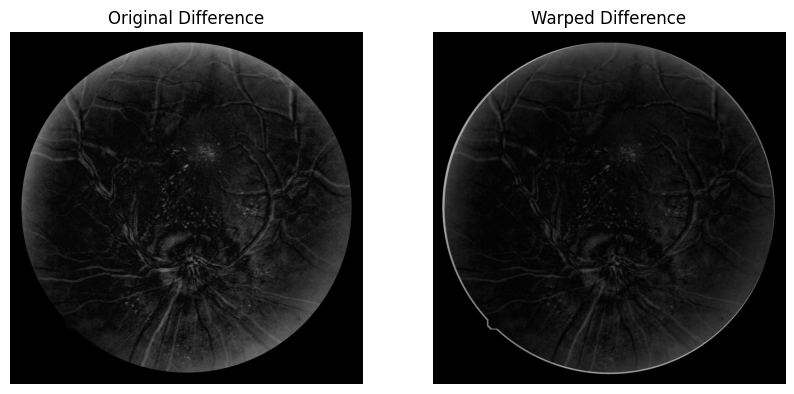

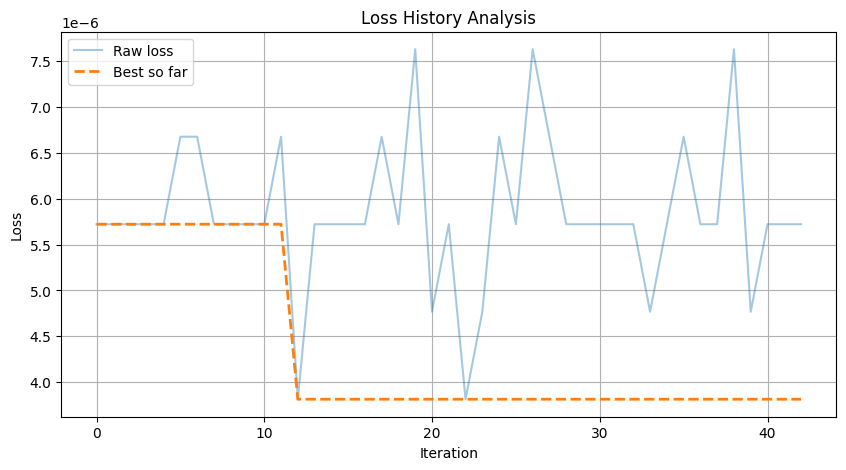

In [ ]:
transformation_matrix, registration_dict= airlab_mi_registration(fixed_image=img_ref,
                       moved_image=img_test,
                       image_dtype = torch.float32,
                       masked_images=True,
                       normalization_type = 'same', # 'same' or 'humansensitivity'
                       metric_num_bins = 64,
                       spatial_sampling=1.0,
                       metric_sigma=1.0,
                       learning_rate = 1e-4,
                       num_iterations = 5000,
                       EarlyStopping=True,
                       show_plots = True,
                       smart_storage=True,)
plot_loss_history(registration_dict['loss_history'], window=50)

In [ ]:

registration_dict.keys(), registration_dict['registrations_data'].keys()

(dict_keys(['registration_type', 'time_taken', 'registrations_data', 'normalization_type', 'loss_history', 'device']),
 odict_keys(['_phi_z', '_t_x', '_t_y', '_scale_x', '_scale_y', '_shear_y_x', '_shear_x_y']))

In [ ]:
import airlab as al 
import torch as th
from airlab.loss.pairwise import MI
from airlab.transformation.pairwise import SimilarityTransformation, AffineTransformation

start = time.time()
def airlab_es_registration(
    img_ref: Path | th.Tensor,
    img_test: Path | th.Tensor,
    num_iterations: int = 5000,
    device: Optional[th.device] = None,
    lr : float = 1e-4,
)->Dict:

        
    logs=logging.getLogger(__name__)
        
                        
    # set the used data type
    dtype = th.float32
    # set the device for the computaion to CPU
    device = th.device("cuda" if th.cuda.is_available() else "cpu")

    # In order to use a GPU uncomment the following line. The number is the device index of the used GPU
    # Here, the GPU with the index 0 is used.
    # device = th.device("cuda:0")

    # load the image data and normalize to [0, 1]
    fixed_image = al.read_image_as_tensor("./data/affine_test_image_2d_fixed.png", dtype=dtype, device=device)
    moving_image = al.read_image_as_tensor("./data/affine_test_image_2d_moving.png", dtype=dtype, device=device)

    fixed_image, moving_image = al.utils.normalize_images(fixed_image, moving_image)

    # convert intensities so that the object intensities are 1 and the background 0. This is important in order to
    # calculate the center of mass of the object
    fixed_image.image = 1 - fixed_image.image
    moving_image.image = 1 - moving_image.image

    # create pairwise registration object
    registration = al.PairwiseRegistration()

    # choose the affine transformation model
    transformation = al.transformation.pairwise.SimilarityTransformation(moving_image, opt_cm=True)
    # initialize the translation with the center of mass of the fixed image
    transformation.init_translation(fixed_image)

    registration.set_transformation(transformation)

    # choose the Mean Squared Error as image loss
    image_loss = al.loss.pairwise.MSE(fixed_image, moving_image)

    registration.set_image_loss([image_loss])

    # choose the Adam optimizer to minimize the objective
    optimizer = th.optim.Adam(transformation.parameters(), lr=0.01, amsgrad=True)

    registration.set_optimizer(optimizer)
    registration.set_number_of_iterations(1000)

    # start the registration
    registration.start()

    # set the intensities back to the original for the visualisation
    fixed_image.image = 1 - fixed_image.image
    moving_image.image = 1 - moving_image.image

    # warp the moving image with the final transformation result
    displacement = transformation.get_displacement()
    warped_image = al.transformation.utils.warp_image(moving_image, displacement)

    end = time.time()

    logs.debug("=================================================================")

    logs.info("Registration done in:", end - start, "s")
    logs.info("Result parameters:")
    transformation.print()

    # plot the results
    plt.subplot(131)
    plt.imshow(fixed_image.numpy(), cmap='gray')
    plt.title('Fixed Image')

    plt.subplot(132)
    plt.imshow(moving_image.numpy(), cmap='gray')
    plt.title('Moving Image')

    plt.subplot(133)
    plt.imshow(warped_image.numpy(), cmap='gray')
    plt.title('Warped Moving Image')

    plt.show()



In [ ]:
from PIL import Image as PImage
if TEST_FOR['airlab']:
    try:
        im_ami_drive = Path(f'{RESULT_PATH}/ImgRes/AMI_sigma3.0_nite100_bins64_lr0.0001__20260302_141349.png')
        assert PImage.open(im_ami_drive) # to visualize remove assert
    except Exception as e:
        logs.error(f"Error loading image from drive: {e}")
        

In [ ]:
if TEST_FOR['airlab']:
    import torch
    import sys
    from skimage.color import rgb2gray
    import SimpleITK as sitk
    from airlab.utils.image import Image as AirlabImage
    import airlab as al
    from airlab.registration import PairwiseRegistration

    from airlab.loss.pairwise import MI
    from airlab.transformation.utils import warp_image

    #=========== SKELETON  of AIRLAB REGISTRATION==============

    A01_test = test_images_path / 'Longitudinal_Studies' / 'A01_2.jpg'
    A01_reference = reference_images_path / 'Longitudinal_Studies' / 'A01_1.jpg'
    img_ref, img_test, test_image_name, reference_image_name = first_batch
    image_dtype= torch.float32
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    img_ref_al = AirlabImage(tensor_img_to_sitk(img_ref),image_dtype)
    img_test_al = AirlabImage(tensor_img_to_sitk(img_test), image_dtype)

    al_transformation = al.transformation.pairwise.AffineTransformation( moving_image=img_test_al, opt_cm=False)
    al_transformation.init_translation(fixed_image=img_ref_al)

    # set the similarity metric:
    ami_metric = MI(fixed_image=img_ref_al, moving_image=img_test_al, sigma=0.02, bins=32)
    MSE_metric = al.loss.pairwise.MSE(fixed_image=img_ref_al, moving_image=img_test_al)
    # set optimizer
    al_optimizer = torch.optim.Adam(al_transformation.parameters(), lr=1e-4, amsgrad=True)


    # set the registration type: 
    start_registration = False
    if start_registration:
        registration = PairwiseRegistration()
        registration.set_transformation(al_transformation)
        registration.set_optimizer(al_optimizer)
        registration.set_image_loss([ami_metric])
        registration.set_number_of_iterations(10)
        registration.start(EarlyStopping=False)




    

In [ ]:

if TEST_FOR['airlab']:
    interval = [ 0. , 0.37]
    max_val = max(interval)
    min_val = min(interval)
    background_image = torch.from_numpy((img_ref_al.numpy() > min_val ) & ( img_ref_al.numpy() < max_val)).float()
    logs.info(f'tipo: {type(background_image)}, dati all\'interno : {background_image.dtype}, device: {img_ref_al.device}')
    plt.imshow(background_image.numpy())


In [ ]:
if TEST_FOR['airlab']:
    plt.imshow(img_ref_al.numpy(), cmap='grey')
    plt.axis('off')

In [ ]:
if TEST_FOR['airlab']:
    al_transformation._compute_transformation_matrix()

In [ ]:
if  TEST_FOR['airlab']:
    # Comparison before and after registration
    warped_image_al = warp_image(img_test_al, al_transformation.get_displacement())
    difference_original = sitk.Abs(img_ref_al.itk() - img_test_al.itk())
    difference_warped = sitk.Abs(img_ref_al.itk() - warped_image_al.itk())

    difference_mean_original = sitk.GetArrayFromImage(difference_original).mean()
    difference_mean_warped = sitk.GetArrayFromImage(difference_warped).mean()
    print(f"Mean Absolute Difference before registration: {difference_mean_original}")
    print(f"Mean Absolute Difference after registration: {difference_mean_warped}")
    plt.imshow(np.abs(warped_image_al.numpy() - img_ref_al.numpy()))
    plt.axis('off')

In [ ]:
if TEST_FOR['airlab']:
    from airlab.transformation.utils import warp_image
    # invece di confrontare l'entropia prova a ricostruire l'immagine ottenuta dalla registrazione e la loss calcolata, tramite i mezzi definiti nell'articolo,
    # in base alle loss confronta i risultati e definisci le tabelle, dal metodo AMI devi ottenere un modo per calcolare la loss tra le immagini o di avere la trasformazione ottenuta dalla registrazione
    warp_image_displacement= al_transformation.get_displacement()
    warped_image= warp_image(img_test_al, warp_image_displacement)
    warped_image # verifica che sia differente dal tensore originale moving_image e appica la funzione che ci fa 
    # vedere la differenza tra le immagini
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].set_title('Test moved Image')  
    ax[0].imshow(img_ref_al.numpy())
    ax[0].axis('off')
    ax[1].set_title('Warped Image after Registration')
    ax[1].imshow(warped_image.numpy())
    ax[1].axis('off')

In [ ]:
from airlab.utils.image import Image as AirlabImage
import airlab as al
from airlab import PairwiseRegistration
from airlab.loss.pairwise import MI
from airlab.transformation.utils import warp_image

def clean_and_normalize(img:torch.Tensor
                        )-> torch.Tensor:
    '''
    clean the image from negative values and normalize it between 0 and 1
    '''
    img=torch.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    imin, imax = img.min(), img.max()
    if imax - imin < sys.float_info.epsilon:
        return torch.zeros_like(img)
    else:
        img = (img - imin) / (imax - imin)  
    return img

if TEST_FOR['airlab']:
    image_type = torch.float32

    img_ref_normalized = clean_and_normalize(img_ref)
    img_test_normalized = clean_and_normalize(img_test)

    ref_sitk = tensor_img_to_sitk(img_ref_normalized) # prova a usare i metodi di SITK
    test_sitk = tensor_img_to_sitk(img_test_normalized)

    #importazione delle immagini in formato Image per airlab
    ref_al_image = AirlabImage(ref_sitk, image_type=image_type)
    test_al_image = AirlabImage(ref_sitk, image_type=image_type) # prova con la stessa immagine

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # set the transformation type:
    al_transformation = al.transformation.pairwise.AffineTransformation( moving_image=test_al_image, opt_cm=False)
    al_transformation.init_translation(fixed_image=ref_al_image)

    # set the similarity metric:
    ami_metric = MI(fixed_image=ref_al_image, moving_image=test_al_image, bins=64, sigma=0.09)
    MSE_metric = al.loss.pairwise.MSE(fixed_image=ref_al_image, moving_image=test_al_image)
    # set optimizer
    al_optimizer = torch.optim.Adam(al_transformation.parameters(), lr=1e-2, amsgrad=True)


    # set the registration type: 
    registration = PairwiseRegistration()
    registration.set_transformation(al_transformation)
    registration.set_optimizer(al_optimizer)
    registration.set_image_loss([ami_metric])
    registration.set_number_of_iterations(20)
    registration.start(EarlyStopping=False)


In [ ]:
torch.cuda.is_available()

True

In [ ]:
   
 # Comparison before and after registration with mean absolute difference
if TEST_FOR['airlab']:
    warped_image_al = warp_image(img_test_al, al_transformation.get_displacement())
    difference_original = sitk.Abs(img_ref_al.itk() - img_test_al.itk())
    difference_warped = sitk.Abs(img_ref_al.itk() - warped_image_al.itk())

    difference_mean_original = sitk.GetArrayFromImage(difference_original).mean()
    difference_mean_warped = sitk.GetArrayFromImage(difference_warped).mean()
    print(f"Mean Absolute Difference before registration: {difference_mean_original}")
    print(f"Mean Absolute Difference after registration: {difference_mean_warped}")

In [ ]:
if TEST_FOR['airlab']:
    from airlab.transformation.utils import warp_image
    # invece di confrontare l'entropia prova a ricostruire l'immagine ottenuta dalla registrazione e la loss calcolata, tramite i mezzi definiti nell'articolo,
    # in base alle loss confronta i risultati e definisci le tabelle, dal metodo AMI devi ottenere un modo per calcolare la loss tra le immagini o di avere la trasformazione ottenuta dalla registrazione
    warp_image_displacement= al_transformation.get_displacement()
    warped_image= warp_image(test_al_image, warp_image_displacement)
    warped_image # verifica che sia differente dal tensore originale moving_image e appica la funzione che ci fa 
    # vedere la differenza tra le immagini
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].set_title('Test moved Image')  
    ax[0].imshow(img_test.squeeze().permute(1,2,0).detach().numpy())
    ax[0].axis('off')
    ax[1].set_title('Warped Image after Registration')
    ax[1].imshow(warped_image.numpy())
    ax[1].axis('off')

    # calcolo della loss e esplicita i risultati della registrazione

In [ ]:
if TEST_FOR['airlab']:
    esth= torch.randint(0, 10, (3, 4, 5), dtype=torch.float32)
    print(esth.shape)
    print(esth.mean(dim=0, keepdim=True).shape)

## NORMALIZED MUTUAL INFORMATION ELASTIX

#### Usage of itk elastix from examples

In [ ]:
import itk
import numpy as np
import matplotlib.pyplot as plt

def image_generator(x1, x2, y1, y2):
    '''
    Generate a simple synthetic image with a square in the center.
    '''
    image = np.zeros([100, 100], dtype=np.float32)
    image[y1:y2 , x1:x2] = 1.0
    image=itk.image_view_from_array(image)
    return image

def show_images(image_list):
    '''
    Show a list of images using matplotlib.
    '''
    labelled_images= ['fixed', 'moving', 'registered']
    num_images = len(image_list)
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    for i, image in enumerate(image_list):
        array_image = itk.array_view_from_image(image)

        axes[i].imshow(array_image, cmap='gray')
        axes[i].set_title(labelled_images[i])
        axes[i].axis('off')
    plt.show()

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    image_list= [image_generator(i, i+20, i+20, i+40) for i in range(10, 40, 10)]
    show_images(image_list)
    image0 =image_list[0]
    image1 =image_list[1]
    image2 =image_list[2]

In [ ]:
# creating a euler 2d transformation:

if not IN_COLAB:
    traslation = [15.0, -10.0]  # x and y translation
    transformation= itk.Euler2DTransform.New()
    transformation.SetOffset(traslation) 
    transformation.SetAngleInDegrees(15)  
    transformation.SetCenter([50.0, 50.0])  # center of rotation

    parameter_map ={
        'Direction' : ('1','0','0','1'),
        'Index' : ('0', '0'),
        'Origin' : ('0.0', '0.0'),
        'Size' : ('100', '100'),
        'Spacing' : ('1.0', '1.0'),
        'FinalBSplineInterpolationOrder' : ('0'),
    }
    transform_parameter_object= itk.ParameterObject.New()
    transform_parameter_object.AddParameterMap(parameter_map)
    transformix_filter = itk.TransformixFilter.New(image0)
    transformix_filter.SetMovingImage(image1)
    transformix_filter.SetTransformParameterObject(transform_parameter_object)
    transformix_filter.SetTransform(transformation)
    transformix_filter.Update()
    moved_image = transformix_filter.GetOutput()
    show_images([image0, moved_image])

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    rigid_parameter_object = itk.ParameterObject.New()
    rigid_parameter_map = rigid_parameter_object.GetDefaultParameterMap('rigid')
    rigid_parameter_map['FinalBSplineInterpolationOrder'] = ('0')
    rigid_parameter_object.AddParameterMap(rigid_parameter_map)

    print(rigid_parameter_object)

In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
        unconstrained_result_image, result_transform_parameters = itk.elastix_registration_method(
        image0, moved_image,
        parameter_object=rigid_parameter_object,
        log_to_console=False)
        show_images([image0, moved_image, unconstrained_result_image])

In [ ]:
if not IN_COLAB:
    type(img_ref), img_test.shape, reference_images_path, fire_images_path,reference_files[1], test_files[1]

In [ ]:
def extract_image_name(image_path: Path
                             )-> str:
    '''
    Extract the image name from the image path without extension.
    '''
    return image_path.stem

#plt.imshow(np.array(itk.array_view_from_image(fixed_image)))
def rescaling_image(img):
    '''
    Rescale the image to the range [0, 1] 
    '''
    rescaler = itk.RescaleIntensityImageFilter.New(img)
    rescaler.SetOutputMinimum(0.0)
    rescaler.SetOutputMaximum(1.0)
    rescaler.Update()
    rescaled_img = rescaler.GetOutput()
    return rescaled_img
#plt.imshow(np.array(itk.array_view_from_image(rescaling_image(fixed_image))))
def elastix_show_difference_image(fixed_image,
                                moved_image,
                                registered_image
                               )-> None:
    '''
    Show the difference images between fixed and moving, and fixed and registered images.
    '''# prima normalizza poi differenza
    fixed_normalized = rescaling_image(fixed_image)
    moved_normalized = rescaling_image(moved_image)
    registered_normalized = rescaling_image(registered_image)
    original_difference = np.array(itk.array_view_from_image(fixed_normalized) - np.array(itk.array_view_from_image(moved_normalized)))
    registered_difference = np.array(itk.array_view_from_image(fixed_normalized) - np.array(itk.array_view_from_image(registered_normalized)))
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.figsize=[100,100]
    axes[0].imshow(original_difference, cmap='gray')
    axes[0].set_title('Prior Registration', fontsize=10, loc='left')
    axes[0].axis('off')
    axes[0].set_title(f'RMSE: {np.sqrt((original_difference**2).mean()):.4f}', fontsize=10, loc='right')
    axes[1].imshow(registered_difference, cmap='gray')
    axes[1].set_title('After Registration', fontsize=10, loc='left')
    axes[1].axis('off')
    axes[1].set_title(f'RMSE: {np.sqrt((registered_difference**2).mean()):.4f}', fontsize=10, loc='right')
    fig.get_label()
    plt.savefig(imagedir_save_path / 'Difference_Elastix.png')
    plt.show()

    return None




In [ ]:

if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    import itk
    # definisci una funzione per fare questo a partire da reference_files e test_files e 
    # impostare alcuni dati, solo numerici; imposta un timer per controllare quanto tempo 
    #ci mette la registrazione
    fixed_image = itk.imread(reference_files[0], itk.F)
    moved_image = itk.imread(test_files[0], itk.F)

    transformation_parameters = itk.ParameterObject.New() # set the pparameter object
    affine_params_map = transformation_parameters.GetDefaultParameterMap('affine') # set the parameter for affine transformation
    affine_params_map['metric'] = ['NormalizedMutualInformation']
    affine_params_map['NumberOfHistogramBins'] = ['32']
    affine_params_map['NumberOfResolutions'] = ['3']
    affine_params_map['MaximumNumberOfIterations'] = ['5000']
    transformation_parameters.SetParameterMap(affine_params_map)
    final_image, registration_parameters=  itk.elastix_registration_method(
        fixed_image=fixed_image,
        moving_image=moved_image,
        parameter_object=transformation_parameters,
        log_to_console=True)
    #transform_parameter_object.SetParameterMap(affine_params_map)

    # Save results: 
    image_name = reference_files[0].stem.split('_')[0]
    itk.imwrite(final_image, str(elastix_saving_folder / f'{image_name}.nii.gz'))

    # chiama funzione





In [ ]:
if not IN_COLAB:
    elastix_show_difference_image(fixed_image=fixed_image,
                            moved_image=moved_image, 
                            registered_image=final_image)


In [ ]:

#1. get iimage from path or tensor from dataset:
def elastix_registration(reference_image_path : Path,
                        test_image_path : Path,
                        histogram_bins : int = 64,
                        num_resolutions : int = 4,
                        max_iterations : int = 5000,
                        )-> tuple:
    '''
    the registration of two images using elastix via itk 
    Parameters
    ----------
    reference_image_path : Path
        The path to the reference image.
    test_image_path : Path
        The path to the test image.
    histogram_bins : int
        Number of histogram bins for the mutual information metric.
    num_resolutions : int
        Number of pyramid's steps for the registration.
    max_iterations : int
        Maximum number of iterations for the registration.
    
    Returns
    -------
    tuple
        The registered image and the registration parameters.
    '''
    fixed_image = itk.imread(reference_image_path, itk.F)
    moved_image = itk.imread(test_image_path, itk.F)
    spatial_sampling = 0.5 # not specified in the article, but used to be coherent with other methods
    with block_time() as registration_time:
        transformation_parameters = itk.ParameterObject.New() # set the pparameter object
        affine_params_map = transformation_parameters.GetDefaultParameterMap('affine') # set the parameter for affine transformation
        affine_params_map['metric'] = ['NormalizedMutualInformation']
        affine_params_map['MetricSamplingPercentage'] = [f'{spatial_sampling}']
        affine_params_map['WritingResultImage'] = ['false'] # to avoid saving the registered image in the current folder
        affine_params_map['DefauldtPixelValue'] = ['0'] # to avoid having black borders in the registered image
        affine_params_map['NumberOfHistogramBins'] = [f'{histogram_bins}']
        affine_params_map['NumberOfResolutions'] = [f'{num_resolutions}']
        affine_params_map['MaximumNumberOfIterations'] = [f'{max_iterations}']
        transformation_parameters.SetParameterMap(affine_params_map)
    
        _, registration_parameters=  itk.elastix_registration_method(
            fixed_image=fixed_image,
            moving_image=moved_image,
            parameter_object=transformation_parameters,
            log_to_console=True)
    time_taken = registration_time[0]

    # get the trasformation matrix:
    homography_matrix = np.eye(3)
    a11, a12, a21, a22, tx, ty =  registration_parameters.GetParameterMap(0)['TransformParameters']
    homography_matrix[0, 0] = float(a11)
    homography_matrix[0, 1] = float(a12)
    homography_matrix[1, 0] = float(a21)
    homography_matrix[1, 1] = float(a22)
    homography_matrix[0, 2] = float(tx)
    homography_matrix[1, 2] = float(ty)
    return homography_matrix, registration_parameters, time_taken





In [ ]:
if TEST_FOR['SITK'] or TEST_FOR['elastix']:
    elastix_homography, registration_parameters, elastixnmi_time_taken = elastix_registration(
    reference_image_path=reference_files[0],
    test_image_path=test_files[0],
    )
    print(elastix_homography)

In [ ]:
if not IN_COLAB:
    new_dict_of_registration_parameters ={}
    for k,v in registration_parameters.GetParameterMap(0).items():
        new_dict_of_registration_parameters[k]=v
    new_dict_of_registration_parameters

In [ ]:
if not  IN_COLAB:
    registration_parameters.GetParameterMap(0)['TransformParameters']

In [ ]:
if not IN_COLAB:
    n = registration_parameters.GetNumberOfParameterMaps()
    print("Number of parameter maps:", n)

    for i in range(n):
        pmap = registration_parameters.GetParameterMap(i)
        print(f"\n--- Parameter map {i} ---")
        for k, v in pmap.items():
            print(k, ":", v)


## DRMINE OUTLINE

In [ ]:
from typing import Literal, Callable
#FIXME wrapper per le funzioni
def get_registration_matrix(ref_image : Path | torch.Tensor,
                            test_image : Path | torch.Tensor,
                            method: Literal['elastix', 'arialb'],
                            registration_method : Callable,
                            **kwargs
                            )-> np.ndarray:
    '''
    Get the registration matrix between two images using the specified method.
    Parameters
    ----------
    ref_image : Path | torch.Tensor
        The reference image, can be a path to the image or a tensor.
    test_image : Path | torch.Tensor
        The test image, can be a path to the image or a tensor.
    method : str
        The registration method to use, can be 'elastix' or 'airlab'.
    kwargs : dict
        Additional parameters for the registration method.
    
    Returns
    -------
    np.ndarray
        The registration matrix between the two images.
    '''
    
    if method == 'elastix':
        homography_matrix, _, _ = elastix_registration(
            reference_image_path=ref_image,
            test_image_path=test_image,
            **kwargs
        )
        return homography_matrix
    elif method == 'airlab':
        transformation_matrix, _ = airlab_mi_registration(
            fixed_image=ref_image,
            moved_image=test_image,
            **kwargs
        )
        return transformation_matrix.cpu().numpy()
    else:
        raise ValueError("Unsupported registration method. Choose 'elastix' or 'airlab'.")
# input - > dataloader / dataset
# get cropped pyramid
# get param list for registration
# construct of the nns
# construct the affine function for warping AffineTransform
# construct the multiresolution loss for training
# train the net to get the H, and collect results
# evaluate the training
# adapt H and get evaluation

# Evaluation methods

### NAED for image control point

In [ ]:
from typing import Literal
def naed_evaluation(image_couple_name: str,
                    affine_matrix: np.ndarray | torch.Tensor, 
                    image_normalization :  Literal['diagonal' , 'coords_norm'] = 'coords_norm',
                    control_points_path: Path = CONTROL_POINTS_FOLDER,
                    image_dimensions: tuple | Path = (2912, 2912) ,
                    )-> float:
    '''
    Evaluate the registration using Normalized Average Euclidean Distance (NAED) metric.
    Parameters
    ----------
    image_couple_name : str
        The name of the image couple to get the control points file from the list. It has to be in the format 'A01', 'P19', 'S20', etc.
    control_points_file : Path
        The path to the control points coordinates.
    affine_matrix : np.ndarray | torch.Tensor
        The affine transformation matrix get by image registration algoritm it has to be in the complete form : | A t |
                                                                                                                | 0 a |
    image_dimensions : tuple | Path
        The dimensions of the images or the path to the image to get the dimensions to normalize.
    '''
    h,w = image_dimensions
    logs=logging.getLogger(__name__)
    #1. get the control points for the image couple
    test_points_list, reference_points_list = get_coords(
        image_name=image_couple_name,
        ground_truth_path=control_points_path
    )

    test_points = np.array(test_points_list, dtype=np.float32)  # shape (N, D)  D = 2 
    reference_points = np.array(reference_points_list, dtype=np.float32)  # shape (N, D)

    assert test_points.shape == reference_points.shape , "Test and reference points must have the same shape"

    #2. control of affine matrix? for 2/3D or affine type? NOTE for the moment it has just to be in a quadratic form NxN
    if isinstance(affine_matrix, torch.Tensor):
        affine_matrix = affine_matrix.detach().cpu().numpy()
    affine_matrix = np.asarray(affine_matrix, dtype=np.float32)
    n, m = affine_matrix.shape
    if n != m:
        raise ValueError(f'The affine matrix must be square, got {n}x{m}')
    
    if n == 4:
        total_distance = np.nan # NOTE the 3D case has yet to be treated
        logs.info('the 3D case has yet to be treated')
        return total_distance
    
    elif n == 3:
        #3. for each list of coords: apply the matrix -> get the Euclidean distance
        total_distance = 0.0
        assert test_points.shape[-1] == 2, "Test points must be 2D coordinates"
        ones_column = np.ones((test_points.shape[0], 1))
        homogeneous_test_points = np.hstack((test_points, ones_column))  # shape (N, 3
        homogeneous_warped_points = np.rint(homogeneous_test_points @ affine_matrix.T).astype(np.int32)  # shape (N, 3), already interpolated, using round/nearest neighbor
        
        incongruencies = [w for w in homogeneous_warped_points[:, 2] if w == 0]
        if len(incongruencies) > 0:
            total_distance = np.nan #raise ValueError("There are some incongruencies in this transformation, some points have w=0") #FIXME return NaN o gestisci in altro modo
            return total_distance
        
        else: 
            warped_points = np.rint([[x_w/w, y_w/w] for (x_w, y_w, w) in homogeneous_warped_points]).astype(np.int32)  # shape (N, 2)
            total_distance += np.linalg.norm(warped_points - reference_points, axis=1).mean()

    #4. normalize the NAED value
    if image_normalization == 'diagonal':
        #4.1 get the NAED value using image diagonal to normalize
        ratio = np.sqrt(h**2 + w**2)
    elif image_normalization == 'coords_norm':
        #4.2 get the NAED value using the norm of the image dimensions to normalize
        ratio = h
        
    #5. return NAED value in float
    naed_value = total_distance / ratio
    
    return naed_value
    


In [ ]:
matrix_es =transformation_matrix.detach().cpu().numpy()
naed_calculated_coords = naed_evaluation(image_couple_name='A01',
                                  affine_matrix=matrix_es,
                                    image_normalization='coords_norm',
                                    image_dimensions=(2912, 2912))

naed_calculated_diagonal = naed_evaluation(image_couple_name='A01',
                                  affine_matrix=matrix_es,
                                    image_normalization='diagonal',
                                    image_dimensions=(2912, 2912))  
print(f'NAED calculated with coords norm: {naed_calculated_coords};\nNAED calculated with diagonal norm: {naed_calculated_diagonal}')

NAED calculated with coords norm: 0.021607241864041615;
NAED calculated with diagonal norm: 0.015278627244801685


# Collect results of various methods:
-time of registration

-name of image pair

-registration matrix

-evaluation of NAED




In [ ]:
from typing import Optional

def registration_named_file(data_collector: Optional[dict],
                            other_useful_data : Optional[dict],
                            extra : str = 'Reg_ES'
                            )->str:
    '''
    The easy function to collect info about registration in progress or just concluded to generate a good name for saving file

    Args:
        data_collector (Optional[Registration_Data_collector]): the collector of data where most of information has kept
        other_data (dict): other relevant information to introduce in naming file

    Returns:
        str: the name for file registration
    '''
    if data_collector:
        registration_name = data_collector.registration_name
        dimension_of_dataset = 'full' if len(data_collector.collection) == 134 else 'sample'
    else: 
        data_collector= {}
        registration_name = 'Reg_Es'
        dimension_of_dataset = 'full' if len(data_collector) == 134 else 'sample'

    file_name_for_registration= f'{registration_name.upper()}_{dimension_of_dataset}'
    for k, v in other_useful_data.items():

        file_name_for_registration += f"_{v.replace(' ', '_')}"
        
                                      
                                        
    return file_name_for_registration


import inspect

def get_param_info(func, param_name):
    sig = inspect.signature(func)
    
    if param_name not in sig.parameters:
        return None
    
    p = sig.parameters[param_name]
    
    return {
        "annotation": p.annotation,
        "kind": p.kind,
        "default": p.default
    }

print(get_param_info(registration_named_file, "extra"))


{'annotation': <class 'str'>, 'kind': <_ParameterKind.POSITIONAL_OR_KEYWORD: 1>, 'default': 'Reg_ES'}


In [38]:
import pandas as pd
from pathlib import Path
from typing import Optional
from datetime import datetime
import torch
class Registration_Data_Collector:
    '''
    A class to collect and store registration data on the entire dataset. For every specific image_pair/registration method,
    '''
    def __init__(self):
        self.collection = {}

    def add_registration_data(self,
                              image_pair_name: str, 
                              registration_data: dict, #NOTE to be fixed ? to introduce them as a (use of assert to get these information for sure?) for naed, time and matrix?
                              registration_name: str | None = None):
        '''
        Collect registration information for a specific image pair and registration method.
        '''
        
        if image_pair_name not in self.collection:
            self.collection[image_pair_name] = {}
        for key, value in registration_data.items(): #FIXME be more specific on which data to add 
            try:
                if value.device == 'cuda':
                    value = value.detach().cpu()
            except:
                pass
            self.collection[image_pair_name][key] = value # NOTE si può mettere in un finally?
        
        if registration_name:
            self.registration_name = registration_name
        else:
            self.registration_name= f'registration_data_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
        

    @property
    def get_dataframe(self) -> pd.DataFrame:
        '''
        Convert the collected registration data into a pandas DataFrame.
        '''
        df = pd.DataFrame.from_dict(self.collection, orient="index")
        df.index.name = "image_pair_name"
        return df.reset_index().set_index('image_pair_name')
    
    def save_data(self, 
                  filename: Optional[str],
                  fmt : Optional[str],
                  results_path :str | Path = RESULT_PATH ,
                  overwrite: bool = False,
                  IN_COLAB: bool = False,
                  )->Path:
        '''Saving the collected data to a file in the specified format (csv or json or excel).
        results_path as to be the directory where all esults are kept'''
        filepath = Path(results_path / 'CSVResults')
        picklepath = Path(results_path/ 'DataCollectors')
        if not filepath.exists():
            filepath.mkdir(parents=True, exist_ok=True)
        filename = filename or self.registration_name 

        # setting file format 
        fmt = (fmt or Path(filename).suffix.lstrip('.')).lower()
        avaiable_formats = ['csv', 'json', 'excel', 'xls', 'xlsx', 'pkl', 'pickle']
        if fmt not in avaiable_formats:
            fmt = 'csv'
        
        df = self.get_dataframe
        filename = Path(filename).stem
        fmt = 'xlsx' if fmt in ('excel', 'xls', 'xlsx') else fmt
        path = filepath / f'{filename}.{fmt}'


        if path.exists() and not overwrite:
            filename = f'{filename}_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
            path = filepath / f'{filename}.{fmt}'
        
        if fmt=='csv': 
            df.to_csv(path, index=True)
        elif fmt=='json':
            df.to_json(path, orient="index")
        elif fmt=='xlsx':
            df.to_excel(path)
        elif fmt in ['pkl', 'pickle']:
            path = picklepath / f'{filename}.{fmt}'
            if path.exists() and not overwrite:
                filename = f'{filename}_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
                path = picklepath / f'{filename}.{fmt}'
            if IN_COLAB:
                torch.save(
                    self,
                    f=path,
                    pickle_module=pickle,
                    pickle_protocol=pickle.HIGHEST_PROTOCOL
                )
            else:
                with open(path, 'wb') as pickle_file:
                    pickle.dump(self,
                                pickle_file,
                                pickle.HIGHEST_PROTOCOL)
        else:
            raise ValueError(f"Unsupported format: {fmt}. Supported formats are 'csv', 'json', 'excel' or 'pickle'.")
        return path

### solution for the retrieve of data from csv files

In [33]:
import pandas as pd
import numpy as np
def retrieve_data_from_csv(path: Path) -> pd.DataFrame:
    '''
    Retrieve registration data from a csv file and convert the affine matrix from string to numpy array.
    '''
    df = pd.read_csv(path, index_col='image_pair_name')
    df['affine_matrix'] = df['affine_matrix'].apply(lambda x: np.fromstring(x.replace('[', '').replace(']', ''), sep=' ').reshape(3, 3))
    return df



In [34]:
dataset.test_images[:2]

[WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Images/Test/Longitudinal_Studies/A01_2.jpg'),
 WindowsPath('c:/Users/gioco/Desktop/GITHUB_MAIN_FOLDER/ImRegODE/Main_folder/Modules/dataset/FIRE/Images/Test/Longitudinal_Studies/A02_2.jpg')]

### Define WRAPPERS for all registrations methods:

INPUTS:dataset == (reference image, test image) , parameters  x registration and preprocessing get the params from yaml/ configuration files

OUTPUTS: Data collector - type

----------------
IMPORTANT
---------------
 LEAVE OUT OF THE WRAPPERS EVERYTHING THAT IS COMMON TO ANY REGISTRATION METHODS: dataset definitions, 




In [ ]:
from typing import Callable, TypedDict, Optional, Tuple
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from itertools import islice

# ALREADY DEFINED: 
# DATASET ---> DataLoader to be inserted in the pipeline
class SampleDict(TypedDict):
    reference_sample : torch.Tensor
    test_sample : torch.Tensor
    reference_sample_path : Path
    test_sample_path : Path
    sample_name : str

PreprocessingFn = Callable[[SampleDict | Sequence, dict], SampleDict]
RegistrationFn = Callable[[SampleDict, dict], dict]


def run_registration_pipeline(dataset : Dataset,                              
                              registration_fn: RegistrationFn,
                              preprocessing_fn: Optional[PreprocessingFn] = general_preprocessing,
                              save_results: bool = True,
                              project_root : Optional[Path]=None,
                              )-> Tuple[Registration_Data_Collector, Optional[Path]]:
    '''
    It RUN a registration Pipeline to actually get the registration results to be put in the DataCollector created
    the PIPELINE: get the dataset as first input:
    DATASET ----> PREPROCESSING ---> REGISTRATION to get results

    Args:
        dataset (Dataset): the Dataset of images it get a easy access to images as path like or PIL images
        preprocessing_fn (PreprocessingFn): adjust the images as requested for the Pipeline and the experiment
        registration_fn (RegistrationFn): main focus of the work, analyze, process, calculate informations about the image pair returning a defined formatted results
            to be collected in the designated object
        save_results (bool): whether to save the registration results
        project_root (Path): the root path of the project to save results in the right folder, if used from script use Path(__file__) as start_path

    Returns:
        Registration_Data_collector: The collector of results
    '''
    # 0. PRESET ALL THE PARAMETERS OR CONSTANT FROM YAML OR MANUAL
    logs = logging.getLogger(__name__)
    path_to_result = None
    if project_root is None:
        project_root = get_root_path(start_path=Path.cwd())
    config_dict = yaml_config_setup(project_root / 'config_file.yaml')
    data_collector = Registration_Data_Collector()
    
    batch_size = config_dict['constant']['num-like']['batch_size'] 
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    dataset_iterator = iter(dataloader)
    max_sample = config_dict['constant']['num-like']['max_sample'] 
    
    #1. DEFINE THE PIPELINE
    for sample in tqdm(islice(dataset_iterator, max_sample), total=max_sample, desc="Running Registration Pipeline"):
        
        preprocessed_sample = preprocessing_fn(sample, config_dict)
        registration_results = registration_fn(preprocessed_sample)

        data_collector.add_registration_data(registration_results)
    
    #2. SAVE RESULTS
    if save_results:
        result_type = config_dict['constant']['text-like']['SAVING_FORMAT']
        results_path = project_root / Path(*config_dict['constant']['path-like']['RESULTS'])
        path_to_results = data_collector.save_data(filename='wrapper_trial', fmt=result_type, results_path=results_path) # FIXME use config_dict

    
    

    return (data_collector, path_to_results)

In [ ]:
from typing import Callable, Tuple, Union, Optional
import logging
def general_preprocessing(sample_dict: Union[SampleDict, Sequence],
                       config_dict: dict,
                       transformations : Optional[Tuple[Callable[[SampleDict, dict], SampleDict], ...]] = None,
                       )-> SampleDict:
    '''
    The point is to adapt the most of preprocessing function to be inserted in an ordinated list to use them in an ordered and methodical way during the pipeline
    For simplicity all of them must have the same input data type as for the same output data type

    ----
    IMPORTANT
    ----------
    if the sample_dict is the item from dataset.__getitem__(index) then the elements must be sorted out as:
            sample_dict = ('reference_sample', 'test_sample', 'reference_sample_path', 'test_sample_path').
    
    ----------- 
    Parameters
    ----------- 

        sample_dict (SampleDict): Starting point, constructed by the dataset 
        config_dict (dict): possibly taking by a yaml file to use the method dict_type.get('key', default) to avoid errors
        transformations (Tuple[Callable, ...]): An ordinated tuple of preprocessing functions to be applied in order, they have to have the same input and output type to be used in this way.

    Returns
    ---------

        dict: the dict has to be almost on the same type of SampleDict to better flexibility during pipeline
    '''
    preprocessed_sample = sample_dict
    logs=logging.getLogger(__name__)
    if isinstance(sample_dict, Sequence) and not isinstance(sample_dict, dict):
        logs.info('since no trasformation required and the data input is the output of a dataset, the transformation will consist in sorting elements')
        test_image, reference_image, test_path, reference_path = sample_dict
        preprocessed_sample = {
            'reference_sample': reference_image,
            'test_sample': test_image,
            'reference_sample_path': Path(reference_path[0]),
            'test_sample_path': Path(test_path[0]),
            'sample_name': Path(reference_path[0]).stem.split('_')[0],
        }
    if transformations:
        for transformation in transformations:
            preprocessed_sample = transformation(preprocessed_sample, config_dict)
    
    return preprocessed_sample

def sitk_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using SimpleITK. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.
    For this experiment: 
    MMI-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    JHMI-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    MSE-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    NCC-sitk: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[outTx{Any}, sitk.ImageRegistrationMethod, float]
    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.

    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''

    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample

def airlab_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using Airlab. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.
    AMI: INPUT - np.ndarray | torch.Tensor | Path, OUTPUT - tuple[torch.Tensor, dict]
    in the middle from input to 
    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.

    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''

    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample

def drmine_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using DeepReg. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.

    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.
    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''
    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample

def elastix_preprocessing(sample_dict : SampleDict, 
                       config_dict: dict
                       )-> dict:
    '''
    A preprocessing function to adjust the images for the registration pipeline using Elastix. It takes a sample dictionary and a configuration dictionary as input and returns a preprocessed sample dictionary.

    Args:
        sample_dict (SampleDict): A dictionary containing the reference and test samples, their paths, and the sample name.
        config_dict (dict): A dictionary containing configuration parameters for preprocessing.
    Returns:
        SampleDict: A dictionary containing the preprocessed reference and test samples.
    '''
    preprocessed_sample = sample_dict.copy()
    return preprocessed_sample


NameError: name 'SampleDict' is not defined

In [100]:
image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
dataloader_es =DataLoader(image_dataset, batch_size=1, shuffle=False)
dataset_iterator = iter(dataloader_es)
sample = next(dataset_iterator)
#image_dataset.test_images[0].stem.split('_')[0]
for i , sample in enumerate(dataloader_es):
    print(sample[0].shape, type(sample[1]))
    if i == 1:
        break

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'pathlib.WindowsPath'>

IMPORTANTE, USA LE CELLE SOTTO COME RIFERIMENTO, DOPO LE DOVRAI COMUNQUE CANCELLARE E NON USARE PIU' 

### registration for all CPU-friendly methods


In [ ]:
from tqdm.notebook import tqdm
if not IN_COLAB:
    fire_dataset_path= FIRE_DATASET_PATH
    transform_tensor = transforms.Compose([transforms.ToTensor()])
    image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
    data_collector = Registration_Data_Collector()
    # Creare il dataloader

    image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
    dataset_iterator = iter(image_dataloader)
    whole_dataset = len(image_dataset)
    little_sample = 2
    for i in tqdm(range(whole_dataset)):
        test_image, reference_image, test_image_path, reference_image_path = next(dataset_iterator)
        path_to_test_image = image_dataset.test_images[i]
        path_to_reference_image = image_dataset.reference_images[i]
        test_image_name, reference_image_name = test_image_name.stem[0], reference_image_name.stem[0]
        image_name_couple = test_image_name.split('_')[0]

        affine_matrix, registration_parameters_dict, time_taken = elastix_registration(reference_image_path=path_to_reference_image, 
                                                                test_image_path=path_to_test_image)
        
        naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='diagonal')
        naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='coords_norm')
        
        registration_dict ={k:v for k,v in registration_parameters_dict.GetParameterMap(0).items()}
        # specific for AMI
        registration_dict['naed_diagonal'] = naed_diagonal
        registration_dict['naed_coords'] = naed_norm_coord
        registration_dict['affine_matrix'] = affine_matrix
        registration_dict['time_taken'] = time_taken

        data_collector.add_registration_data(image_pair_name=image_name_couple,
                                            registration_data=registration_dict, #specific for elastix
                                            registration_name='Elastix_NMI')

        #   print(f"Processing image pair: {image_name_couple}, test image: {test_image_name}: whose path is:   {path_to_test_image},\nreference image: {reference_image_name}, whose path is: {path_to_reference_image}")
    path_to_data=data_collector.save_data(filename='Elastix_NMI_DRMINE_results', fmt='csv', overwrite=False)

In [ ]:
if not IN_COLAB:
    retrieved_mmi = retrieve_data_from_csv(path_to_data)
    assert type(retrieved_mmi['affine_matrix']['A01']) == np.ndarray, "The affine matrix is not a numpy array"

In [ ]:
import pickle
if not IN_COLAB:
    collector_name = f'{data_collector.registration_name}_data_collector.pkl'
    collector_path = Path(RESULT_PATH / 'DataCollectors' / collector_name)
    collector_path.parent.mkdir(parents=True, exist_ok=True)
    if collector_path.exists():
        collector_name = f'{data_collector.registration_name}_data_collector_{datetime.now().strftime("%Y%m%d_%H%M%S")}.pkl'
        collector_path = Path(RESULT_PATH / 'DataCollectors' / collector_name)

    with open(collector_path, 'wb') as f:
        pickle.dump(data_collector, f)
    #data_collector

### Airlab Registration, to be adjusted based on cloud computing and GPU 

In [ ]:
from tqdm.notebook import tqdm
if TEST_FOR['airlab']:
    fire_dataset_path= FIRE_DATASET_PATH
    transform_tensor = transforms.Compose([transforms.ToTensor()])
    image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
    data_collector = Registration_Data_Collector()
    # Creare il dataloader

    image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
    dataset_iterator = iter(image_dataloader)
    whole_dataset = len(image_dataset)
    little_sample = 2
    for i in tqdm(range(whole_dataset)):
        test_image, reference_image, test_image_name, reference_image_name = next(dataset_iterator)
        #path_to_test_image = image_dataset.test_images[i]
        #path_to_reference_image = image_dataset.reference_images[i]
        test_image_name, reference_image_name = test_image_name[0], reference_image_name[0]
        image_name_couple = test_image_name.split('_')[0]
        #test_image_cropped, reference_image_cropped = crop_images(moving_image=test_image, fixed_image=reference_image, show_images=False)
        affine_matrix, registration_dict = airlab_mi_registration(fixed_image=reference_image, 
                                                                moved_image=test_image,
                                                                masked_images=True,
                                                                learning_rate=1e-4,
                                                                metric_num_bins=64,
                                                                metric_sigma=1.0,
                                                                spatial_sampling=0.2,
                                                                normalization_type='same',
                                                                EarlyStopping=True,
                                                                num_iterations=5000,
                                                                smart_storage=True,)
        
        naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='diagonal')
        naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='coords_norm')
        # specific for AMI
        registration_dict['naed_diagonal'] = naed_diagonal
        registration_dict['naed_coords'] = naed_norm_coord
        registration_dict['affine_matrix'] = affine_matrix.detach().cpu().numpy()

        data_collector.add_registration_data(image_pair_name=image_name_couple,
                                            registration_data=registration_dict,
                                            registration_name='AirLab_MI')

        #   print(f"Processing image pair: {image_name_couple}, test image: {test_image_name}: whose path is:   {path_to_test_image},\nreference image: {reference_image_name}, whose path is: {path_to_reference_image}")
    path_to_data=data_collector.save_data(filename='AirLab_MI_full_64bins_min_delta1e-7_results', fmt='csv', overwrite=False)
    pickle_obj = data_collector.save_data(filename='AirLab_MI_full_64bins_min_delta1e-7_results', fmt='pkl', overwrite=False)

### Assesting the Result information:
as dimension for each feature

In [ ]:
registration_dict['affine_matrix'],registration_dict['registrations_data']

In [ ]:
import pickle
import sys
from pathlib import Path
from typing import Union, OrderedDict
def data_size_of_this(
        obj : Union[Path, Registration_Data_Collector],
        restricted_info : int = 5,
        mean_info : bool = False,
        )->None:
    '''
    the function get the object and return the dimension of the ensamble and parts of it

    Args:
        obj (Union[Path, Registration_Data_Collector]): the path where the object is saved or the Data collector itself
        restricted_info (int): it get a little samples of informations stored in the collector
        mean_info: it get the mean of information stored across the collector YET TO BE IMPLEMENTED

    
    Return:
        None
    '''
    if isinstance(obj, Path):
        if not obj.exists():
            raise FileNotFoundError('error during loading, the file doesn\'t exists')
        else:
            with open(obj, "rb") as f:
                try:
                    collector = pickle.load(f)
                except RuntimeError:
                    print('some error occured, try to get using torch.load')
                    try:
                        collector=torch.load(f,
                                pickle_module = pickle,
                                weights_only = False,
                                map_location=torch.device('cpu'))
                    except RuntimeError:
                        print('impossible to load the file control the type of file to be loaded, it has to be compatible with Registration_Data_Collector')
    
    else:
        collector = obj
    
    print('Num of  Sample: ', len(collector.collection))
    max_data_to_see = min(restricted_info, len(collector.collection))
    for image_pair in list(collector.collection.keys())[:max_data_to_see]:
        data = collector.collection[image_pair]
        print(f"Features of {image_pair}: {list(data.keys())}")
            
        for k, v in data.items():
            try:
                size_kb = sys.getsizeof(v) / 1024 
                if size_kb :
                    print(f"{k:24} → ~{size_kb:.2f} KB   (tipo: {type(v).__name__})")
            except:
                print(f"{k:24} → [errore nel sizeof]")

    return None



### DRMINE REGISTRATION

In [ ]:
fire_dataset_path= FIRE_DATASET_PATH
transform_tensor = transforms.Compose([transforms.ToTensor()])
image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
data_collector = Registration_Data_Collector()
# Creare il dataloader
cropped= False
image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
dataset_iterator = iter(image_dataloader)
whole_dataset = len(image_dataset)
little_sample = 2
learning_rate_set= {'v1': 1.e-5, 'vL': 1.e-3, 'mi': 1.e-2}
test_image, reference_image, test_image_name, reference_image_name = next(dataset_iterator)
test_image.shape

In [ ]:
from tqdm.notebook import tqdm
if TEST_FOR['DRMINE']:
    fire_dataset_path= FIRE_DATASET_PATH
    transform_tensor = transforms.Compose([transforms.ToTensor()])
    image_dataset = SimpleImRegDataSet(dataset_folder_path=FIRE_DATASET_PATH, reference_folder_name='Reference', test_folder_name='Test', transforms=transform_tensor)
    data_collector = Registration_Data_Collector()
    nChannel = image_dataset.get_nChannel()
    # Creare il dataloader
    cropped= False
    image_dataloader = DataLoader(image_dataset, batch_size=1, shuffle=False)
    dataset_iterator = iter(image_dataloader)
    whole_dataset = len(image_dataset)
    little_sample = 2
    learning_rate_set= {'v1': 1.e-5, 'vL': 1.e-3, 'mi': 1.e-2}
    for i in tqdm(range(little_sample)):
        test_image, reference_image, test_image_name, reference_image_name = next(dataset_iterator)
        #path_to_test_image = image_dataset.test_images[i]
        #path_to_reference_image = image_dataset.reference_images[i]
        test_image_name, reference_image_name = test_image_name[0], reference_image_name[0]
        image_name_couple = test_image_name.split('_')[0]
        if cropped:
            test_image, reference_image = crop_images(moving_image=test_image, fixed_image=reference_image, show_images=False) #FIXME modifica la funzione introducendo come parametro la percentuale di immagine da restituire/ il punto di coordinate (x0, y0) dell'immagine, tale da avere in seguito il tx,ty
        reference_pyramid, test_pyramid, nChannel = coupled_gaussian_pyramid(fixed_image=reference_image, moving_image=test_image)
        homography_matrix = HomographyNet()
        mine_calculation = MINE(nChannel=nChannel)
        registration_dict = drmine_registration_loop(
            homography_net=homography_matrix,
            mi_net= mine_calculation,
            pyramid_ref=reference_pyramid,
            pyramid_test=test_pyramid,
            nChannel=nChannel,
            iterations=5000,
            lr= learning_rate_set,
        )
        affine_matrix = unnormalize_matrix(H=registration_dict['affine_matrix'](0), image_shape=ORIGINAL_SHAPE)
        if cropped:
            tx=ty=-int(LOWEDGE_BOX*ORIGINAL_SHAPE[0]) # NOTE crea la funzione get_original_matrix
            affine_matrix = decrop_matrix(H=affine_matrix, offset_x0=tx, offset_y0=ty)

        naed_diagonal = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='diagonal')
        naed_norm_coord = naed_evaluation(image_couple_name=image_name_couple,
                                    affine_matrix=affine_matrix,
                                    image_normalization='coords_norm')
        # specific for AMI
        registration_dict['naed_diagonal'] = naed_diagonal
        registration_dict['naed_coords'] = naed_norm_coord
        registration_dict['affine_matrix'] = affine_matrix.detach().cpu().numpy()

        data_collector.add_registration_data(image_pair_name=image_name_couple,
                                            registration_data=registration_dict,
                                            registration_name='DRMINE')

        #   print(f"Processing image pair: {image_name_couple}, test image: {test_image_name}: whose path is:   {path_to_test_image},\nreference image: {reference_image_name}, whose path is: {path_to_reference_image}")
    registration_name= registration_named_file(data_collector=data_collector,other_useful_data={'dimension': '_not_cropped'})
    path_to_data=data_collector.save_data(filename=registration_name, fmt='csv', overwrite=False)
    pickle_obj = data_collector.save_data(filename=registration_name, fmt='pkl', overwrite=False)

  0%|          | 0/2 [00:00<?, ?it/s]

DRMINE registration:   0%|          | 0/5000 [00:00<?, ?it/s]

DRMINE registration:   0%|          | 0/5000 [00:00<?, ?it/s]

TypeError: registration_named_file() missing 1 required positional argument: 'other_useful_data'

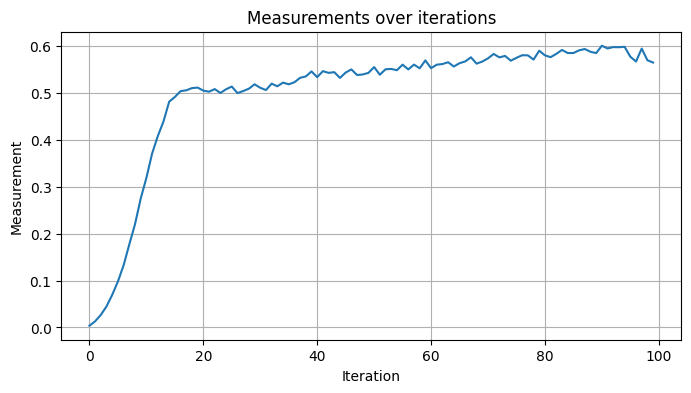

In [ ]:
loss_a01= data_collector.collection['A01']['loss_history']

import matplotlib.pyplot as plt

def plot_measurements(measures, title='Measurements over iterations'):
    """
    Simple plot for measurements evolving over time/iterations.

    Args:
        measures (list | tuple): sequence of measured values
        title (str): plot title
    """

    iterations = range(len(measures))

    plt.figure(figsize=(8, 4))
    plt.plot(iterations, measures)

    plt.xlabel('Iteration')
    plt.ylabel('Measurement')
    plt.title(title)

    plt.grid(True)

    plt.show()

plot_measurements(loss_a01[:100])

## Scacchiera per informazione minima

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Parametri principali
# -----------------------
N = 1000           # dimensione array (NxN)
T = 200            # periodo spaziale (px) delle celle
A = 0.5            # ampiezza base (come nel tuo modello)
y_offset = 0.5     # offset per mappare in [0,1] via formula finale
gamma = 10.0       # "squareness": >5 inizia a sembrare una quadra, aumenta per bordi più netti

# -----------------------
# Smorzamento: K_smorz(x) = 100 * exp(-k*x)
# vincolo: K(900) ≈ 0.5  => k = ln(200)/900  (invariato)
# -----------------------
k_min = np.log(100.0) / 600.0

x = np.arange(N)
k_exp= np.log(100.0*x)/800.0*N

K_exp = np.clip(50.0 * np.exp(-k_min*x), k_min, 100)  # NON modificato
K_lin = 1.0 - 0.5*(x)/N
# Traduzione in CONTRASTO per restare in [-1,1] senza toccare K:
# m(x) = clip(A * K(x), 0, 1)
mx = np.clip(A * K_exp, 0.0, 1.0)
my = mx.copy()  # simmetria

# -----------------------
# Onde "quasi quadre" lungo X e Y (periodo T)
# -----------------------
phase_x = 2.0 * np.pi * x / T
sqx = np.tanh(gamma * np.sin(phase_x))   # [-1, 1]
sqy = sqx.copy()                         # simmetria

# Applica lo smorzamento come CONTRASTO (non cambia K)
Sx = mx * sqx            # in [-mx, mx]
Sy = my * sqy            # in [-my, my]

# -----------------------
# Combinazione a scacchiera (prodotto, non media!)
# V in [0,1]; se mx,my -> 0, V -> 0.5 (grigio)
# -----------------------
V = 0.5 * (1.0 - np.outer(Sy, Sx))  # Sy[:,None] * Sx[None,:]

# -----------------------
# Visualizzazione
# -----------------------
plt.figure(figsize=(6,6))
plt.imshow(V, cmap='gray', vmin=0.0, vmax=1.0)
plt.title('Scacchiera: sinusoide → quasi-quadra (γ), smorzamento invariato K(x)')
plt.axis('off')
plt.show()



# INSPECTING DRMINE'S NN 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from skimage.filters import gaussian
from skimage.filters import threshold_otsu
from skimage.filters import sobel
from skimage.color import rgb2gray
from torch.autograd import Function
import cv2 
import numpy as np
from sklearn.preprocessing import MinMaxScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

In [ ]:
class HomographyNet(nn.Module):
    def __init__(self):
        super(HomographyNet, self).__init__()
        # affine transform basis matrices

        self.B = torch.zeros(6,3,3).to(device)
        self.B[0,0,2] = 1.0
        self.B[1,1,2] = 1.0
        self.B[2,0,1] = 1.0 
        self.B[3,1,0] = 1.0 
        self.B[4,0,0], self.B[4,1,1] = 1.0, -1.0
        self.B[5,1,1], self.B[5,2,2] = -1.0, 1.0

        #inizializzatione  parametri
        self.v1 = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)
        self.vL = torch.nn.Parameter(torch.zeros(6,1,1).to(device), requires_grad=True)

    def forward(self, s):
        C = torch.sum(self.B*self.vL,0)
        if s==0: # caso in cui ci si trovi nel primo livello
            C += torch.sum(self.B*self.v1,0)
        A = torch.eye(3).to(device)
        H = A
        for i in torch.arange(1,10):
            A = torch.mm(A/i,C)
            H = H + A
        return H
Homography_net = HomographyNet()

In [ ]:
n_neurons = 100
class MINE(nn.Module): #https://arxiv.org/abs/1801.04062
    def __init__(self, nChannel: int):
        super(MINE, self).__init__()
        self.nChannel = nChannel
        self.fc1 = nn.Linear(2*self.nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient
        

    def forward(self, x, ind):
        x = x.view(x.size()[0]*x.size()[1],x.size()[2])
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))]
            z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:self.nChannel],x[ind_perm,self.nChannel:2*self.nChannel]),1))))))
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize, z1, z2

In [ ]:
import cv2
def images_registration(pyramid_fixed: tuple[np.ndarray],
                        pyramid_moving: tuple[np.ndarray],
                        L: int =6,
                        sampling: float = 0.1,
                        nChannel : int = 3,
                        ) -> tuple[list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor], list[torch.Tensor],list[torch.Tensor], list[int], list[int]]:
  '''
  it registers the images calculating the random index for the homography to compare the registration and optimize the corresponding value xy_
  it also prepare the pyramidal images permuting the index position as (H,W,C) -> (C, H, W)

  Parameters
  ------------
  pyramid_fixed : tuple[numpy.ndarray]
    the pyramid of multiresolution from the fixed image
  pyramid_moving : tuple[numpy.ndarray]
    the pyramid of multiresolution from the moving image
  L : int
    the coarsest resolution level
  sampling : float
    the percentage of sampling to be used in homography optimization
  seed : int
    since the sampling is random the seed is useful for reproducibility

  Returns
  -------
  I_lst: list[torch.Tensor]
    the image pyramid of the fixed image listed as torch tensor of normalized value as np.float32
  J_lst: list[torch.Tensor]
    the image pyramid of the moving image listed as torch tensor of normalized value as np.float32
  x_ : list[torch.Tensor]
   the x coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  y_ : list[torch.Tensor]
    the y coordinates of fixed as torch tensor of normalized value as np.float64 for homography mapping
  xy_ : list[torch.Tensor]
    the coordinates for the homography mapping
  ind_ : list[torch.Tensor]
    the random index for the homography optimization
  h_ : list[int]
    the heights of images in pyramid, necessary due downsampling
  w_ :  list[int]
    the widths of images in pyramid, necessary due downsampling
  '''
  if sampling > 1.0:
    raise ValueError("sampling must be between 0 and 1")


  I_lst,J_lst,h_lst,w_lst,xy_lst,ind_lst=[],[],[],[],[],[]
  pyramid_I = pyramid_fixed
  pyramid_J = pyramid_moving

  for s in range(L):
    I_ = torch.tensor(cv2.normalize(pyramid_I[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device)   # -------param pyramid_i , pyramif_j
    J_ = torch.tensor(cv2.normalize(pyramid_J[s].astype(np.float32), None, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F)).to(device) # normalization for normalized coordinates

    if nChannel>1:
        I_lst.append(I_.permute(2,0,1)) # permute (H,W, C) -> (C, H, W)
        J_lst.append(J_.permute(2,0,1))
        h_, w_ = I_lst[s].shape[1], I_lst[s].shape[2]
        ind_ = torch.randperm(int(h_*w_*sampling)) # rand perm
        ind_lst.append(ind_)
    else:
        I_lst.append(I_)
        J_lst.append(J_)
        h_, w_ = I_lst[s].shape[0], I_lst[s].shape[1]
        ind_ = torch.randperm(int(h_*w_*sampling))
        ind_lst.append(ind_)
    h_lst.append(h_)
    w_lst.append(w_)

    y_, x_ = torch.meshgrid([torch.arange(0,h_).float().to(device), torch.arange(0,w_).float().to(device)], indexing='ij')
    y_, x_ = 2.0*y_/(h_-1) - 1.0, 2.0*x_/(w_-1) - 1.0 # normalization -1.0 ->  1.0
    xy_ = torch.stack([x_,y_],2)
    xy_lst.append(xy_)
  return (I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst)
I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)


#### reproduce the net work for a single image resolution

In [ ]:
I5_norm = normalize(I_lst[5])
J5_norm = normalize(J_lst[5])

y5 = y_[5]
xy5 = xy_lst[5]
ind5 = ind_lst[5]
h5 = h_lst[5]
w5 = w_lst[5]

x5, y5 = torch.meshgrid([torch.arange(0,h5).float(), torch.arange(0,w5).float()], indexing='ij')
xy5 = torch.stack([x5,y5],2)

x_coords = xy5[..., 0].flatten()
y_coords = xy5[..., 1].flatten()
diff5 = (I5_norm - J5_norm)
diff5_norm = normalize(diff5)
plt.imshow(diff5_norm.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.1)



In [ ]:
xy5[:10,:10,:].numel() #NOTE get the number of elements in the tensor

In [ ]:

n_neurons = N_NEURONS
class MINE_INSIDE(nn.Module): # unravel the functioning of the net
    def __init__(self, nChannel: int):
        super(MINE_INSIDE, self).__init__()
        self.fc1 = nn.Linear(2*nChannel, n_neurons)
        self.fc2 = nn.Linear(n_neurons, n_neurons)
        self.fc3 = nn.Linear(n_neurons, 1)
        self.bsize = 1 # 1 may be sufficient

    def forward(self, y, ind):
        x = y.view(y.size()[0]*y.size()[1],y.size()[2]) #flatten the tensor to use the rand perm and get random index
        MI_lb=0.0
        for i in range(self.bsize):
            ind_perm = ind[torch.randperm(len(ind))] # perchè non provare a farlo qua dentro usando torch.randperm(int(len(x[0]*sampling)))
            z1_first = F.relu(self.fc1(x[ind,:]))
            z2_first = self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))
            z1_second = F.relu(self.fc2(z1_first)) 
            z2_second = self.fc2(z2_first)
            z1 = self.fc3(z1_second) 
            z2 = self.fc3(z2_second)
            #z1 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(x[ind,:])))))
            #z2 = self.fc3(F.relu(self.fc2(F.relu(self.fc1(torch.cat((x[ind,0:nChannel],x[ind_perm,nChannel:2*nChannel]),1))))))
            logs.info(f'''x[ind,0:nChannel] shape : {x[ind,0:nChannel].shape},
                x[ind_perm,nChannel:2*nChannel]shape : {x[ind_perm,nChannel:2*nChannel].shape},
                the input_shape is : {x[ind,:].shape},
                after the first layer the output shape is : {z2_first.shape},
                after the second layer the output shape is : {z1_second.shape},
                the third layer shape : {z2.shape}.
                The original tensor is x: {y.shape}, after the forward pass the shae change into: {x.shape}
                ''')
            MI_lb += torch.mean(z1) - torch.log(torch.mean(torch.exp(z2)))

        return MI_lb/self.bsize


In [ ]:
xy5 = xy5.to(device)

In [ ]:
if TEST_FOR['DRMINE']:
    homography_net = HomographyNet()

    Jw5 = AffineTransform(J_lst[5].unsqueeze(0), homography_net(5), xy5[:,:, 0], xy5[:,:, 1]).squeeze()
    x =torch.cat([I_lst[5], Jw5], 0).permute(1,2,0)
    ind =ind5
    mine_net = MINE_INSIDE(nChannel=3)
    mi = mine_net(x, ind)
    x_new = x.view(x.size()[0]*x.size()[1],x.size()[2])
    x_new.shape

In [ ]:
import torchinfo
if TEST_FOR['DRMINE']:
    minet = MINE(nChannel=3)
    s=3
    I_lst,J_lst,x_,y_,xy_lst,ind_lst,h_lst,w_lst = images_registration(pyramid_fixed=pyramid_ref, pyramid_moving=pyramid_mov, nChannel=nChannel)
    Jws = AffineTransform(J_lst[s].unsqueeze(0), homography_net(s), xy_lst[s][:,:, 0], xy_lst[s][:,:, 1]).squeeze()
    x =torch.cat([I_lst[s], Jws], 0).permute(1,2,0)
    ind =ind_lst[s]
    S_summary = torchinfo.summary(minet, input_data=(x, ind))
    S_summary


In [ ]:

# # the correspondence between the coordinates' values and the image
import matplotlib.pyplot as plt
import numpy as np

I3 = normalize(I_lst[2])
J3 = normalize(J_lst[2])

y3 = y_[3]
xy3 = xy_lst[2].detach().cpu().numpy()
ind3 = ind_lst[2]
h3 = h_lst[2]
w3 = w_lst[2]
x3, y3 = torch.meshgrid([torch.arange(0,h3).float(), torch.arange(0,w3).float()], indexing='ij')
xy3 = torch.stack([x3,y3],2)

x_coords = xy3[..., 0].flatten()
y_coords = xy3[..., 1].flatten()
diff3 = (I3 - J3)
diff3_norm = normalize(diff3)
plt.imshow(I3.permute(1,2,0).detach().cpu().numpy())
plt.scatter(x_coords, y_coords, c='black', s=0.001)
x_coords


In [ ]:
# rearrange the loss funciton parameter to take inn two objects, the image of the dataset and the predicted through the MINE net 
# per una coppia di immagini :
# train -> loss
# omografia -> loss ...

In [ ]:
h = 4
w = h
image = torch.Tensor(np.random.randn(h, w, 3))

index = torch.randperm(int(h*w))


for i in range(len(ind_lst)):
    print(f'the {i}-th element has {len(ind_lst[i])} elements')

# DA FARE : RIFORMULA LE LOSS CONSIDERANDOLE COME DELLE NETWORK IN MODO CHE I PESI DELLE RETI VENGANO AGGIORNATI A OGNI ROUND

#### Da FARE : trovare il best lr per i parametri di mine_net e homography_net, 

In [ ]:
# considera la possibilità di usare il livello n-1 più preciso dove n è quello più nitido disponibile come base per la piramide
# in base al criterio di nyquist non possiamo considerare il livello n per la registrazione, per poi usarlo per calcolare l'errore,
# avrebbe più senso usare fino al precedente livello sfocato per i parametri della registrazione e infine usare quello più nitido possibile per calcolare l'errore

#### FATTO : creare un oggetto risultati in cui sono inclusi per ogni step un oggetto Collect_Results
1. la lista delle matrici omografiche PER OGNI LIVELLO
2. la lista delle loss PER OGNI LIVELLO ( in base al valore della loss per la valutazione? o la mi_loss)
3. il learning rate per ottenere tale oggetto ( da creare e salvare prima dello step dell'optimizer e dello scheduler)
4. l'alternativa al punto 2.

In [ ]:
import pandas as pd
def filter_keys(d,
                excluded_keys: list[str]
                ) -> dict:
    '''
    filter the dictionary to exclude the keys in excluded_keys
    Parameters
    ----------
    d : dict
        the dictionary to filter
    excluded_keys : list[str]
        the keys to exclude from the dictionary
    Returns
    -------
    dict
        the filtered dictionary, the original w/o the excluded keys
    '''
    if isinstance(d, dict):
        return {k: filter_keys(v,excluded_keys) for k, v in d.items() if k not in excluded_keys}
    return d

class  Collect_Results(): # ? or do a dataframe?
    def __init__(self, image_pair: str):
        self.name = image_pair
        self.images_results = {}
        self.images_results[f'{self.name}'] = {}

    def add_data(self, 
                iteration: int,
                loss: list[float] = [], 
                mi_loss: list[float] = [],
                homography_matrix: torch.Tensor | list[torch.Tensor] = None,
                lr: float = np.nan,
                ): 
        '''
        add data to the dictionary:
        Parameters
        ----------
        iteration : int
            the iteration of the training

        loss : list[float], optional
            the loss of the training, by default []

        mi_loss : list[float], optional
            the mutual information loss of the training, by default []

        homography_matrix : torch.Tensor | list[torch.Tensor], optional
            the homography matrix of the training, by default []

        lr : float, optional
            the learning rate of the training, by default np.NaN

        '''
        self.images_results[f'{self.name}'][f'iteration - {iteration}'] = {}
        if not loss:
            loss = np.nan
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['loss'] = loss
        if not mi_loss:
            mi_loss = np.nan
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['MI'] = mi_loss
        if homography_matrix == []:
            pass
        else:
            self.images_results[f'{self.name}'][f'iteration - {iteration}']['homography_matrix'] = homography_matrix
        self.images_results[f'{self.name}'][f'iteration - {iteration}']['lr'] = lr

    def get_data(self, 
                type : str,
                datatype: str = ''
                )-> list | pd.DataFrame:
        '''
        get the data from dictionary in a certain format
        Parameters
        ----------
        type : str
            the type of data to get from the dictionary: 
                'list' to get a specified datatype in list format, #NOTE it works also for the homomatrices
                'df' to get the dollected results in a dataframe format
        
        datatype : str
            the datatype to get from the dictionary:
                'loss' to get the loss of the training
                'mi' to get the mutual information loss of the training
                'homography_matrix' to get the homography matrix of the training
                'lr' to get the learning rate of the training
        '''
        if not self.images_results[f'{self.name}'].keys(): # in case the dictionary is empty
            raise ValueError(f'No data available for {self.name}')
        avaiable_data = [x for x in self.images_results[f'{self.name}'][f'iteration - 0'].keys()]
        if type == 'list': # to retrieve a specific datatype
            if not datatype in avaiable_data: # if the requested datatype is not in the dictionary keys
                raise ValueError(f'Invalid datatype {datatype} for {self.name},\nselect from {avaiable_data}')
            else:
                data = [] 
                for iteration in self.images_results[f'{self.name}'].keys():
                    data.append(self.images_results[f'{self.name}'][iteration][datatype])
                return data
        elif type == 'df': # to retrieve all the data in a dataframe format
            df_wo_homomatrices = filter_keys(self.images_results[f'{self.name}'], excluded_keys=['homography_matrix'])
            return pd.DataFrame(data=df_wo_homomatrices).T
        
    
    #     restiruisci un df o una lista dei dati per ottenere una più facile visualizzazione
    

    

In [ ]:
import numpy as np

# Definire la dimensione dei tensori
tensor_shape = (2, 2)

# Creare una lista di tensori
tensor_list = []

for i in range(5):  # Creare 5 tensori
    tensor = np.random.rand(*tensor_shape)  # Tensore con valori casuali
    tensor_list.append(tensor)

tensor_list

In [ ]:
import pandas as pd
a01_res = Collect_Results('A01')
a_void = Collect_Results('A_void')
for i in range(5):
    a01_res.add_data(iteration=i, lr=0.001*(i+1), loss=[0.1*(i+1)], homography_matrix=torch.Tensor(tensor_list[i]))


In [ ]:

dataframe_a01 = a01_res.get_data(type='df')
dataframe_a01

In [ ]:
homo_list = a01_res.get_data(type='list', datatype='homography_matrix')
homo_list

In [ ]:
diz, diz_info, diz_iteration = {}, {}, {}
for i in range(3):
    diz_info[f'iteration{i}'] = {}
    diz_info[f'iteration{i}']['loss']= 1.34 + i
    diz_info[f'iteration{i}']['mi_loss'] = 0.23 + i
    diz_info[f'iteration{i}']['homography_matrix'] = torch.eye(i+1)
    diz_info[f'iteration{i}']['lr'] = 0.001 * (i + 1) 


diz['A01'] = diz_info
image_pair = 'A01'
iteration_of_interest = 1
data_to_retrieve ='lr'
diz[image_pair][f'iteration{iteration_of_interest}'][data_to_retrieve]

successivamente:
1. provare a calcolare la mi con altri metodi di approssimazione numerica o probabilistici
2. calcolare l'approssimazione con il runge-kutta e considerare le immagini come flussi dinamici


#### DA FARE: plottare i risultati o riprendere il modo per analizzare la rete ottenuta durante l'allenamento

In [ ]:
def plot_graph(values: list[float],
              title: str = 'Loss',
              xlabel: str = 'Iteration',
              ylabel: str = 'Loss',
              save_path: Path = None ,
              show: bool = True,
              ) -> None:
    '''
    plot the loss values over the epochs
    Parameters
    ----------
    loss_values : list[float]
        the list of loss values to be plotted
    title : str
        the title of the plot
    xlabel : str
        the label of x axis
    ylabel : str
        the label of y axis
    save_path : Path
        the path to save the plot
    show : bool
        whether to show the plot or not

    Returns
    -------
    None
    '''
    values = [x*x for x in values]
    plt.plot(values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if save_path:
        save_path = save_path / f'{title}.png'
        plt.savefig(save_path)
    if show:
        plt.show()
    
    return None

In [ ]:
random_loss_values = [round(x, 2) for x in np.random.rand(100)]
plot_graph(random_loss_values, title=' Lossquad', xlabel='Iteration', ylabel='Loss', show=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def create_animation(tensor_list, animation_name='animation.gif'):
    # Ensure tensor_list is not empty
    if not tensor_list:
        raise ValueError("The tensor list is empty.")
    
    # Get the dimensions of the tensors
    _, N, M = tensor_list[0].shape
    
    # Create a figure and axis for the animation
    fig, ax = plt.subplots()
    
    # Initialize the image with the first tensor
    im = ax.imshow(tensor_list[0].transpose(1, 2, 0), animated=True)
    
    # Update function for the animation
    def update(frame):
        im.set_array(frame.transpose(1, 2, 0))
        return im,
    
    # Create the animation
    ani = animation.FuncAnimation(fig, update, frames=tensor_list, blit=True)
    
    # Save the animation as a GIF file
    save_path = this_file_path.parent / 'Results' / animation_name
    ani.save(save_path, writer='pillow')
    
    plt.close(fig)
    print(f"Animation saved as {animation_name}")

# Example usage:
# Create a list of random tensors with dimensions [3, 100, 100]
tensor_list = [np.random.rand(3, 100, 100) for _ in range(10)]

# Create and save the animation
create_animation(tensor_list)


In [ ]:
a = torch.Tensor(np.arange(0, 10 , 1))
b = torch.Tensor(np.arange(10, 20 , 1))
c = torch.stack([a, b], 1)
d = torch.cat([a, b], 0)
c.shape, c, d.shape, d

In [ ]:
a, b , c = 0 , 2 , 1
a != b != c

In [ ]:
# Create a train model funciton for a specified image couple
def train_model (model : MINE,
                homography_net : HomographyNet,
                optimizer : optim.Optimizer,
                fixed_pyramid : tuple[np.ndarray],
                moving_pyramid : tuple[np.ndarray],
                loss :nn.Module,
                n_epochs : int = 1,
                n_iterations : int = 50,
                device : str = None , # or 'cuda' or 'cpu'
                 ) -> None :
    '''
    the way to train a model through the parameter optimization of the homography net

    Parameters:
    -----------
        model (MINE): the net to calculate the mutual information parameter for optimize the model

        homography_net (HomographyNet): the net to calculate the homography matrix for the image couple
        
        optimizer (optim.Optimizer): the algorithm step to optimize the parameters of the homography net
        
        fixed_pyramid (tuple[np.ndarray]): the pyramid of the fixed image
        
        moving_pyramid (tuple[np.ndarray]): the pyramid of the moving image
        
        loss (nn.Module): the loss function to calculate the loss between the two images
        
        n_epochs (int): the number of epochs to train the model
        
        n_iterations (int): the number of iterations to train the model
        
        device (str): the device to use for the training

    '''
    pass

In [ ]:
# per il training usa due diverse loss, la prima fa tutto all'interno del modello... l'altra fa in modo di avere un modello che trasforma l'immagine e successivamente calcola la loss tramite la mine net

#### PROVA LR_SCHEDULER con ionosphere data.csv


In [ ]:
import pandas as pd



In [ ]:
dati = Path.cwd() / 'ionosphere.data'
dati.exists()

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import requests

file_dati = Path.cwd() / 'ionosphere.data'
if not file_dati.exists():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'

    # Scaricare il file .data


    # Scaricare il file .data
    response = requests.get(url)
    data = response.text

    # Salvare il contenuto del file .data in un file locale
    with open('ionosphere.data', 'w') as file:
        file.write(data)

# Leggere il file .data con pandas
column_names = [f'Attribute{i}' for i in range(1, 35)] + ['Class']
dataframe = pd.read_csv('ionosphere.data', header=None, names=column_names)

# Salvare il DataFrame in un file CSV
dataframe.to_csv('ionosphere.csv', index=False)

# load dataset, split into input (X) and output (y) variables

dataset = dataframe.values
X = dataset[:,0:34].astype(float)
y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

# convert into PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# train-test split for evaluation of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# create model
model = nn.Sequential(
    nn.Linear(34, 34),
    nn.ReLU(),
    nn.Linear(34, 1),
    nn.Sigmoid()
)
#Prepare list of values to track off
loss_list, lr_list, epoch_loss = [], [], []

# define the lambda function for the lr lr=lr_0/(alpha + beta*epoch)
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
        
# Train the model
n_epochs = 50
batch_size = 24
batch_start = torch.arange(0, len(X_train), batch_size)
lr = 0.1
count = 0
loss_fn = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=lr)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)
model.train()
for epoch in range(n_epochs):
    
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss_list.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1
    before_lr = optimizer.param_groups[0]["lr"]
    lr_list.append(before_lr)
    
    scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: SGD lr %.4f -> %.4f" % (epoch, before_lr, after_lr))

# evaluate accuracy after training
model.eval()
y_pred = model(X_test)
acc = (y_pred.round() == y_test).float().mean()
acc = float(acc)
print("Model accuracy: %.2f%%" % (acc*100))

In [ ]:
lr_list

In [ ]:

iterations = [i for i in range(len(loss_list))]
epoch_loss = [sum(loss_list[i:i+len(batch_start)])/len(batch_start) for i in range(0, len(loss_list), len(batch_start))]
epochs_iteration = [i for i in range(0, len(loss_list), 11)]
plt.plot(iterations, loss_list, label='loss per iteration')
plt.plot(epochs_iteration, epoch_loss, label='loss per epoch', c='red')
plt.plot(epochs_iteration, lr_list, label='learning rate', c='green')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss per iteration and epoch')
plt.legend()
plt.savefig(RESULT_PATH/ 'SGD_lambda_lr_1.0_loss_per_iteration_and_epoch.png')


In [ ]:
optimizer.param_groups[0].keys()


In [ ]:
optimizer.param_groups[0]['lambda_lr'] # vedi func lr_lambda

In [ ]:
plt.plot(epochs_iteration, lr_list, label='lr_0 = 1', c='red')
plt.plot(epochs_iteration, lambda_lr, label='lr=0.1', c='blue')
plt.legend()

In [ ]:
lambda_lr 

### impostando l'ottimizzatore del modello come Adam:

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import requests

file_dati = Path.cwd() / 'ionosphere.data'
if not file_dati.exists():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ionosphere/ionosphere.data'

    # Scaricare il file .data


    # Scaricare il file .data
    response = requests.get(url)
    data = response.text

    # Salvare il contenuto del file .data in un file locale
    with open('ionosphere.data', 'w') as file:
        file.write(data)

# Leggere il file .data con pandas
column_names = [f'Attribute{i}' for i in range(1, 35)] + ['Class']
dataframe = pd.read_csv('ionosphere.data', header=None, names=column_names)

# Salvare il DataFrame in un file CSV
dataframe.to_csv('ionosphere.csv', index=False)

# load dataset, split into input (X) and output (y) variables

dataset = dataframe.values
X = dataset[:,0:34].astype(float)
y = dataset[:,34]

# encode class values as integers
encoder = LabelEncoder()
encoder.fit(y)
y = encoder.transform(y)

# convert into PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

# train-test split for evaluation of the model
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)

# create model
model = nn.Sequential(
    nn.Linear(34, 34),
    nn.ReLU(),
    nn.Linear(34, 1),
    nn.Sigmoid()
)
#Prepare list of values to track off
loss_list, lr_list, epoch_loss = [], [], []

# define the lambda funcrion for the lr lr=lr_0/(alpha + beta*epoch)
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
        
# Train the model
n_epochs = 50
batch_size = 24
batch_start = torch.arange(0, len(X_train), batch_size)
lr = 0.1
count = 0
loss_fn = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)
model.train()
for epoch in range(n_epochs):
    
    for start in batch_start:
        X_batch = X_train[start:start+batch_size]
        y_batch = y_train[start:start+batch_size]
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        loss_list.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        before_lr = optimizer.param_groups[0]["lr"]    
        optimizer.step()
        after_lr = optimizer.param_groups[0]["lr"]
        
        print("Epoch %d: ADAM lr %.4f -> %.4f" % (epoch, before_lr, after_lr)
        )
        count += 1
    before_lr = optimizer.param_groups[0]["lr"]
    lr_list.append(before_lr)
    
    #scheduler.step()
    after_lr = optimizer.param_groups[0]["lr"]
    print("Epoch %d: ADAM lr %.4f -> %.4f" % (epoch, before_lr, after_lr))

# evaluate accuracy after training
model.eval()
y_pred = model(X_test)
acc = (y_pred.round() == y_test).float().mean()
acc = float(acc)
print("Model accuracy: %.2f%%" % (acc*100))

In [ ]:
type(model)

In [ ]:
iterations = [i for i in range(len(loss_list))]
epoch_loss = [sum(loss_list[i:i+len(batch_start)])/len(batch_start) for i in range(0, len(loss_list), len(batch_start))]
epochs_iteration = [i for i in range(0, len(loss_list), 11)]
plt.plot(iterations, loss_list, label='loss per iteration')
plt.plot(epochs_iteration, epoch_loss, label='loss per epoch', c='red')
plt.plot(epochs_iteration, lr_list, label='learning rate', c='green')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss per iteration and epoch')
plt.legend()
plt.savefig( RESULT_PATH/ 'SGD_lambda_lr_1.0_loss_per_iteration_and_epoch.png')


In [ ]:
optimizer.param_groups[0].keys()

 vedi FOREACH implementation nell'ottimizzazione

In [ ]:
for i in batch_start:
    #print(i)
    if i%240 == 0:
        print('done')

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Definizione del modello
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(10, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, 1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Creazione del modello
model = SimpleNN()

# Definizione dell'ottimizzatore Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Dati di esempio
input = torch.randn(100, 10)
target = torch.randn(100, 1)

# Funzione di perdita
loss_fn = nn.MSELoss()
def lr_lambda(epoch):
    alpha = 1
    beta = 0.1
    lr_0 = 1
    return lr_0 / (alpha + beta * epoch)
scheduler = lr_scheduler.LambdaLR(optimizer,lr_lambda)

# Ciclo di addestramento
for epoch in range(10):
    # Azzeramento dei gradienti
    optimizer.zero_grad()
    
    # Calcolo della perdita
    output = model(input)
    loss = loss_fn(output, target)
    
    # Backpropagation
    loss.backward()
    
    # Aggiornamento dei parametri
    optimizer.step()
    
    # Stampa del learning rate effettivo per ogni parametro
    print(f"Epoch {epoch+1}")
    for i, param_group in enumerate(optimizer.param_groups):
        print(f"  Param Group {i+1}:")
        for param in param_group['params']:
            state = optimizer.state[param]
            if 'step' in state and state['step'] > 0:
                bias_correction1 = 1 - optimizer.defaults['betas'][0] ** state['step']
                bias_correction2 = 1 - optimizer.defaults['betas'][1] ** state['step']
                adapted_lr = optimizer.defaults['lr'] * (bias_correction2 ** 0.5) / bias_correction1
                print(f"    Adapted LR: {adapted_lr}")
    print(f'epoca:{epoch+1}, loss: {loss.item()}, general lr : {optimizer.param_groups[0]['lr']}' )
    
    scheduler.step()